# Grammar Scoring Engine

Predicts a grammar score from 0 to 5 for spoken audio clips (regression, judged by Pearson correlation and RMSE).

## Table of contents

**PART 1: Data and EDA**

- Step 1 - Setup and configuration
- Step 2 - Load the CSV files
- Step 3 - Label analysis
- Step 4 - Fast metadata scan
- Step 5 - Signal-level feature table
- Step 6 - Noise versus speech on the train set
- Step 7 - Visual inspection
- Step 8 - Listen
- Step 9 - The reusable preprocessing function
- Step 10 - Test set sanity check
- Part 1 summary

**PART 2: Transcription and noise gate**

- Step 11 - Run switches, imports and device
- Step 12 - Confirm the tables from Part 1
- Step 13 - Whisper pilot on 24 training clips
- Step 14 - Compare Whisper settings on the pilot clips
- Step 15 - Full transcription of all 985 clips
- Step 16 - Transcript quality check
- Step 17 - ASR statistics per clip
- Step 18 - Noise versus speech through the ASR lens
- Step 19 - Noise gate model with honest cross validation
- Step 20 - Test set preview of the noise gate
- Part 2 summary

**PART 3: Feature extraction**

- Step 21 - Part 3 setup (switches, imports, model sources, master index, resumable runner)
- Step 22 - Pilot clips for Part 3
- Group 5a: Text features
  - Step 23 - Grammar errors found by a correction model
  - Step 24 - Sentence structure features with spaCy
  - Step 25 - Vocabulary variety
  - Step 26 - GPT-2 perplexity
  - Step 27 - All text features on the pilot clips
  - Step 28 - Merge and save the text features
- Group 5b: Fluency features
  - Step 29 - Fluency thresholds
  - Step 30 - Pilot: how pauses are computed from word timings
  - Step 31 - Fluency features for all clips
  - Step 32 - Caveat: Whisper and disfluencies
- Group 5c: Embeddings
  - Step 33 - Audio embeddings with WavLM
  - Step 34 - Text embeddings with DeBERTa
  - Step 35 - Embedding sanity check with PCA
- Combining and checking
  - Step 36 - One table with all 5a and 5b features
  - Step 37 - How each feature relates to the grammar score (exploration)
  - Step 38 - Redundancy check
  - Step 39 - Distribution check: score levels and train versus test
- Part 3 summary

# PART 1: Data and EDA

## Part 1 overview

**Project:** Grammar Scoring Engine for spoken audio. Each clip is a 45 to 60 second recording of a person speaking.
The target is a MOS (Mean Opinion Score) Likert grammar score from 0 to 5, so the final model is a **regression** model.
It will be judged with Pearson correlation and RMSE.

**What this notebook does:** it looks at the data (labels, file metadata, simple signal measurements),
compares the label-0 noise clips with real speech, and defines one reusable preprocessing function.

**What this notebook does NOT do:** it trains no model, runs no Whisper or transformer, and downloads nothing.

**How to read it:** every code cell has a markdown cell before it with three parts:
- **Goal**: what we want to find out and why it matters.
- **How**: the method, step by step, in the same order as the code.
- **Terms**: one-line definitions of new words.

After each output there is a **What to look for** cell that explains how to read the result.

**Facts this notebook respects:**
1. `train/` and `test/` reuse the same filenames for *different* recordings. A clip is always identified by
   the pair **(split, filename)**, and its path is always built from its split folder.
2. The 37 training clips with label 0.0 (audio_5037 to audio_5073) are loud white noise with no speech.
   Label 0 means "no gradable speech", not "bad grammar". We mark them with `is_noise` and keep them separate.
3. `sample_submission.csv` does not match `test.csv`. It is only a format example.

## Step 1 - Setup and configuration

### Step 1.1 - Imports

#### Goal
Load every library the notebook uses, in one place, so a missing library fails right at the top
and not halfway through a long run.

#### How
1. Import Python standard library modules (paths, timing, randomness).
2. Import the data and plotting libraries.
3. Import the audio libraries: `librosa` for loading and features, `soundfile` for fast header reads.

All of these are preinstalled on Kaggle. Nothing is installed from inside this notebook.

#### Terms
- **librosa**: a Python library for audio analysis (loading, resampling, spectrograms, features).
- **soundfile**: a thin Python wrapper around the C library *libsndfile*, which reads and writes wav files.

In [1]:
# --- Python standard library ---
import os        # build file paths and check whether files and folders exist
import sys       # used only to print the Python version
import time      # measure how long the slow steps take
import random    # Python's built-in random generator; we seed it for reproducibility

# --- Data handling and plotting ---
import numpy as np                 # arrays and math; an audio clip is stored as a 1-D numpy array
import pandas as pd                # tables (DataFrames) for the CSV files and the feature table
import scipy                       # scientific computing; librosa uses it inside, we only print its version
import sklearn                     # scikit-learn; imported to print its version
from sklearn.metrics import roc_auc_score  # scores how well one number separates two groups (used in step 6)
import matplotlib                  # plotting library; imported to print its version
import matplotlib.pyplot as plt    # the plotting functions we actually call
import seaborn as sns              # nicer statistical plots (boxplots, histograms) on top of matplotlib

# --- Audio ---
import librosa          # load audio, resample, and compute audio features
import librosa.display  # librosa's plotting helpers: waveshow (waveform) and specshow (spectrogram)
import soundfile as sf  # read wav headers quickly without decoding the audio

# --- Progress bar ---
import tqdm as tqdm_module  # imported only to print the version number
from tqdm import tqdm       # wraps a loop and shows a progress bar

#### What to look for
This cell prints nothing. If it finishes without an error, every library is available.
An `ModuleNotFoundError` here means the environment is missing a library; fix the environment, not the notebook.

### Step 1.2 - Seed, environment detection and paths

#### Goal
Make the notebook run unchanged both locally and on Kaggle, and make every random choice repeatable.

#### How
1. Set one global seed and apply it to Python's and numpy's random generators.
2. Define the switches used later: `RECOMPUTE_AUDIO_FEATURES` (force recomputing the cached feature table) and `TARGET_SR`.
3. Detect Kaggle by checking whether the folder `/kaggle/input` exists.
4. On Kaggle, search under `/kaggle/input` for the folder that holds `train.csv` and a `train/` folder,
   and write outputs to `/kaggle/working` (the only writable folder there).
5. Locally, use the current folder (`.`) as the data folder and `./outputs` for generated files.
6. Create the output folder and define the path of the feature cache file.

#### Terms
- **Random seed**: a starting number for a random generator. The same seed gives the same "random" choices every run.
- **Sampling rate (sr)**: how many audio samples are stored per second. 16000 Hz = 16,000 numbers per second of sound.
  16 kHz is the standard for speech models such as Whisper, and it keeps all speech frequencies (up to 8 kHz).
- **Cache**: a saved copy of an expensive result, so we can load it instead of computing it again.

In [2]:
SEED = 42              # one fixed number so every random choice is identical on every run
random.seed(SEED)      # seed Python's own random module
np.random.seed(SEED)   # seed numpy's global random generator

RECOMPUTE_AUDIO_FEATURES = False      # True = recompute the audio feature table in step 5 even if a cached CSV exists
TARGET_SR = 16000      # every clip is loaded at 16 kHz (the standard rate for speech models)

IS_KAGGLE = os.path.exists("/kaggle/input")  # this folder exists only inside a Kaggle notebook


def find_data_dir(root):
    """Return the first folder under root that contains train.csv and a train/ subfolder."""
    for folder, subfolders, files in os.walk(root):      # visit every folder below root, top-down
        if "train.csv" in files and "train" in subfolders:  # this is the layout of our dataset
            return folder                                  # found it: stop searching
    raise FileNotFoundError(f"No folder with train.csv and train/ found under {root}")  # fail loudly if missing


if IS_KAGGLE:
    DATA_DIR = find_data_dir("/kaggle/input")  # the attached dataset sits somewhere under /kaggle/input (read-only)
    OUTPUT_DIR = "/kaggle/working"             # the only writable folder on Kaggle
else:
    DATA_DIR = "."                             # locally the notebook sits next to train/, test/ and the CSVs
    OUTPUT_DIR = os.path.join(".", "outputs")  # keep generated files apart from the original data

os.makedirs(OUTPUT_DIR, exist_ok=True)                         # create the output folder; no error if it already exists
FEATURES_CSV = os.path.join(OUTPUT_DIR, "audio_features.csv")  # where step 5 saves (and later reloads) the feature table

#### What to look for
This cell prints nothing; the next cell prints the resolved paths. If you see `FileNotFoundError` on Kaggle,
the dataset is not attached to the notebook, or its folder layout differs from `train.csv` plus `train/`.

### Step 1.3 - Plot style, resolved paths and library versions

#### Goal
Set one consistent plot style, and print where the notebook reads and writes and which library versions it runs with.
If results differ between your computer and Kaggle, a version mismatch printed here is the first thing to check.

#### How
1. Set the seaborn theme and the figure resolution, and let pandas print wider tables.
2. Print whether we are on Kaggle, the data folder, the output folder and the cache status.
3. Collect the version strings of the libraries we use and print them as a small table.

#### Terms
- **libsndfile**: the C library that actually decodes wav files for `soundfile` and `librosa`.

In [3]:
sns.set_theme(style="whitegrid", context="notebook")  # light grid background and readable font sizes for all plots
plt.rcParams["figure.dpi"] = 100                       # resolution of figures shown inside the notebook
pd.set_option("display.width", 140)                    # let pandas print wide tables before wrapping lines
pd.set_option("display.max_columns", 30)               # show up to 30 columns instead of hiding some with "..."

print("Running on Kaggle :", IS_KAGGLE)   # True on Kaggle, False locally
print("DATA_DIR          :", DATA_DIR)    # where train/, test/ and the CSVs are read from
print("OUTPUT_DIR        :", OUTPUT_DIR)  # where generated files are written
print("Feature cache     :", FEATURES_CSV, "| exists:", os.path.exists(FEATURES_CSV), "| RECOMPUTE_AUDIO_FEATURES:", RECOMPUTE_AUDIO_FEATURES)
print()

versions = {                                    # library name -> installed version
    "python": sys.version.split()[0],           # e.g. "3.12.14" (first word of the long version string)
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scipy": scipy.__version__,
    "scikit-learn": sklearn.__version__,
    "matplotlib": matplotlib.__version__,
    "seaborn": sns.__version__,
    "librosa": librosa.__version__,
    "soundfile": sf.__version__,
    "libsndfile": sf.__libsndfile_version__,    # version of the underlying C library
    "tqdm": tqdm_module.__version__,
}
print("Library versions:")
for name, version in versions.items():          # print one library per line
    print(f"  {name:<13} {version}")            # :<13 pads the name to 13 characters so the versions line up

Running on Kaggle : False
DATA_DIR          : .
OUTPUT_DIR        : .\outputs
Feature cache     : .\outputs\audio_features.csv | exists: True | RECOMPUTE_AUDIO_FEATURES: False

Library versions:
  python        3.12.14
  numpy         2.5.2
  pandas        3.0.6
  scipy         1.18.1
  scikit-learn  1.9.1
  matplotlib    3.11.2
  seaborn       0.13.2
  librosa       1.0.0
  soundfile     0.14.0
  libsndfile    1.2.2
  tqdm          4.70.1


#### What to look for
- Locally `DATA_DIR` should be `.` and `OUTPUT_DIR` `./outputs`. On Kaggle both should start with `/kaggle/`.
- `exists: False` on the first run is normal: step 5 will create the cache.
- Save these versions. If a plot or number looks different on Kaggle, compare its versions with these first,
  especially `librosa` and `numpy`.

## Step 2 - Load the CSV files

### Step 2.1 - Read the three CSV files

#### Goal
Load the label tables. `train.csv` holds the grammar scores we will learn from. `test.csv` lists the clips we must score.
`sample_submission.csv` only shows the expected output format.

#### How
1. Read each CSV into a pandas DataFrame with `pd.read_csv`. The paths are built from `DATA_DIR`.
2. Drop the `label` column from the test table: it only holds the placeholder `-1`, and removing it
   means we can never use it by mistake.

#### Terms
- **DataFrame**: a pandas table with named columns.
- **MOS (Mean Opinion Score)**: an average of human ratings on a fixed scale, here 1 to 5 for grammar.

In [4]:
train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))                   # columns: filename, label (grammar score)
test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))                     # columns: filename, label (always -1)
sample_sub_df = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))  # format example only

print("test.csv label values before dropping:", test_df["label"].unique())  # confirm the test label is only a placeholder
test_df = test_df.drop(columns="label")  # remove the placeholder so it can never be used as a real label

test.csv label values before dropping: [-1]


#### What to look for
The test labels should be only `[-1]`. Any other value would mean the test file contains real labels,
which would change how we evaluate later.

### Step 2.2 - Add split, path and exists columns

#### Goal
Give every clip a full, correct file path. Because train and test reuse filenames, the path must come
from the split folder plus the filename, never from the filename alone.

#### How
1. Write a small helper that copies a DataFrame and adds three columns:
   `split` ("train" or "test"), `path` (DATA_DIR / split / filename) and `exists` (is the file really there?).
2. Apply it to the train and test tables.

#### Terms
- **Split**: which part of the dataset a clip belongs to (train or test).
- **Key**: the column(s) that uniquely identify a row. Here the key is (split, filename).

In [5]:
def add_path_columns(df, split):
    """Return a copy of df with split, path and exists columns. The path uses the split folder."""
    df = df.copy()                                    # work on a copy so the input table is not changed
    df["split"] = split                               # remember which folder the clip lives in
    df["path"] = df["filename"].apply(                # build one full path per row
        lambda name: os.path.join(DATA_DIR, split, name))  # DATA_DIR / split / filename
    df["exists"] = df["path"].apply(os.path.isfile)   # True if the wav file is really on disk
    return df


train_df = add_path_columns(train_df, "train")  # paths point into train/
test_df = add_path_columns(test_df, "test")     # paths point into test/
train_df.head()                                 # show the first 5 rows to check the new columns

,filename,label,split,path,exists
0,audio_192.wav,3.0,train,.\train\audio_192.wav,True
1,audio_436.wav,3.0,train,.\train\audio_436.wav,True
2,audio_447.wav,3.5,train,.\train\audio_447.wav,True
3,audio_126.wav,2.0,train,.\train\audio_126.wav,True
4,audio_61.wav,2.0,train,.\train\audio_61.wav,True


#### What to look for
Each path should end in `train/audio_<n>.wav` or `test/audio_<n>.wav` (with `\` instead of `/` on Windows),
and `exists` should be `True`.

### Step 2.3 - Basic integrity checks

#### Goal
Catch data problems before any analysis: missing files and duplicate rows.

#### How
1. Print the shape (rows, columns) of each table.
2. Count rows whose wav file does not exist, per split.
3. Count duplicated filenames inside each split. A duplicate would mean one clip has two labels.
4. Show the first rows of the test table.

#### Terms
- **Shape**: (number of rows, number of columns) of a table.

In [6]:
print("train shape:", train_df.shape, "| test shape:", test_df.shape, "| sample_submission shape:", sample_sub_df.shape)

for name, df in [("train", train_df), ("test", test_df)]:      # repeat the same checks for both splits
    missing = df.loc[~df["exists"], "filename"].tolist()        # filenames whose wav file was not found
    n_dupes = df["filename"].duplicated().sum()                 # how many filenames appear more than once
    print(f"{name}: missing files = {len(missing)} {missing[:5]}, duplicated filenames = {n_dupes}")

test_df.head()  # first rows of the test table: no label column, only identifiers and paths

train shape: (769, 5) | test shape: (216, 4) | sample_submission shape: (204, 2)
train: missing files = 0 [], duplicated filenames = 0
test: missing files = 0 [], duplicated filenames = 0


,filename,split,path,exists
0,audio_128.wav,test,.\test\audio_128.wav,True
1,audio_156.wav,test,.\test\audio_156.wav,True
2,audio_19.wav,test,.\test\audio_19.wav,True
3,audio_108.wav,test,.\test\audio_108.wav,True
4,audio_206.wav,test,.\test\audio_206.wav,True


#### What to look for
- Good sign: missing files = 0 and duplicated filenames = 0 for both splits.
- Any missing file would crash the audio steps, and any duplicate would need cleaning before training.

### Step 2.4 - Why we key by (split, filename)

#### Goal
Show with real numbers that the same filename appears in both folders, and that the two files are different recordings.
This is why a join on filename alone would silently mix train and test audio.

#### How
1. Find the set of filenames present in both splits (set intersection).
2. Take one shared name (audio_128.wav if it exists).
3. For that name, read the header of the train file and of the test file and print both durations.
4. Read the first second of audio from both files and check whether the samples are identical.

#### Terms
- **Header**: the small block at the start of a wav file that stores the sampling rate, channels and length.
  Reading only the header is fast because the audio itself is not decoded.
- **Frame (in soundfile)**: one time step of audio. For mono audio, one frame = one sample.

In [7]:
shared_names = sorted(set(train_df["filename"]) & set(test_df["filename"]))  # names that exist in BOTH folders
print(f"Filenames present in both train/ and test/: {len(shared_names)} (test has {len(test_df)} files)")

if shared_names:                                                              # only run the demo if there is an overlap
    example_name = "audio_128.wav" if "audio_128.wav" in shared_names else shared_names[0]  # example from the brief
    first_second = {}                                                         # split -> first second of samples
    for split in ["train", "test"]:
        path = os.path.join(DATA_DIR, split, example_name)                    # the path always includes the split folder
        info = sf.info(path)                                                  # header only: fast
        first_second[split], _ = sf.read(path, frames=info.samplerate)        # read just the first second of samples
        print(f"  {split}/{example_name}: duration = {info.duration:.2f} s")
    same = np.array_equal(first_second["train"], first_second["test"])        # True only if the samples are identical
    print(f"  Same audio in the first second? {same}")

Filenames present in both train/ and test/: 212 (test has 216 files)
  train/audio_128.wav: duration = 45.06 s
  test/audio_128.wav: duration = 45.06 s
  Same audio in the first second? False


#### What to look for
A large overlap count and `Same audio ... False` (and usually different durations) prove that a filename alone
does not identify a recording. From here on every merge in this notebook uses both `split` and `filename`.

### Step 2.5 - The sample_submission mismatch

#### Goal
Check whether `sample_submission.csv` lists the same clips as `test.csv`, so we know whether it can be used as a template.

#### How
1. Count how many sample_submission filenames appear in test.csv, and how many appear in train.csv.
2. Print a note: the final submission will be built from `test.csv`, one row per test clip,
   and only the column format (`filename,label`) is taken from the sample.

#### Terms
- **Submission file**: the CSV with our predicted score for every test clip.

In [8]:
sample_names = set(sample_sub_df["filename"])                 # filenames listed in the sample submission
in_test = len(sample_names & set(test_df["filename"]))        # how many of them are in test.csv
in_train = len(sample_names & set(train_df["filename"]))      # how many of them are train filenames
print(f"sample_submission rows: {len(sample_sub_df)}, columns: {list(sample_sub_df.columns)}")
print(f"  filenames also in test.csv : {in_test}")
print(f"  filenames also in train.csv: {in_train}")
print(f"  test.csv rows              : {len(test_df)}")
print()
print("NOTE: sample_submission.csv does not match test.csv. It is used as a FORMAT EXAMPLE ONLY")
print("      (columns filename,label). The final submission will have one row per test.csv row.")

sample_submission rows: 204, columns: ['filename', 'label']
  filenames also in test.csv : 25
  filenames also in train.csv: 105
  test.csv rows              : 216

NOTE: sample_submission.csv does not match test.csv. It is used as a FORMAT EXAMPLE ONLY
      (columns filename,label). The final submission will have one row per test.csv row.


#### What to look for
If the overlap with test.csv is small, copying sample_submission and filling in predictions would score the wrong clips.
The note printed here is the reminder for Part 3, when we write the submission.

## Step 3 - Label analysis

### Step 3.1 - Mark noise clips and count each label

#### Goal
See how the grammar scores are distributed, and separate the label-0 noise clips from real speech.
A skewed label distribution changes how we should train and judge the model.

#### How
1. Add a boolean column `is_noise` that is `True` when the label is exactly 0.
2. Count how many clips have each label value (`value_counts`), sorted by label, and add the percentage.

#### Terms
- **Likert scale**: a rating scale with ordered steps (here 1 to 5 in steps of 0.5).
- **Class imbalance**: some label values are much rarer than others, so a model sees few examples of them.

In [9]:
train_df["is_noise"] = train_df["label"] == 0  # True for the white-noise clips (label 0 = no gradable speech)

label_counts = train_df["label"].value_counts().sort_index()      # number of clips per label, smallest label first
label_table = pd.DataFrame({                                       # put counts and percentages side by side
    "count": label_counts,
    "percent": (100 * label_counts / len(train_df)).round(1),      # share of all train clips
})
print(f"Noise clips (label 0): {train_df['is_noise'].sum()} | speech clips: {(~train_df['is_noise']).sum()}")
label_table

Noise clips (label 0): 37 | speech clips: 732


,count,percent
label,,
0.0,37,4.8
1.0,1,0.1
1.5,3,0.4
2.0,102,13.3
2.5,79,10.3
3.0,174,22.6
3.5,64,8.3
4.0,124,16.1
4.5,52,6.8


#### What to look for
- The label-0 row should be 37 clips. Every other label should be between 1.0 and 5.0 in steps of 0.5.
- Look at the smallest counts. A label with only a handful of clips is very hard for any model to learn.

### Step 3.2 - Label histograms

#### Goal
See the label distribution, first with the noise clips and then without them, so the 0 bar does not distort the picture.

#### How
1. Build histogram bin edges at -0.25, 0.25, 0.75, ... so each 0.5 step gets its own bar centered on its value.
2. Left plot: all train labels.
3. Right plot: only the speech clips (label 1 to 5).

#### Terms
- **Histogram**: a bar chart of how many values fall into each range (bin).

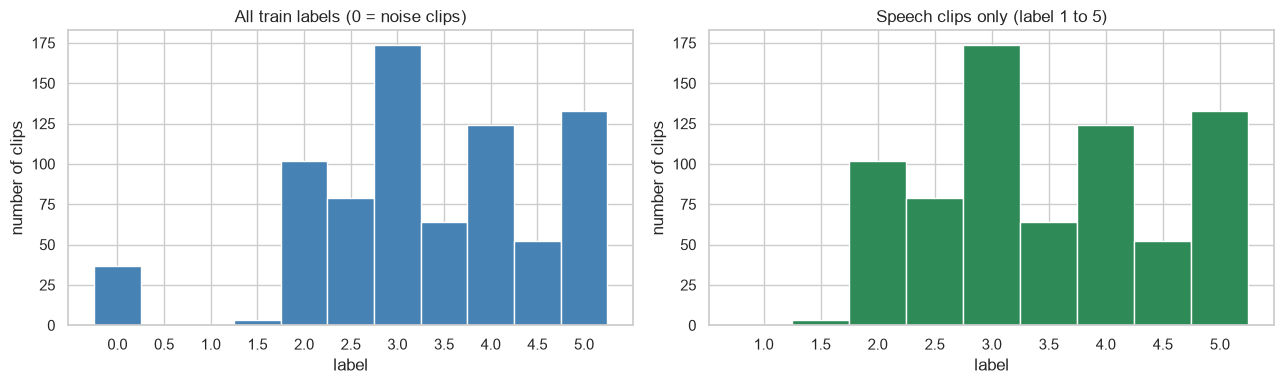

In [10]:
label_bins = np.arange(-0.25, 5.5, 0.5)    # bin edges -0.25, 0.25, ..., 5.25 -> one bar per 0.5 label step
speech_labels = train_df.loc[~train_df["is_noise"], "label"]  # labels of real speech clips only

fig, axes = plt.subplots(1, 2, figsize=(13, 4))  # two plots side by side
axes[0].hist(train_df["label"], bins=label_bins, color="steelblue", edgecolor="white")  # all labels
axes[0].set(title="All train labels (0 = noise clips)", xlabel="label", ylabel="number of clips")
axes[0].set_xticks(np.arange(0, 5.5, 0.5))       # one tick per possible label value

axes[1].hist(speech_labels, bins=label_bins[2:], color="seagreen", edgecolor="white")  # bins from 0.75 upward
axes[1].set(title="Speech clips only (label 1 to 5)", xlabel="label", ylabel="number of clips")
axes[1].set_xticks(np.arange(1, 5.5, 0.5))
plt.tight_layout()                               # stop titles and labels from overlapping
plt.show()

#### What to look for
- Whole-number scores (2, 3, 4, 5) are much more common than half scores. Raters seem to prefer whole numbers.
- The left end (1.0, 1.5) is almost empty, so the model will rarely see very weak grammar.
  A model trained on this data will tend to predict scores in the middle and will rarely predict near 1.

### Step 3.3 - Summary statistics of the speech labels

#### Goal
Get the numbers that matter for regression: the mean, spread and range of the real scores.
The standard deviation is especially useful because it is the RMSE of a "model" that always predicts the mean.

#### How
1. Run `describe()` on the speech labels (noise excluded).
2. Count the rare labels 1.0 and 1.5 and print a short imbalance note.
3. Print the RMSE of the constant "always predict the mean" baseline.

#### Terms
- **RMSE (Root Mean Squared Error)**: the square root of the average squared prediction error, in label units. Lower is better.
- **Baseline**: the simplest possible predictor. A real model must do clearly better than it.

In [11]:
print(speech_labels.describe().round(3))                 # count, mean, std, min, quartiles, max
n_rare = speech_labels.isin([1.0, 1.5]).sum()             # clips with the two lowest scores
print(f"\nClips with label 1.0 or 1.5: {n_rare} of {len(speech_labels)} speech clips "
      f"({100 * n_rare / len(speech_labels):.1f}%) -> strong imbalance at the low end.")
baseline_rmse = np.sqrt(np.mean((speech_labels - speech_labels.mean()) ** 2))  # error of always predicting the mean
print(f"RMSE of always predicting the mean speech label ({speech_labels.mean():.2f}): {baseline_rmse:.3f}")

count    732.000
mean       3.481
std        1.014
min        1.000
25%        2.500
50%        3.500
75%        4.500
max        5.000
Name: label, dtype: float64

Clips with label 1.0 or 1.5: 4 of 732 speech clips (0.5%) -> strong imbalance at the low end.
RMSE of always predicting the mean speech label (3.48): 1.014


#### What to look for
- The mean-predictor RMSE is the number to beat. A useful model in later parts should have a clearly lower test RMSE
  and a clearly positive Pearson correlation (the baseline's correlation is 0).
- The 25% and 75% values show where the middle half of the scores lies.

## Step 4 - Fast metadata scan

### Step 4.1 - Read every file header

#### Goal
Check the technical format of every clip (length, sampling rate, channels, encoding) without decoding any audio.
Surprises here, such as a stereo file or a different sampling rate, would change how we must load the audio.

#### How
1. Stack the train and test tables into one table of all clips (key = split + filename).
2. For each clip, call `sf.info(path)`, which reads only the header, and store duration, sample rate,
   channels, frames and subtype.
3. If a file cannot be read, catch the error with `try/except` and remember it instead of crashing.

#### Terms
- **Channels**: 1 = mono (one microphone signal), 2 = stereo (left and right).
- **Frames**: the number of time steps in the file. Duration = frames / sampling rate.
- **Subtype**: how each sample is stored, e.g. `PCM_16` = 16-bit integers.

In [12]:
id_columns = ["split", "filename", "path"]                                    # the columns every clip has
all_clips = pd.concat([train_df[id_columns], test_df[id_columns]], ignore_index=True)  # one table, 985 rows

meta_rows = []    # one dict per readable file
unreadable = []   # (split, filename, error message) for files that fail
for clip in all_clips.itertuples(index=False):    # loop over clips; clip.split, clip.filename, clip.path
    try:
        info = sf.info(clip.path)                  # header only: no audio decoding, so this is fast
        meta_rows.append({
            "split": clip.split,
            "filename": clip.filename,
            "duration_s": info.duration,           # length in seconds
            "samplerate": info.samplerate,         # samples per second as stored in the file
            "channels": info.channels,             # 1 = mono, 2 = stereo
            "frames": info.frames,                 # number of time steps
            "subtype": info.subtype,               # sample encoding, e.g. PCM_16
        })
    except Exception as err:                       # any read error: record it and keep going
        unreadable.append((clip.split, clip.filename, str(err)))

meta_df = pd.DataFrame(meta_rows)                  # turn the list of dicts into a table
print(f"Headers read: {len(meta_df)} | unreadable files: {len(unreadable)}")
for item in unreadable:                            # list every failed file, if any
    print("  UNREADABLE:", item)

Headers read: 985 | unreadable files: 0


#### What to look for
All 985 headers should be read and the unreadable list should be empty.
A file that fails here would also fail in the audio steps, so it would need to be fixed or excluded.

### Step 4.2 - Format summary

#### Goal
Check whether all clips share one format. If they do, loading is simple. If not, we must resample or mix channels.

#### How
1. Count the distinct values of sample rate, channels and subtype, per split.
2. Print the duration statistics per split.

#### Terms
- **Resampling**: converting audio from one sampling rate to another, e.g. 44.1 kHz to 16 kHz.
- **Mono mixdown**: averaging the channels of a stereo file into one channel.

In [13]:
for column in ["samplerate", "channels", "subtype"]:                     # the three format properties
    counts = meta_df.groupby("split")[column].value_counts()             # how many clips per (split, value)
    print(f"--- {column} ---")
    print(counts.to_string())                                            # to_string prints the whole series cleanly
print("\n--- duration_s per split ---")
print(meta_df.groupby("split")["duration_s"].describe().round(2))       # min, mean, max duration for train and test

--- samplerate ---
split  samplerate
test   16000         216
train  16000         769
--- channels ---
split  channels
test   1           216
train  1           769
--- subtype ---
split  subtype
test   PCM_16     216
train  PCM_16     769

--- duration_s per split ---
       count   mean   std    min    25%    50%    75%    max
split                                                       
test   216.0  48.76  8.18   6.48  45.06  45.06  60.01  61.03
train  769.0  55.78  7.91  20.06  54.19  60.07  60.07  61.04


#### What to look for
- A single sample rate and a single channel count mean `librosa.load(..., sr=16000, mono=True)` will not need to change
  anything. If a file has a different rate or is stereo, librosa will resample it or mix it to mono for us.
- Compare the duration statistics of train and test. Similar numbers mean the test clips look like the training clips.

### Step 4.3 - Duration histogram and out-of-range clips

#### Goal
See the spread of clip lengths and flag clips outside the expected 45 to 60 seconds.
Very short clips contain less speech to judge, and very long ones may need cutting for some models.

#### How
1. Plot overlaid duration histograms for train and test, with dashed lines at 45 and 60 seconds.
2. Many clips are a few hundredths of a second over 60 s (for example 60.07 s). That is harmless, so we allow
   a tolerance of 1.5 s above 60 before calling a clip "too long".
3. Count clips that are too short (under 45 s) or too long (over 61.5 s) per split.
4. For the train set, compare the mean label of short speech clips with the rest, to see whether length relates to the score.
5. List the shortest clips with their labels.

#### Terms
- **Out-of-range clip**: a clip whose duration is outside the range promised in the assignment.
- **Tolerance**: a small allowed margin, so tiny differences are not reported as problems.

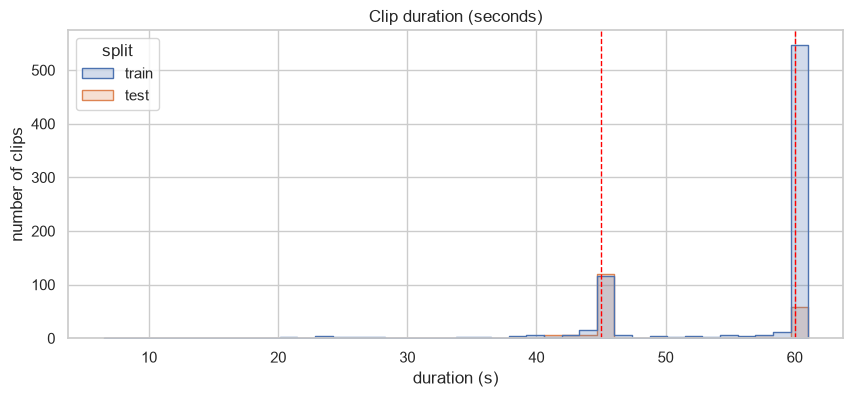

       too_short  too_long
split                     
test          41         0
train         60         0

Mean label of short train speech clips: 3.38 (n = 58)
Mean label of other train speech clips: 3.49

Shortest 10 clips:
split       filename  duration_s  label
 test  audio_107.wav        6.48    NaN
 test   audio_28.wav       18.56    NaN
train  audio_251.wav       20.06    2.0
train  audio_250.wav       20.12    3.0
train  audio_249.wav       20.84    2.0
train  audio_285.wav       22.14    4.0
train  audio_193.wav       23.66    4.0
train  audio_472.wav       23.89    2.5
train audio_5044.wav       24.13    0.0
train  audio_743.wav       24.13    4.0


In [14]:
MIN_DURATION_S, MAX_DURATION_S = 45, 60   # expected range from the assignment
TOLERANCE_S = 1.5                         # allow clips up to 61.5 s before calling them too long

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(data=meta_df, x="duration_s", hue="split", bins=40, element="step", ax=ax)  # one outline per split
for limit in (MIN_DURATION_S, MAX_DURATION_S):             # dashed lines at the expected range
    ax.axvline(limit, color="red", linestyle="--", linewidth=1)
ax.set(title="Clip duration (seconds)", xlabel="duration (s)", ylabel="number of clips")
plt.show()

meta_df["too_short"] = meta_df["duration_s"] < MIN_DURATION_S                  # True if under 45 s
meta_df["too_long"] = meta_df["duration_s"] > MAX_DURATION_S + TOLERANCE_S     # True if over 61.5 s
print(meta_df.groupby("split")[["too_short", "too_long"]].sum())               # summing booleans counts the True values

short_train = meta_df[meta_df["too_short"]].merge(                               # short clips with their train label
    train_df[["split", "filename", "label", "is_noise"]], on=["split", "filename"], how="left")
normal_train = meta_df[~meta_df["too_short"]].merge(                             # all other clips with their train label
    train_df[["split", "filename", "label", "is_noise"]], on=["split", "filename"])  # inner merge keeps only train rows
short_speech = short_train[(short_train["split"] == "train") & (short_train["is_noise"] == False)]  # short speech clips
print(f"\nMean label of short train speech clips: {short_speech['label'].mean():.2f} (n = {len(short_speech)})")
print(f"Mean label of other train speech clips: {normal_train.loc[~normal_train['is_noise'], 'label'].mean():.2f}")
print("\nShortest 10 clips:")
print(short_train.sort_values("duration_s")[["split", "filename", "duration_s", "label"]].head(10).round(2).to_string(index=False))

#### What to look for
- Most of the mass should sit between the red lines, with spikes at the lengths most recordings share.
- Short clips matter because they contain less speech to judge. If short speech clips had a clearly lower mean label,
  the raters might be punishing "too little speech" and not only grammar, and duration would become a useful feature.
- `label` is `NaN` for test clips because they have no labels.

## Step 5 - Signal-level feature table

### Step 5.1 - The feature function

#### Goal
Describe each clip with a few simple numbers that capture loudness and "noisiness".
These numbers are cheap to compute and should make the white-noise clips easy to tell apart from speech.
That is the basis for the noise gate in Part 2.

#### How
The function receives the audio array `y` and its sampling rate and computes:
1. **rms** and **rms_dbfs**: overall loudness. White noise played loudly has a high, steady RMS.
2. **peak**: the largest absolute sample value.
3. **clip_fraction**: the share of samples above 0.99 in absolute value. Loud noise often hits the limit.
4. **zcr**: the mean zero crossing rate. Noise flips sign far more often than voiced speech.
5. Compute the magnitude spectrogram once with `librosa.stft` and reuse it for the next three features.
6. **spectral_centroid**: the "center of mass" of the spectrum. Noise has much energy at high frequencies, so it is higher.
7. **spectral_bandwidth**: how widely the energy spreads around the centroid. Noise covers all frequencies, so it is wide.
8. **spectral_flatness**: close to 1 for noise (flat spectrum), close to 0 for tonal sounds such as vowels.
9. **speech_ratio**: `librosa.effects.split(top_db=30)` finds the stretches that are within 30 dB of the loudest part.
   Their total length divided by the clip length is the "not silent" share. Speech has pauses, so it is below 1.
   Steady noise never drops 30 dB below its own maximum, so it is close to 1. Note the name: a high value means
   "no silence", not necessarily "speech".

Frame settings: `n_fft=512` (32 ms windows) and `hop_length=160` (a new window every 10 ms) are common choices for speech.

#### Terms
- **Sample**: one number in the audio array; with float audio it lies between -1 and +1.
- **RMS (Root Mean Square)**: the square root of the mean of the squared samples. It measures average loudness.
- **dBFS (decibels relative to full scale)**: loudness on a log scale where 0 dBFS is the maximum possible level.
  Real values are negative: -20 dBFS is quieter than -10 dBFS.
- **Clipping**: the signal hits the maximum value and gets flattened, which happens when a recording is too loud.
- **Zero crossing rate (ZCR)**: the share of neighbouring samples that change sign, computed per frame.
- **Frame / window**: a short slice of audio (here 512 samples) analysed on its own.
- **Hop length**: how far the window moves between frames (here 160 samples = 10 ms).
- **STFT (Short-Time Fourier Transform)**: splits the audio into frames and measures how much of each frequency is in each frame.
- **Spectrum / spectrogram**: energy per frequency for one frame / for all frames over time.
- **Spectral centroid**: the energy-weighted average frequency, in Hz.
- **Spectral bandwidth**: the energy-weighted spread of frequencies around the centroid, in Hz.
- **Spectral flatness**: geometric mean divided by arithmetic mean of the spectrum, between 0 (tonal) and 1 (white noise).
- **top_db**: the threshold, in dB below the loudest frame, under which a frame counts as silence.

In [15]:
N_FFT = 512           # samples per analysis window: 512 / 16000 = 32 ms
HOP_LENGTH = 160      # step between windows: 160 / 16000 = 10 ms
CLIP_THRESHOLD = 0.99 # a sample above this absolute value counts as clipped
SILENCE_TOP_DB = 30   # frames more than 30 dB below the loudest frame count as silence
FEATURE_COLUMNS = ["rms", "rms_dbfs", "peak", "clip_fraction", "zcr",
                   "spectral_centroid", "spectral_bandwidth", "spectral_flatness", "speech_ratio"]


def compute_signal_features(y, sr):
    """Return a dict of simple loudness and noisiness features for one mono clip y at sampling rate sr."""
    features = {"duration_loaded_s": len(y) / sr}       # length after loading = number of samples / samples per second

    rms = np.sqrt(np.mean(y ** 2))                       # root mean square of all samples = average loudness
    features["rms"] = rms
    features["rms_dbfs"] = 20 * np.log10(rms + 1e-10)    # convert to dBFS; the tiny 1e-10 avoids log10(0) on pure silence
    features["peak"] = np.max(np.abs(y))                 # largest absolute sample value (1.0 = full scale)
    features["clip_fraction"] = np.mean(np.abs(y) > CLIP_THRESHOLD)  # share of samples at or near full scale

    features["zcr"] = librosa.feature.zero_crossing_rate(  # one ZCR value per frame ...
        y, frame_length=N_FFT, hop_length=HOP_LENGTH).mean()  # ... averaged over the whole clip

    S = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH))  # magnitude spectrogram: (frequency bins, frames)
    features["spectral_centroid"] = librosa.feature.spectral_centroid(   # average frequency per frame, in Hz
        S=S, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH).mean()
    features["spectral_bandwidth"] = librosa.feature.spectral_bandwidth( # spread around the centroid per frame, in Hz
        S=S, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH).mean()
    features["spectral_flatness"] = librosa.feature.spectral_flatness(   # 0 = tonal, 1 = white noise, per frame
        S=S, n_fft=N_FFT, hop_length=HOP_LENGTH).mean()

    intervals = librosa.effects.split(                   # (start, end) sample indices of non-silent stretches
        y, top_db=SILENCE_TOP_DB, frame_length=N_FFT, hop_length=HOP_LENGTH)
    non_silent_samples = np.sum(intervals[:, 1] - intervals[:, 0])  # total length of those stretches, in samples
    features["speech_ratio"] = non_silent_samples / len(y)          # share of the clip that is not silence
    return features

#### What to look for
This cell only defines the function and the constants; it prints nothing. The next cell tests it on two clips.

### Step 5.2 - Try the function on one speech clip and one noise clip

#### Goal
Understand the features on two concrete examples before computing them for all 985 clips.

#### How
1. Take the first speech clip and the first noise clip from the train table.
2. Load each with `librosa.load(path, sr=16000, mono=True)`:
   - `sr=16000` resamples to 16 kHz if the file has another rate, so every clip has the same time resolution.
   - `mono=True` averages the channels into one if a file is stereo, so every clip is a 1-D array.
3. Run `compute_signal_features` on both and print the results side by side.

#### Terms
- **librosa.load**: reads an audio file and returns `(y, sr)`: a float32 array scaled to -1..+1, and its sampling rate.
- **Mono**: a single audio channel.

In [16]:
demo_rows = [train_df[~train_df["is_noise"]].iloc[0], train_df[train_df["is_noise"]].iloc[0]]  # one speech, one noise clip
demo_features = {}
for row in demo_rows:
    y, sr = librosa.load(row["path"], sr=TARGET_SR, mono=True)  # 16 kHz, one channel, float32 in [-1, 1]
    column_name = f"{row['filename']} (label {row['label']})"   # readable column header
    demo_features[column_name] = compute_signal_features(y, sr) # dict of features for this clip
pd.DataFrame(demo_features).round(4)                             # features as rows, the two clips as columns

,audio_192.wav (label 3.0),audio_5055.wav (label 0.0)
duration_loaded_s,60.5084,60.0800
rms,0.0499,0.0818
rms_dbfs,-26.0461,-21.7457
peak,0.4778,0.9500
clip_fraction,0.0000,0.0000
zcr,0.0847,0.4616
spectral_centroid,963.7513,3862.7317
spectral_bandwidth,900.0458,2352.7882
spectral_flatness,0.0031,0.5101
speech_ratio,0.5103,1.0000


#### What to look for
Compare the two columns. You should expect the noise clip to have a higher zcr, centroid, bandwidth and flatness,
and a speech_ratio near 1. If two clips already differ this clearly, the full table should separate the groups well.

### Step 5.3 - Compute (or load) the features for every clip

#### Goal
Build the feature table for all train and test clips once, save it, and reuse it on later runs.
Decoding about 13 hours of audio takes minutes. The cache makes later runs take seconds.

#### How
1. If `audio_features.csv` exists and `RECOMPUTE_AUDIO_FEATURES` is `False`, load it.
2. Otherwise loop over all clips with a `tqdm` progress bar: load each clip at 16 kHz mono, compute the features,
   and store them with the clip's key (split, filename). A `try/except` per file records failures without stopping the loop.
3. Save the table to the output folder and print the time taken.
4. Check that the table contains exactly the clips we expect. A stale cache from an older dataset would show up here.

#### Terms
- **tqdm**: a library that shows a progress bar and an estimated time left for a loop.

In [17]:
if os.path.exists(FEATURES_CSV) and not RECOMPUTE_AUDIO_FEATURES:          # a cache exists and we are not forced to recompute
    features_df = pd.read_csv(FEATURES_CSV)                 # load the saved table: takes seconds
    print(f"Loaded cached features from {FEATURES_CSV} ({len(features_df)} rows). Set RECOMPUTE_AUDIO_FEATURES = True to rebuild.")
else:
    feature_rows, failed = [], []                            # results and failures
    start = time.perf_counter()                              # start the timer
    for clip in tqdm(all_clips.itertuples(index=False), total=len(all_clips),
                     desc="Extracting features", mininterval=5):  # update the bar at most every 5 seconds
        try:
            y, sr = librosa.load(clip.path, sr=TARGET_SR, mono=True)  # decode, resample to 16 kHz, mix to mono
            feature_rows.append({"split": clip.split, "filename": clip.filename,  # keep the full key
                                 **compute_signal_features(y, sr)})               # ** unpacks the feature dict
        except Exception as err:                             # a broken file must not stop the whole loop
            failed.append((clip.split, clip.filename, str(err)))
    elapsed = time.perf_counter() - start                    # seconds spent in the loop
    features_df = pd.DataFrame(feature_rows)                 # list of dicts -> table
    features_df.to_csv(FEATURES_CSV, index=False)            # save the cache (index=False: no extra index column)
    print(f"Computed features for {len(features_df)} clips in {elapsed:.0f} s "
          f"({elapsed / max(len(all_clips), 1):.2f} s per clip). Failed: {len(failed)}")
    for item in failed:                                      # list failures, if any
        print("  FAILED:", item)

expected_keys = set(zip(all_clips["split"], all_clips["filename"]))      # every (split, filename) we should have
cached_keys = set(zip(features_df["split"], features_df["filename"]))    # every (split, filename) in the table
print("Feature table covers exactly the expected clips:", expected_keys == cached_keys)

Loaded cached features from .\outputs\audio_features.csv (985 rows). Set RECOMPUTE_AUDIO_FEATURES = True to rebuild.
Feature table covers exactly the expected clips: True


#### What to look for
- On the first run: the time per clip and `Failed: 0`. On later runs: the "Loaded cached features" line.
- The final check must print `True`. If it prints `False`, the cache is from a different dataset:
  set `RECOMPUTE_AUDIO_FEATURES = True` in step 1.2 and run again.

### Step 5.4 - Feature summary per split

#### Goal
Get a first look at the typical values and ranges of each feature, for train and test.

#### How
1. Group the table by split and print the mean, min and max of each feature.
2. Check that the loaded duration matches the header duration from step 4 (a check that decoding worked).

#### Terms
- **Decoding**: turning the stored bytes of the file into sample values.

In [18]:
summary = features_df.groupby("split")[FEATURE_COLUMNS].agg(["mean", "min", "max"]).T  # rows = (feature, statistic)
print(summary.round(4).to_string())

check = features_df.merge(meta_df[["split", "filename", "duration_s"]], on=["split", "filename"])  # header duration
max_gap = (check["duration_loaded_s"] - check["duration_s"]).abs().max()   # largest difference, in seconds
print(f"\nLargest difference between loaded and header duration: {max_gap:.4f} s")

split                         test      train
rms                mean     0.0474     0.0606
                   min      0.0020     0.0036
                   max      0.1928     0.1856
rms_dbfs           mean   -28.9349   -25.4925
                   min    -53.8299   -48.9303
                   max    -14.2983   -14.6285
peak               mean     0.6148     0.7533
                   min      0.0423     0.0383
                   max      1.0000     1.0000
clip_fraction      mean     0.0000     0.0000
                   min      0.0000     0.0000
                   max      0.0009     0.0013
zcr                mean     0.1391     0.1612
                   min      0.0528     0.0453
                   max      0.3108     0.4804
spectral_centroid  mean  1687.6752  1810.2941
                   min    804.4041   850.8134
                   max   3042.5899  3918.3013
spectral_bandwidth mean  1513.4820  1525.9604
                   min    675.9447   774.8153
                   max   2155.7026

#### What to look for
- A duration difference close to 0 confirms that every clip was decoded completely.
- `clip_fraction` will be 0 for most clips. Any clearly non-zero value means a clip that was recorded too loud.
- If the train and test rows look similar, the two splits come from the same kind of recordings.

## Step 6 - Noise versus speech on the train set

### Step 6.1 - Attach the labels to the features

#### Goal
Combine each train clip's features with its label and `is_noise` flag, so we can compare the two groups.

#### How
1. Merge the train rows of the feature table with `train_df` on **both** `split` and `filename`.
   `validate="one_to_one"` makes pandas raise an error if a key appears twice.
2. Add a readable `group` column used as the x-axis in the plots.

#### Terms
- **Merge (join)**: combine two tables row by row using matching key columns.

In [19]:
train_feat = features_df[features_df["split"] == "train"].merge(           # only train clips have labels
    train_df[["split", "filename", "label", "is_noise"]],
    on=["split", "filename"],                                              # always join on the full key
    validate="one_to_one")                                                 # error if any key is duplicated
train_feat["group"] = np.where(train_feat["is_noise"], "noise (label 0)", "speech (label 1-5)")  # readable group name
GROUP_ORDER = ["speech (label 1-5)", "noise (label 0)"]                    # fixed order for every plot
print(train_feat["group"].value_counts())

group
speech (label 1-5)    732
noise (label 0)        37
Name: count, dtype: int64


#### What to look for
You should see 732 speech clips and 37 noise clips. If not, the merge lost rows or the labels changed.

### Step 6.2 - Boxplots per feature

#### Goal
See, feature by feature, whether noise and speech clips take different values.

#### How
1. Make a 3 by 3 grid, one panel per feature.
2. In each panel draw a boxplot for each group, and draw the individual clips as small dots on top,
   because the noise group has only 37 clips.

#### Terms
- **Boxplot**: the box spans the middle 50% of values (25th to 75th percentile), the line inside is the median,
  and the whiskers show the rest of the range except outliers.
- **Median**: the middle value when the values are sorted. Unlike the mean, it is not pulled by extreme values.

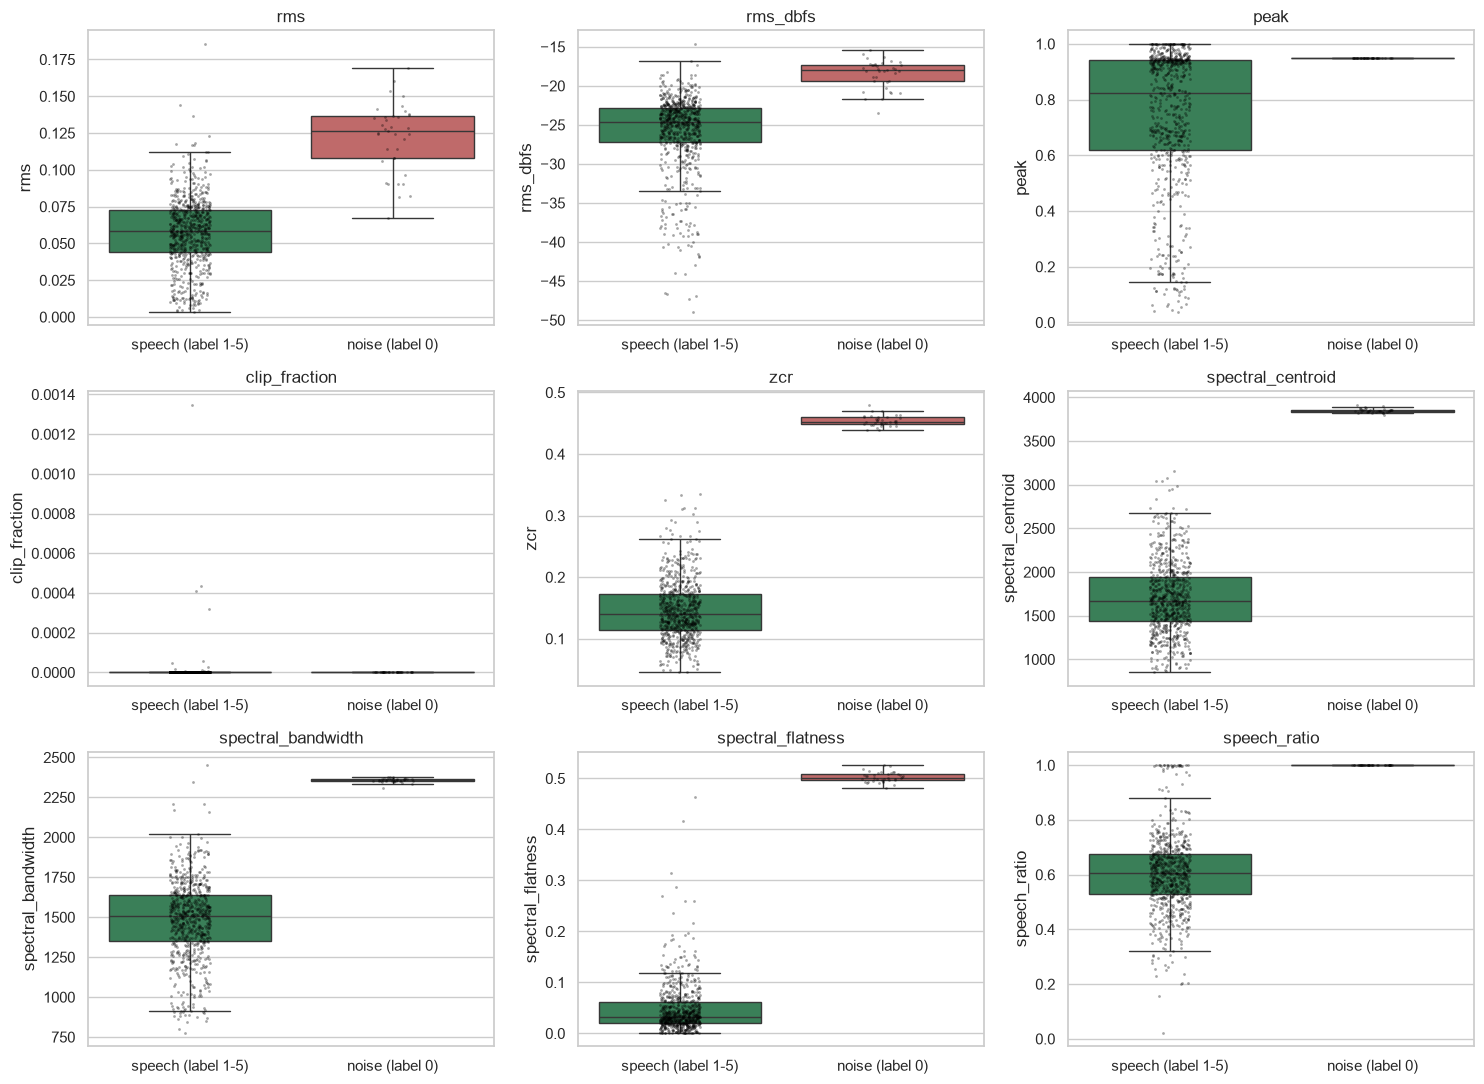

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))     # 9 panels for 9 features
for ax, feature in zip(axes.flat, FEATURE_COLUMNS):  # axes.flat walks the grid panel by panel
    sns.boxplot(data=train_feat, x="group", y=feature, hue="group", order=GROUP_ORDER,
                palette=["seagreen", "indianred"], showfliers=False, legend=False, ax=ax)  # outliers are drawn as dots below
    sns.stripplot(data=train_feat, x="group", y=feature, order=GROUP_ORDER,
                  color="black", size=2, alpha=0.35, ax=ax)               # one dot per clip
    ax.set(title=feature, xlabel="")
plt.tight_layout()
plt.show()

#### What to look for
- A strong feature shows two boxes that do not overlap at all, with the dots of each group in separate bands.
- A weak feature shows boxes at about the same height.
- Look at the noise dots: if a few lie inside the speech band, those noise clips may be quieter or different, and
  could slip past a simple threshold.

### Step 6.3 - Group means and medians

#### Goal
Put numbers on what the boxplots show.

#### How
1. Group the train features by `is_noise` and compute the mean and median of each feature.
2. Transpose the table so each feature is one row, which is easier to read.

#### Terms
- **Transpose**: swap rows and columns of a table.

In [21]:
group_stats = train_feat.groupby("group")[FEATURE_COLUMNS].agg(["mean", "median"])  # columns = (feature, statistic)
group_stats = group_stats.T.unstack()       # rows = feature, columns = (group, statistic)
group_stats = group_stats[GROUP_ORDER]      # put speech first, noise second
group_stats.round(4)

group              speech (label 1-5)            noise (label 0)           
                                 mean     median            mean     median
rms                            0.0575     0.0587          0.1220     0.1264
rms_dbfs                     -25.8485   -24.6274        -18.4497   -17.9632
peak                           0.7433     0.8242          0.9500     0.9500
clip_fraction                  0.0000     0.0000          0.0000     0.0000
zcr                            0.1464     0.1397          0.4541     0.4526
spectral_centroid           1707.1868  1665.0809       3850.1483  3846.6871
spectral_bandwidth          1483.9357  1508.4205       2357.3680  2355.8290
spectral_flatness              0.0475     0.0331          0.5028     0.5010
speech_ratio                   0.6058     0.6042          1.0000     1.0000

#### What to look for
A large gap between the speech and noise columns, much larger than the mean-median gap inside one group,
means the feature is clearly different between the groups. For `rms_dbfs` a gap of 6 dB means about double the amplitude.

### Step 6.4 - Rank the features by ROC AUC

#### Goal
Measure, with one number per feature, how well that feature alone separates noise from speech,
and pick the best single feature. This tells Part 2 which feature to build the noise gate on.

#### How
1. For each feature compute `roc_auc_score(is_noise, feature_values)`.
2. AUC below 0.5 only means the feature is *lower* for noise, so the separation strength is `max(AUC, 1 - AUC)`.
3. Also record whether the value ranges of the two groups overlap. No overlap means a simple threshold separates
   them perfectly on the training data.
4. Several features can reach AUC 1.0, so we also measure the **gap**: the empty space between the closest speech clip
   and the closest noise clip, divided by the standard deviation of the speech values so features in different units
   can be compared. A bigger gap means a safer threshold. A negative gap means the ranges overlap.
5. Sort by separation strength, then by gap, and keep the top feature as `best_feature`.

#### Terms
- **ROC AUC (Area Under the ROC Curve)**: the probability that a randomly chosen noise clip has a higher feature value
  than a randomly chosen speech clip. 1.0 = perfect separation, 0.5 = no better than a coin flip, 0.0 = perfect but reversed.
- **Threshold**: a cut-off value; clips on one side are called noise and on the other side speech.
- **Standard deviation (std)**: the typical distance of values from their mean; used here as a common unit.
- **Margin (gap)**: how far apart the two groups are at their closest points. A threshold placed in a wide gap
  is less likely to misclassify new clips.

In [22]:
is_noise = train_feat["is_noise"]                  # True/False target for the AUC
speech_values = train_feat[~is_noise]              # rows of speech clips
noise_values = train_feat[is_noise]                # rows of noise clips

auc_rows = []
for feature in FEATURE_COLUMNS:
    auc = roc_auc_score(is_noise, train_feat[feature])  # how often a noise clip ranks above a speech clip
    overlap = (noise_values[feature].min() <= speech_values[feature].max()      # do the two [min, max] ranges overlap?
               and speech_values[feature].min() <= noise_values[feature].max())
    if auc >= 0.5:                                                              # noise is on the high side
        gap = noise_values[feature].min() - speech_values[feature].max()        # lowest noise minus highest speech
    else:                                                                       # noise is on the low side
        gap = speech_values[feature].min() - noise_values[feature].max()        # lowest speech minus highest noise
    speech_std = speech_values[feature].std()                                   # spread of the speech values
    auc_rows.append({
        "feature": feature,
        "auc": auc,
        "separation": max(auc, 1 - auc),                                        # strength regardless of direction
        "direction": "higher for noise" if auc >= 0.5 else "lower for noise",
        "ranges_overlap": overlap,
        "gap_in_speech_std": gap / speech_std if speech_std > 0 else np.nan,    # negative = the ranges overlap
    })

auc_df = (pd.DataFrame(auc_rows)
          .sort_values(["separation", "gap_in_speech_std"], ascending=False)   # best AUC first, then the widest gap
          .reset_index(drop=True))
best_feature = auc_df.loc[0, "feature"]                                         # top-ranked single feature
n_perfect = (auc_df["separation"] == 1.0).sum()                                 # how many features separate perfectly
print(f"Best single feature: {best_feature} | features with perfect separation: {n_perfect}")
auc_df.round(4)

Best single feature: zcr | features with perfect separation: 3


,feature,auc,separation,direction,ranges_overlap,gap_in_speech_std
0,zcr,1.0000,1.0000,higher for noise,False,2.1544
1,spectral_centroid,1.0000,1.0000,higher for noise,False,1.5479
2,spectral_flatness,1.0000,1.0000,higher for noise,False,0.3896
3,spectral_bandwidth,0.9985,0.9985,higher for noise,True,-0.5656
4,speech_ratio,0.9932,0.9932,higher for noise,True,0.0000
5,rms_dbfs,0.9724,0.9724,higher for noise,True,-1.7976
6,rms,0.9724,0.9724,higher for noise,True,-5.0688
7,peak,0.8265,0.8265,higher for noise,True,-0.2007
8,clip_fraction,0.4672,0.5328,lower for noise,True,0.0000


#### What to look for
- Separation 1.0 with `ranges_overlap = False` means a single threshold splits noise from speech perfectly
  on the training data, so the noise gate in Part 2 can be a simple rule.
- Among the perfect features, look at `gap_in_speech_std`. A gap of 1 means the closest noise clip is a full
  speech standard deviation away from the closest speech clip. A tiny gap means one unusual speech clip
  could be misclassified as noise.
- Perfect separation on 37 noise clips does not guarantee the same on new data. A test noise clip could be quieter
  or of another noise type.

## Step 7 - Visual inspection

### Step 7.1 - Pick example clips

#### Goal
Choose a small, reproducible set of clips to look at and listen to: one per score level 2, 3, 4 and 5, plus one noise clip.

#### How
1. For each score, take a random clip with that label using `sample(n=1, random_state=SEED)`.
   The fixed `random_state` makes the choice identical on every run.
2. Do the same for the noise clips.
3. Stack them into one small table.

#### Terms
- **random_state**: the seed for one pandas random choice. Same seed, same rows.

In [23]:
example_parts = []
for score in [2.0, 3.0, 4.0, 5.0]:                                                    # one clip per score level
    example_parts.append(train_df[train_df["label"] == score].sample(n=1, random_state=SEED))
example_parts.append(train_df[train_df["is_noise"]].sample(n=1, random_state=SEED))  # one noise clip
examples_df = pd.concat(example_parts, ignore_index=True)                             # 5 rows
examples_df["title"] = [f"{row.split}/{row.filename} - label {row.label}"             # plot title per clip
                        for row in examples_df.itertuples()]
examples_df[["split", "filename", "label", "is_noise"]]

,split,filename,label,is_noise
0,train,audio_420.wav,2.0,False
1,train,audio_534.wav,3.0,False
2,train,audio_267.wav,4.0,False
3,train,audio_661.wav,5.0,False
4,train,audio_5067.wav,0.0,True


#### What to look for
Five rows: labels 2, 3, 4, 5 and one 0 with `is_noise = True`. These same clips are used in steps 7, 8 and 9.

### Step 7.2 - Waveforms and log mel spectrograms

#### Goal
See what speech and noise look like. This builds intuition for the numbers in step 6.

#### How
1. Load each example clip at 16 kHz mono and keep the arrays in a dictionary for steps 8 and 9.
2. Left column: the waveform, with the same y-axis (-1 to 1) for every clip so loudness can be compared.
3. Right column: a mel spectrogram (`librosa.feature.melspectrogram`, 64 mel bands up to 8 kHz),
   converted to decibels with `librosa.power_to_db(ref=np.max)` and drawn with `librosa.display.specshow`.

#### Terms
- **Waveform**: the sample values plotted over time.
- **Mel scale**: a frequency scale that matches human hearing: fine steps at low frequencies, coarse steps at high ones.
- **Mel spectrogram**: a spectrogram whose frequency bins are grouped into mel bands. It is the standard input to speech models.
- **power_to_db**: converts energy to decibels (a log scale), so quiet and loud parts are both visible.
  `ref=np.max` makes the loudest point of each clip 0 dB, so colours show *relative* loudness within a clip.
- **Harmonics**: in voiced speech the vocal cords vibrate at a base frequency and its multiples. They appear as
  stacked horizontal stripes.

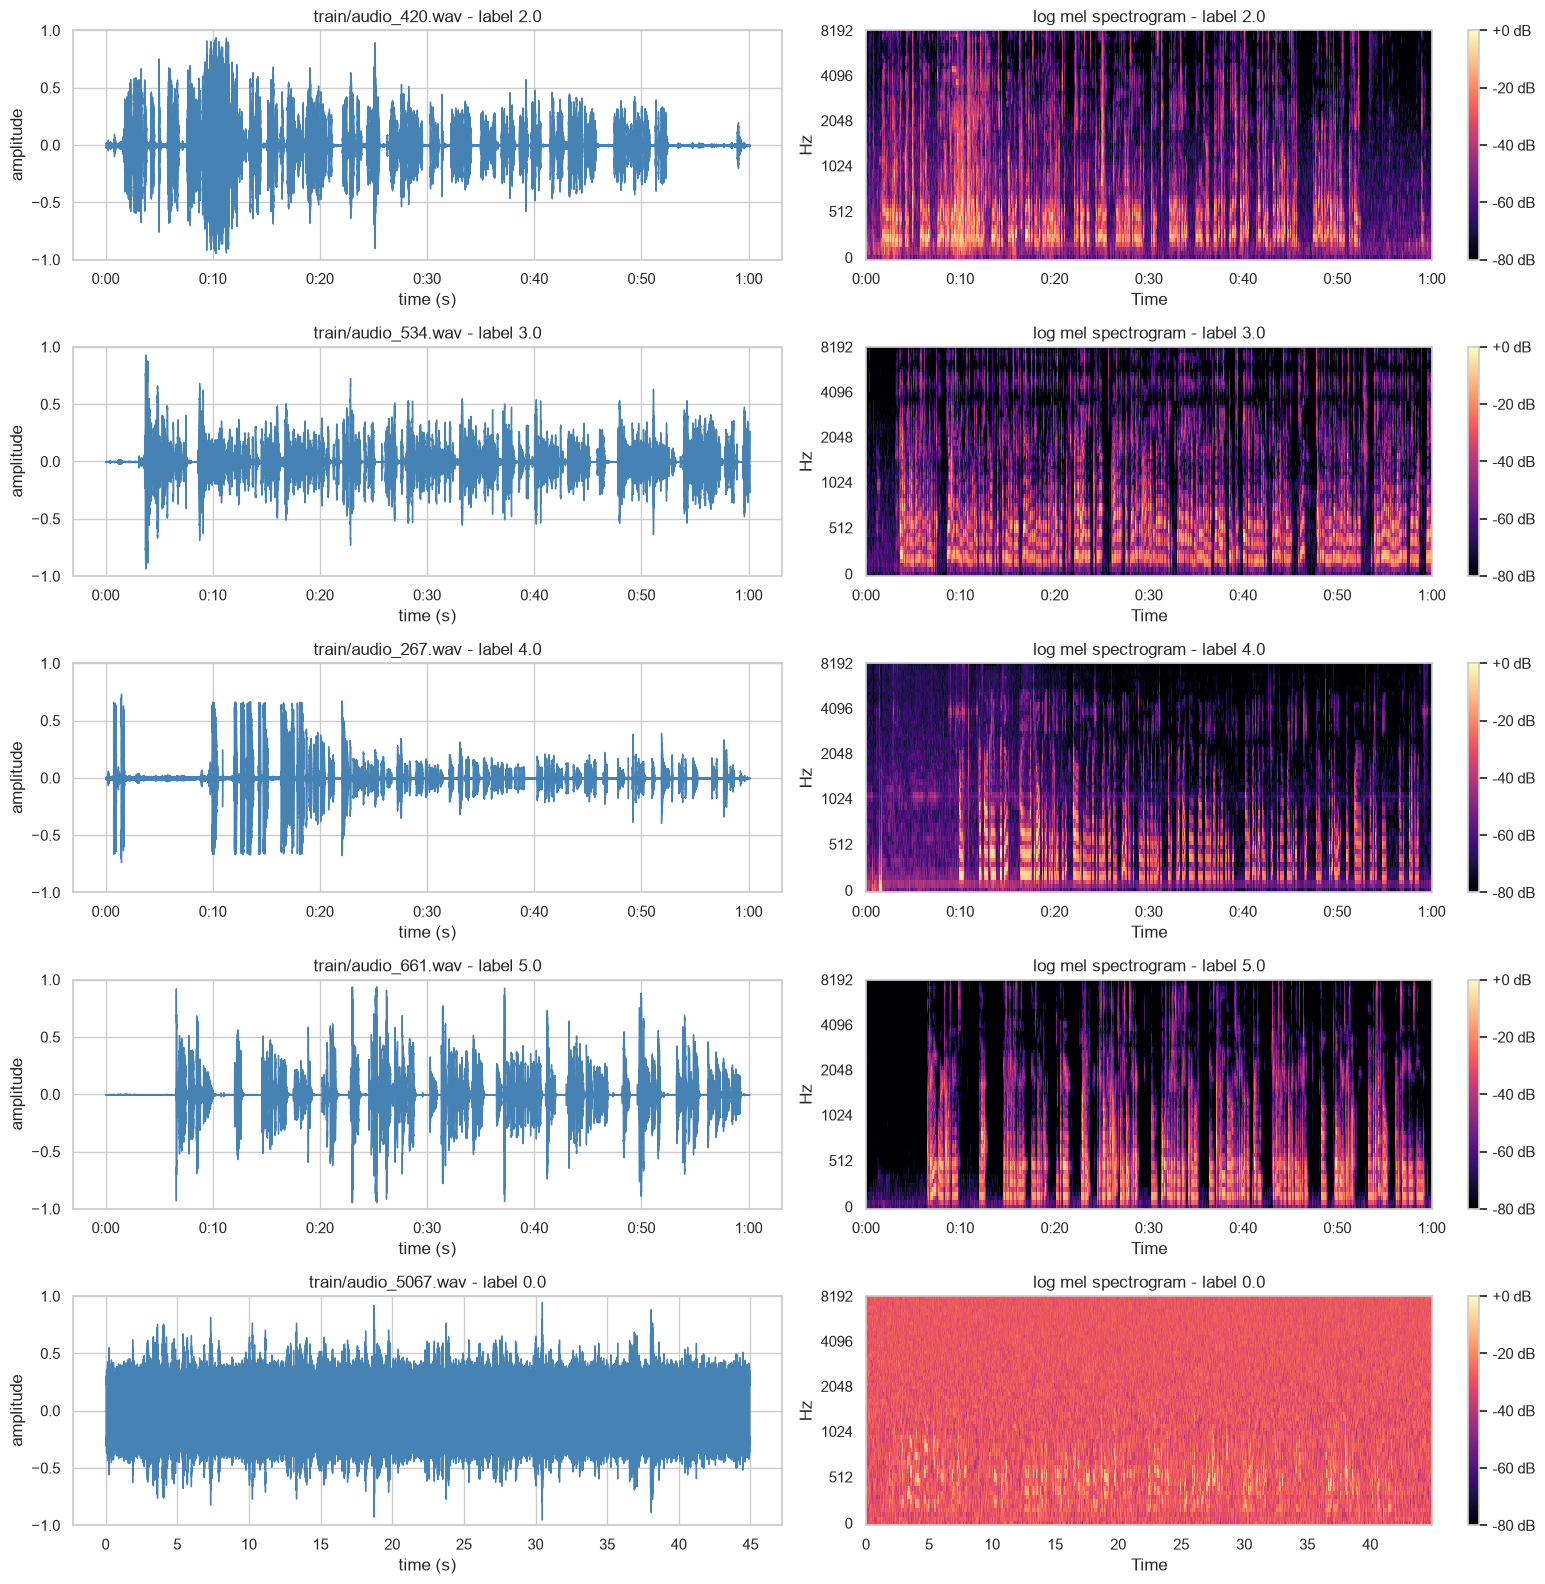

In [24]:
N_MELS = 64                       # number of mel bands (rows in the spectrogram image)
example_audio = {}                # (split, filename) -> audio array, reused in steps 8 and 9

fig, axes = plt.subplots(len(examples_df), 2, figsize=(16, 3.2 * len(examples_df)))  # one row per clip
for i, row in enumerate(examples_df.itertuples(index=False)):
    y, sr = librosa.load(row.path, sr=TARGET_SR, mono=True)    # same loading settings as everywhere else
    example_audio[(row.split, row.filename)] = y               # keep the array for later cells

    librosa.display.waveshow(y, sr=sr, ax=axes[i, 0], color="steelblue")  # waveform over time
    axes[i, 0].set(title=row.title, ylim=(-1, 1), xlabel="time (s)", ylabel="amplitude")  # same y-range for every clip

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH,
                                         n_mels=N_MELS, fmax=sr / 2)  # energy per mel band per frame; fmax = 8 kHz
    mel_db = librosa.power_to_db(mel, ref=np.max)                     # decibels, loudest point = 0 dB
    image = librosa.display.specshow(mel_db, sr=sr, hop_length=HOP_LENGTH, x_axis="time", y_axis="mel",
                                     fmax=sr / 2, ax=axes[i, 1], cmap="magma", vmin=-80, vmax=0)  # fixed colour range
    axes[i, 1].set(title=f"log mel spectrogram - label {row.label}")
    fig.colorbar(image, ax=axes[i, 1], format="%+.0f dB")             # colour scale legend
plt.tight_layout()
plt.show()

#### What to look for
- **Speech** waveforms come in bursts (words) with quiet gaps (pauses). Their spectrograms show bright, wavy horizontal
  stripes at low frequencies (harmonics), which change shape as the speaker changes sounds, and dark vertical gaps at pauses.
- **Noise** looks like a solid block in the waveform, often touching -1 and +1, and like a uniform "wash" of colour
  across all frequencies and all time in the spectrogram, with no stripes and no gaps.
- Note what you *cannot* see: grammar. Clips with labels 2 and 5 look alike. Grammar has to come from the words
  (Part 2 transcription), not from these acoustic pictures.

## Step 8 - Listen

#### Goal
Hear the same five clips. Listening is the quickest way to judge whether a label makes sense.

#### How
1. Import `IPython.display.Audio` inside a `try` block, so the notebook continues where audio players are not supported.
2. For each example, print its label and embed a player with the first `LISTEN_SECONDS` seconds.
   Only part of each clip is embedded, to keep the notebook file small.
3. `normalize=False` keeps the real loudness, so the noise clip sounds as loud as it really is. **Lower your volume first.**

#### Terms
- **Embedding**: the audio is stored inside the notebook file, so the player works without the original wav.
- **Normalize (player option)**: when True, the player scales every clip to full volume, which would hide loudness differences.

In [25]:
LISTEN_SECONDS = 15                                       # seconds of audio embedded per clip
try:
    from IPython.display import Audio, display            # notebook audio player and the function that shows it
    for row in examples_df.itertuples(index=False):
        try:
            y = example_audio[(row.split, row.filename)][: LISTEN_SECONDS * TARGET_SR]  # first 15 s of samples
            print(f"{row.split}/{row.filename}  label = {row.label}  (is_noise = {row.is_noise})")
            display(Audio(data=np.clip(y, -1, 1), rate=TARGET_SR, normalize=False))   # clip to [-1, 1] as the player requires
        except Exception as err:                          # one bad clip should not stop the others
            print(f"  could not create a player for {row.filename}: {err}")
except Exception as err:                                  # no audio support at all in this environment
    print("Audio playback is not available here:", err)

train/audio_420.wav  label = 2.0  (is_noise = False)


train/audio_534.wav  label = 3.0  (is_noise = False)


train/audio_267.wav  label = 4.0  (is_noise = False)


train/audio_661.wav  label = 5.0  (is_noise = False)


train/audio_5067.wav  label = 0.0  (is_noise = True)


#### What to look for
- The noise clip should be pure hiss with no voice. If you can hear any speech under it, the "label 0 = no speech"
  assumption needs a second look.
- Compare a label-2 clip with a label-5 clip. You should hear simpler or broken sentences in the low-score clip.
  Pay attention to whether accent, fluency or audio quality might also have influenced the raters.

## Step 9 - The reusable preprocessing function

### Step 9.1 - Define `load_and_preprocess`

#### Goal
Write the single function that every later part will use to turn a wav file into a clean, standard array.
Doing it in one place guarantees that training and test audio are processed identically.

#### How
1. Load the file as mono at `target_sr` (resampling and mixing channels if needed).
2. If `trim=True`, cut silence from the start and the end with `librosa.effects.trim` (same 30 dB rule as step 5).
3. If `normalize=True`, divide by the largest absolute sample, so the peak becomes exactly 1.0 (peak normalization).
   A silent clip (peak 0) is left unchanged to avoid dividing by zero.
4. Return the array and its sampling rate.

#### Why there is no denoising
- Denoising algorithms guess what is noise and remove it. On speech this often creates artefacts ("musical noise",
  muffled consonants), and those can make a speech recognizer mishear words, which directly damages grammar scoring.
- Modern recognizers such as Whisper are trained on noisy audio and handle moderate noise well on their own.
- Our noise gate needs the noise. A denoiser could turn a white-noise clip into near silence or into strange artefacts,
  which would hide exactly what we want to detect.

#### Terms
- **Trimming**: removing silent stretches at the beginning and end of a clip (not in the middle).
- **Peak normalization**: scaling the audio so its loudest sample reaches a fixed level. It changes volume, not the content.
- **Denoising**: an algorithm that tries to remove background noise from a recording.
- **Docstring**: the text in triple quotes right under a function definition, which documents what the function does.

In [26]:
def load_and_preprocess(path, target_sr=16000, trim=False, normalize=True):
    """Load one audio file and return a standardised mono waveform.

    Steps:
        1. Load as mono at target_sr (librosa resamples and mixes channels if needed).
        2. If trim is True, remove leading and trailing silence (frames more than 30 dB below the loudest frame).
        3. If normalize is True, peak normalize so the largest absolute sample is 1.0.
    No denoising is applied on purpose: it can distort speech and would hide the noise clips we need to detect.

    Args:
        path: full path to the audio file. Build it from DATA_DIR and the split folder, never from the filename alone.
        target_sr: sampling rate in Hz to load at. 16000 is the standard for speech models such as Whisper.
        trim: if True, cut silence at the start and end of the clip.
        normalize: if True, scale the clip so its peak absolute value is 1.0.

    Returns:
        y: 1-D numpy float32 array of samples in [-1, 1].
        sr: sampling rate of y in Hz (always equal to target_sr).
    """
    y, sr = librosa.load(path, sr=target_sr, mono=True)            # decode, resample to target_sr, mix to one channel
    if trim:
        y, _ = librosa.effects.trim(y, top_db=SILENCE_TOP_DB,       # drop edge frames quieter than loudest - 30 dB
                                    frame_length=N_FFT, hop_length=HOP_LENGTH)  # same frames as the features
    if normalize:
        peak = np.max(np.abs(y)) if len(y) > 0 else 0.0            # loudest sample; 0 for an empty array
        if peak > 0:                                               # skip silent clips to avoid dividing by zero
            y = y / peak                                           # loudest sample becomes exactly +1 or -1
    return y.astype(np.float32), sr                                # float32 keeps memory use low

#### What to look for
This cell only defines the function. The next cell shows its effect. Parts 2 and 3 will define this same function
again (copied as-is), so the preprocessing stays identical across notebooks.

### Step 9.2 - Before and after on two clips

#### Goal
Check that the function does what we expect: the same content, only louder or shorter.

#### How
1. Take the label-3 example and the noise example from step 7.
2. "Before" = plain `librosa.load` at 16 kHz mono. "After" = `load_and_preprocess(..., trim=True, normalize=True)`.
3. Print duration and peak before and after, and plot the waveforms in a 2 by 2 grid with the same y-range.

#### Terms
- **Peak value**: the largest absolute sample in a clip (1.0 = full scale).

train/audio_534.wav (label 3.0): duration 60.07 s -> 56.97 s, peak 0.933 -> 1.000


train/audio_5067.wav (label 0.0): duration 44.93 s -> 44.93 s, peak 0.950 -> 1.000


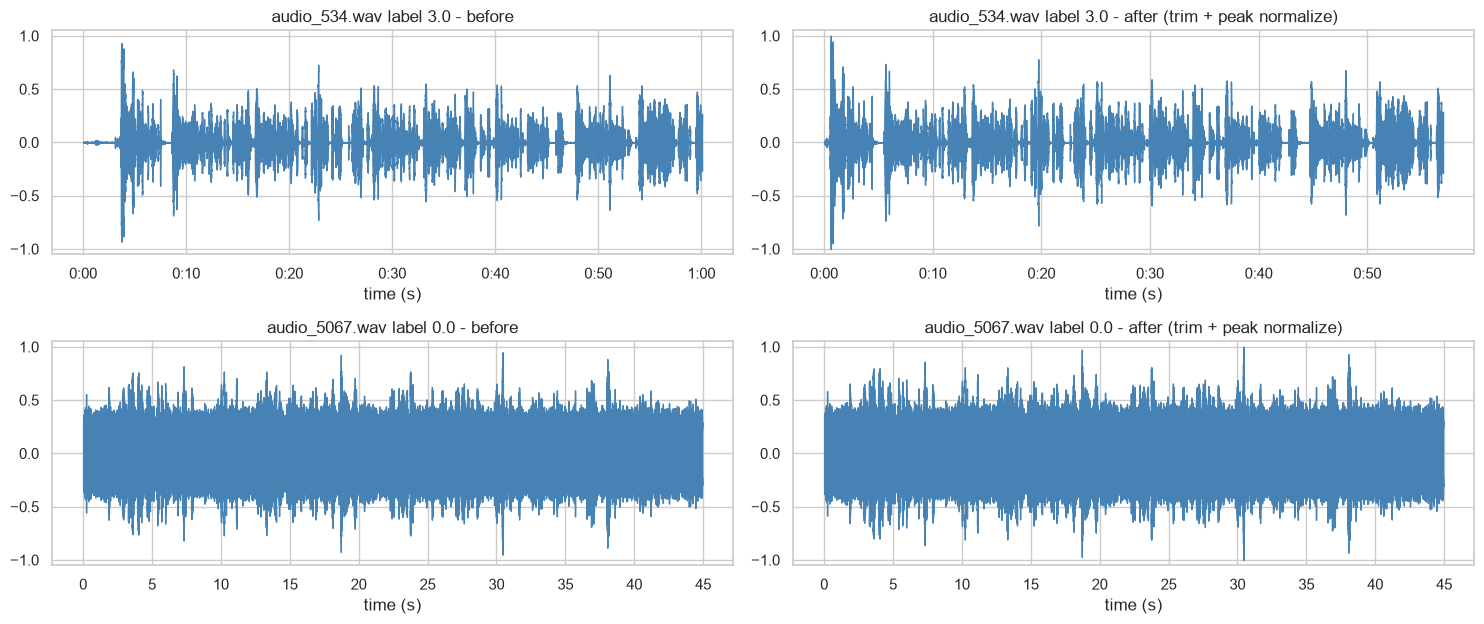

In [27]:
demo_clips = examples_df[examples_df["label"].isin([3.0, 0.0])]   # one speech clip (label 3) and the noise clip

fig, axes = plt.subplots(len(demo_clips), 2, figsize=(15, 3.2 * len(demo_clips)), squeeze=False)
for i, row in enumerate(demo_clips.itertuples(index=False)):
    before, sr = librosa.load(row.path, sr=TARGET_SR, mono=True)                        # raw, only resampled
    after, _ = load_and_preprocess(row.path, target_sr=TARGET_SR, trim=True, normalize=True)  # our preprocessing
    print(f"{row.split}/{row.filename} (label {row.label}): "
          f"duration {len(before) / sr:.2f} s -> {len(after) / sr:.2f} s, "                # seconds = samples / rate
          f"peak {np.max(np.abs(before)):.3f} -> {np.max(np.abs(after)):.3f}")
    for j, (signal, stage) in enumerate([(before, "before"), (after, "after (trim + peak normalize)")]):
        librosa.display.waveshow(signal, sr=sr, ax=axes[i, j], color="steelblue")       # waveform over time
        axes[i, j].set(title=f"{row.filename} label {row.label} - {stage}", ylim=(-1.05, 1.05), xlabel="time (s)")
plt.tight_layout()
plt.show()

#### What to look for
- The peak after normalization must be 1.000.
- The speech clip should become slightly shorter if it starts or ends with silence; the shape of the waveform must stay the same.
- The noise clip barely changes: it has no silent edges to trim, and its peak is often already near 1.
  That is fine, and it confirms that preprocessing keeps the noise visible for the noise gate.

## Step 10 - Test set sanity check

### Step 10.1 - Compare feature distributions of train and test

#### Goal
Check that the test clips look like the training clips. If the test audio were recorded differently, a model trained
on train would do worse on test. We also look for test clips that resemble the noise clips.

#### How
1. Split the features into three groups: train speech, train noise and test.
2. For `rms_dbfs`, `spectral_flatness` and `speech_ratio`, draw overlaid density histograms of the three groups.
   `stat="density"` with `common_norm=False` scales each group to the same area, so the 37 noise clips are as visible as the 732 speech clips.

#### Terms
- **Density histogram**: a histogram scaled so its total area is 1, which makes groups of different size comparable.
- **Distribution shift**: when the test data has different value ranges or shapes than the training data.

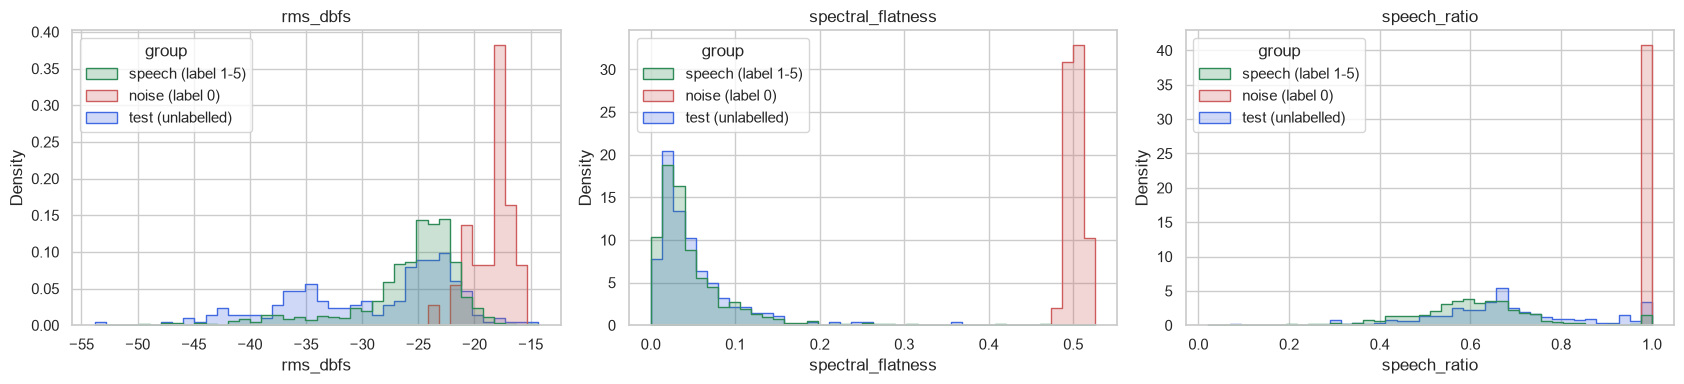

In [28]:
test_feat = features_df[features_df["split"] == "test"].copy()   # test rows of the feature table
test_feat["group"] = "test (unlabelled)"                         # third group for the plots
compare_df = pd.concat([train_feat[["group"] + FEATURE_COLUMNS], # train speech + train noise ...
                        test_feat[["group"] + FEATURE_COLUMNS]], # ... + test, stacked into one table
                       ignore_index=True)
compare_order = GROUP_ORDER + ["test (unlabelled)"]              # legend order
compare_colors = ["seagreen", "indianred", "royalblue"]          # speech, noise, test

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, feature in zip(axes, ["rms_dbfs", "spectral_flatness", "speech_ratio"]):
    sns.histplot(data=compare_df, x=feature, hue="group", hue_order=compare_order, palette=compare_colors,
                 stat="density", common_norm=False, element="step", bins=40, ax=ax)  # each group scaled separately
    ax.set(title=feature)
plt.tight_layout()
plt.show()

#### What to look for
- The blue test outline should follow the green train-speech outline. A large sideways shift would be a warning sign.
- A small blue bump on top of the red noise outline suggests the test set also contains noise clips.

### Step 10.2 - Rough count of noise-like test clips

#### Goal
Estimate how many test clips might be noise, using the best single feature from step 6.
This is only a **preview**. The real noise gate, with a properly chosen threshold, is built in Part 2.

#### How
1. Take the minimum and maximum of `best_feature` over the 37 training noise clips.
2. Count test clips whose value lies inside that range.
3. For comparison, count training **speech** clips inside the same range. A good feature gives a number close to 0 here.
4. Count test clips that lie beyond the speech range on the noise side. Such clips look unlike any training speech
   even if they do not match the training noise.
5. Show the 5 test clips that are most noise-like on this feature, so you know which ones to listen to.

#### Terms
- **False positive**: a speech clip wrongly flagged as noise.

In [29]:
noise_low = noise_values[best_feature].min()                      # smallest value among training noise clips
noise_high = noise_values[best_feature].max()                     # largest value among training noise clips
test_in_range = test_feat[test_feat[best_feature].between(noise_low, noise_high)]   # inclusive range test
speech_in_range = speech_values[speech_values[best_feature].between(noise_low, noise_high)]
noise_is_high = auc_df.loc[0, "direction"] == "higher for noise"  # which side of speech the noise lies on
if noise_is_high:
    beyond_speech = test_feat[test_feat[best_feature] > speech_values[best_feature].max()]  # above every train speech clip
else:
    beyond_speech = test_feat[test_feat[best_feature] < speech_values[best_feature].min()]  # below every train speech clip

print(f"Feature: {best_feature} | training noise range: [{noise_low:.4f}, {noise_high:.4f}] | "
      f"training speech range: [{speech_values[best_feature].min():.4f}, {speech_values[best_feature].max():.4f}]")
print(f"Test clips inside the noise range          : {len(test_in_range)} of {len(test_feat)}")
print(f"Train SPEECH clips inside the noise range  : {len(speech_in_range)} of {len(speech_values)} (would be false positives)")
print(f"Test clips beyond the speech range (noise side): {len(beyond_speech)}")
print("\nWARNING: this is a rough preview only, not the noise gate. Part 2 will choose and check a proper threshold.")
print(f"\nThe 5 most noise-like test clips by {best_feature}:")
(test_feat.sort_values(best_feature, ascending=not noise_is_high)       # most noise-like first
          [["split", "filename"] + FEATURE_COLUMNS].head(5).round(4))

Feature: zcr | training noise range: [0.4388, 0.4804] | training speech range: [0.0453, 0.3344]
Test clips inside the noise range          : 0 of 216
Train SPEECH clips inside the noise range  : 0 of 732 (would be false positives)
Test clips beyond the speech range (noise side): 0


The 5 most noise-like test clips by zcr:


,split,filename,rms,rms_dbfs,peak,clip_fraction,zcr,spectral_centroid,spectral_bandwidth,spectral_flatness,speech_ratio
805,test,audio_22.wav,0.0212,-33.4696,0.3478,0.0,0.3108,3042.5899,1889.4037,0.1117,0.7187
882,test,audio_38.wav,0.0323,-29.8244,0.6609,0.0,0.3013,2776.1230,1863.2125,0.2456,0.4186
782,test,audio_28.wav,0.0308,-30.2320,0.4689,0.0,0.2980,2829.2429,1940.7349,0.1375,0.6358
790,test,audio_69.wav,0.0253,-31.9514,0.9889,0.0,0.2625,2671.4053,2061.4099,0.1545,0.3667
930,test,audio_68.wav,0.0320,-29.8907,0.9425,0.0,0.2591,2652.6870,2074.3503,0.1448,0.3414


#### What to look for
- If the train-speech count is 0, the noise range is "clean", and the test count is a fair first guess of how many
  test clips are noise.
- A test count of 0 means the test set may contain no white-noise clips of this kind, or that test noise differs.
  Compare the top test values with the noise range: if even the most noise-like test clip is far from it, there
  is probably no such noise in test.
- Listen to the top clips before trusting the count. Remember that test filenames are different
  recordings from the train files with the same name.

## Part 1 summary

### Findings
These numbers come from the local run. If you rerun on Kaggle they should match. If they do not, check the library versions printed in step 1.3.

**Data and files**
- 769 train and 216 test clips. All files exist and are readable, with no duplicate filenames inside a split.
- 212 of the 216 test filenames also exist in train/ as *different* recordings (for example, audio_128.wav is 45.06 s in both
  folders, but the audio differs). Keying by (split, filename) is required.
- sample_submission.csv has 204 rows. Only 25 of its filenames are in test.csv and 105 are train names. Use it for the format only.
- Every clip is 16 kHz, mono, PCM_16. Loading at sr=16000, mono=True therefore changes nothing, but it keeps the code safe for other files.

**Durations**
- Train: 20.1 to 61.0 s (median 60.07 s). Test: 6.5 to 61.0 s (median 45.06 s). Test clips are shorter on average (48.8 s vs 55.8 s).
- Clips under 45 s: 60 in train (58 speech, 2 noise) and 41 in test. The shortest test clip is
  only 6.5 s (test/audio_107.wav). No clip is over 61.5 s.
- Short speech clips have about the same mean label as the others (3.38 vs 3.49), so length does not seem to drive the score much.

**Labels**
- 37 noise clips (label 0) and 732 speech clips. The speech scores have mean 3.48, std 1.01 and median 3.5.
- Whole scores dominate: 3.0 (174), 5.0 (133), 4.0 (124), 2.0 (102). Only 4 clips are 1.0 or 1.5 (0.5%).
- Always predicting the mean gives RMSE 1.014 on the speech clips. Later models must clearly beat this.

**Noise versus speech**
- Three features separate the noise clips perfectly on train (AUC 1.0, no overlap): **zcr** (widest gap, 2.15 speech std),
  spectral_centroid (gap 1.55 std) and spectral_flatness (gap only 0.39 std).
- zcr: speech 0.045 to 0.334, noise 0.439 to 0.480. Flatness: speech max 0.464 (train/audio_242.wav, label 2) vs noise min 0.482,
  which is a very narrow margin.
- Loudness alone (rms_dbfs, AUC 0.97) and speech_ratio (AUC 0.99) overlap with speech: 15 speech clips also have speech_ratio = 1.0.
- All 37 noise clips have a peak of exactly 0.950, which suggests they were generated or normalized artificially.

**Test preview**
- 0 of 216 test clips fall inside the training noise range on zcr, and 0 lie beyond the training speech range.
  The most noise-like test clip (test/audio_22.wav, zcr 0.311) is still inside the speech range.
  The test set probably contains no white-noise clips of the training kind, but this is a preview only.

**Things to double check by ear**
- The noise spectrogram in step 7 shows irregular brighter energy below about 1 kHz, and the waveform has bursts above the hiss level.
  The noise clips also have the same mixed lengths as real recordings. Speech may be buried under the noise.
  It is inaudible to you, but a model or Whisper might still pick it up.
- train/audio_242.wav and audio_243.wav (labels 2 and 3) have unusually high spectral flatness for speech. They may be noisy recordings.
- test/audio_107.wav (6.5 s) and test/audio_28.wav (18.6 s) contain very little speech to grade.

### Next steps (Part 2)
1. **Noise gate**: turn the best separating feature(s) from step 6 into a rule with a threshold chosen on train
   (for example the midpoint of the gap between the groups), check it with cross-validation, and decide what score to give
   gated test clips (the training data says 0).
2. **Transcription**: run Whisper on the speech clips, using `load_and_preprocess` (16 kHz mono, peak normalized, no denoising),
   and cache the transcripts by (split, filename).
3. **Grammar features**: from the transcripts, compute text features (error counts, sentence length, clause complexity)
   and possibly text embeddings.
4. **Model**: train a regressor on speech clips only (labels 1 to 5), report training RMSE and cross-validated RMSE and Pearson,
   and compare with the mean baseline from step 3.3.
5. **Low-score imbalance**: labels 1.0 and 1.5 are very rare; consider this when judging errors at the low end.

# PART 2: Transcription and noise gate

**What this part does**
- **A.** Transcribes all 985 clips with Whisper. For each clip it keeps the text, the word timestamps, each word's confidence
  and quality numbers per segment. Everything is saved to disk and the run can resume after an interruption.
- **B.** Checks how good the transcripts are, and how Whisper behaves on the noise clips compared with normal speech.
- **C.** Builds and honestly evaluates a first **noise gate**: a small model that predicts `is_noise` (label 0).
  It is applied to the test set only as a preview.

No grammar score model is trained here; that starts in Part 3.

**Reused from Part 1 (not redefined here):** `DATA_DIR`, `OUTPUT_DIR`, `IS_KAGGLE`, `SEED`, `TARGET_SR`,
`train_df` (with `is_noise`), `test_df`, `all_clips`, `meta_df`, `features_df`, `FEATURE_COLUMNS`, `GROUP_ORDER`,
`load_and_preprocess()`, and the imports `os`, `time`, `np`, `pd`, `plt`, `sns`, `tqdm`, `roc_auc_score`.

## Step 11 - Run switches, imports and device

### Step 11.1 - Run switches

#### Goal
Collect the settings that control the slow steps in one place, so you can run the whole notebook quickly
(using saved results) or fully (recomputing everything).

#### How
1. Define the Part 2 switches and the folder where all speech recognition results are stored (`outputs/asr/`).
2. On Kaggle, if you attached a dataset that contains an `asr` folder with saved results, copy it into the
   working folder, so the notebook finds the saved transcripts there.

| Switch | Where | Default | What it does | On Kaggle |
|---|---|---|---|---|
| `RECOMPUTE_AUDIO_FEATURES` | Step 1.2 (it must be set before Step 5 runs) | `False` | `True` recomputes the Part 1 audio feature table (about 4 minutes) even if `audio_features.csv` exists. | Leave `False`. |
| `RUN_WHISPER` | here | `True` | `True` transcribes every clip that has no saved transcript yet. Clips already saved in `outputs/asr/` are always loaded, never redone. `False` only loads saved results and never starts Whisper. | Set `False` if you attached the saved `asr` folder (fast, no GPU needed). Keep `True` to transcribe on a Kaggle GPU (about 1 to 2 hours). |
| `PILOT_MEDIUM` | here | `False` | `True` adds the `medium` model to the settings comparison in Step 14. It was left off locally: it is about twice as slow, and its 1.5 GB load ran this laptop out of RAM. | Can be `True` on a Kaggle GPU if you want the comparison. |
| `CHECKPOINT_EVERY` | here | `25` | How many clips are transcribed between two saves to disk. | Leave as is. |

#### Terms
- **ASR (Automatic Speech Recognition)**: turning recorded speech into text.
- **Whisper**: an open ASR model from OpenAI, trained on 680,000 hours of audio in many languages and conditions.
- **Checkpoint**: a partial result written to disk during a long job, so the job can resume where it stopped.

In [30]:
import shutil   # copy a folder of saved results (used only on Kaggle)

RUN_WHISPER = True       # True = transcribe clips that have no saved transcript; False = only load saved transcripts
PILOT_MEDIUM = False     # True = also try the larger "medium" model in the Step 14 pilot (needs about 1.5 GB download, more RAM)
CHECKPOINT_EVERY = 25    # write results to disk after every 25 transcribed clips

ASR_DIR = os.path.join(OUTPUT_DIR, "asr")   # every Whisper result of this part is stored in this folder
os.makedirs(ASR_DIR, exist_ok=True)         # create it if needed

if IS_KAGGLE and not any(name.endswith(".jsonl") for name in os.listdir(ASR_DIR)):  # nothing saved yet in /kaggle/working
    for folder, subfolders, files in os.walk("/kaggle/input"):                    # look for an attached "asr" folder
        if os.path.basename(folder) == "asr" and any(f.endswith(".jsonl") for f in files):
            shutil.copytree(folder, ASR_DIR, dirs_exist_ok=True)                  # copy the saved results into place
            print("Copied saved ASR results from", folder)
            break

print("RECOMPUTE_AUDIO_FEATURES:", RECOMPUTE_AUDIO_FEATURES, "| RUN_WHISPER:", RUN_WHISPER, "| PILOT_MEDIUM:", PILOT_MEDIUM)
print("ASR folder:", ASR_DIR, "| saved files:", sorted(os.listdir(ASR_DIR)))

RECOMPUTE_AUDIO_FEATURES: False | RUN_WHISPER: True | PILOT_MEDIUM: False
ASR folder: .\outputs\asr | saved files: ['asr_full_small_prompt.jsonl', 'pilot_small_noprompt.jsonl', 'pilot_small_prompt.jsonl', 'transcripts.csv']


#### What to look for
- Locally the ASR folder is `./outputs/asr`. On the first run it is empty; later it lists the saved `.jsonl` files.
- On Kaggle with `RUN_WHISPER = False`, the list must contain the saved files. Otherwise the transcription steps will
  report missing clips.

### Step 11.2 - New imports and device

#### Goal
Import only the libraries Part 1 did not import, pick the GPU if there is one, and print the versions.

#### How
1. Import the standard library helpers for files, text and counting, and `torch` (Whisper runs on PyTorch).
2. Import `whisper` (package `openai-whisper`) inside `try`. If it is missing, the notebook can still run from saved
   transcripts with `RUN_WHISPER = False`.
3. Import the scikit-learn pieces used by the noise gate in Step 19.
4. Hide one specific warning: on Windows, Whisper cannot start its fast "Triton" GPU kernels for word timestamps, and falls
   back to a slower CPU version. The results are identical, so the warning is only noise.
5. Choose `cuda` (GPU) if available, else `cpu`, and print versions, GPU name and free GPU memory.

#### Terms
- **PyTorch (torch)**: the deep learning library that runs the Whisper network.
- **CUDA / GPU**: NVIDIA's system for running computations on the graphics card, which is many times faster for neural networks.
- **VRAM**: the memory on the graphics card. The model and its intermediate results must fit in it.
- **fp16 (half precision)**: storing numbers with 16 bits instead of 32. It halves memory and speeds up the GPU with almost no
  loss in accuracy. It is only used on a GPU.

In [31]:
import json                                   # read and write one transcript record per line (JSONL)
import re                                     # regular expressions, used to split text into words
import textwrap                               # wrap long transcripts for printing
import warnings                               # control which warnings are shown
from importlib.metadata import version        # read the installed version of a package
import torch                                  # PyTorch: runs the Whisper network, on the GPU if available

try:
    import whisper                            # openai-whisper: the ASR model and its transcribe() function
except ImportError:                           # not installed: the notebook can still use saved transcripts
    whisper = None

from sklearn.base import clone                                   # make a fresh, unfitted copy of a model
from sklearn.linear_model import LogisticRegression              # the small noise gate model
from sklearn.model_selection import StratifiedKFold, cross_val_predict  # cross validation tools
from sklearn.pipeline import Pipeline                            # chain scaling and the model into one object
from sklearn.preprocessing import StandardScaler                 # rescale features to mean 0, std 1
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score  # gate evaluation

warnings.filterwarnings("ignore", message="Failed to launch Triton kernels")  # harmless Windows fallback, see above

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"   # use the GPU when there is one
USE_FP16 = DEVICE == "cuda"                               # half precision only works on the GPU

print("torch        ", torch.__version__)
print("openai-whisper", version("openai-whisper") if whisper is not None else "NOT INSTALLED (only saved transcripts can be used)")
print("device       ", DEVICE, "| fp16:", USE_FP16)
if DEVICE == "cuda":
    free_bytes, total_bytes = torch.cuda.mem_get_info()   # free and total GPU memory in bytes
    print("GPU          ", torch.cuda.get_device_name(0), f"| VRAM free {free_bytes / 2**30:.1f} of {total_bytes / 2**30:.1f} GiB")

torch         2.14.1+cu132
openai-whisper 20250625
device        cuda | fp16: True
GPU           NVIDIA GeForce RTX 4060 Laptop GPU | VRAM free 6.9 of 8.0 GiB


#### What to look for
- `device cuda` means Whisper runs on the GPU. On `cpu` transcription is roughly 10 to 30 times slower; then use saved transcripts.
- The free VRAM decides which Whisper models fit (Step 14). The `small` model needs about 1.5 GiB and `medium` about 3 to 4 GiB.

## Step 12 - Confirm the tables from Part 1

#### Goal
Make sure the Part 1 tables are in memory and complete before building on them.

#### How
1. Print the shape and columns of `train_df`, `test_df`, `all_clips`, `meta_df` and `features_df`.
2. Check that every (split, filename) in `all_clips` has a row in the audio feature table and in the metadata table.
3. Build `clips_info`: one row per clip with its key, path, duration, label and `is_noise`
   (both empty for test clips). Later steps join on this table.

#### Terms
- **Left join**: keep every row of the left table and attach matching information from the right table where it exists.

In [32]:
for name, table in [("train_df", train_df), ("test_df", test_df), ("all_clips", all_clips),
                    ("meta_df", meta_df), ("features_df", features_df)]:
    print(f"{name:<12} shape {str(table.shape):<10} columns: {list(table.columns)}")

clip_keys = set(zip(all_clips["split"], all_clips["filename"]))                # every clip we must cover
missing_features = clip_keys - set(zip(features_df["split"], features_df["filename"]))  # clips with no audio features
missing_meta = clip_keys - set(zip(meta_df["split"], meta_df["filename"]))     # clips with no header information
print(f"\nClips missing from the audio feature table: {len(missing_features)} | from the metadata table: {len(missing_meta)}")

clips_info = (all_clips
              .merge(meta_df[["split", "filename", "duration_s"]], on=["split", "filename"], how="left")  # header duration
              .merge(train_df[["split", "filename", "label", "is_noise"]], on=["split", "filename"], how="left"))  # labels
print(f"clips_info: {clips_info.shape} | train rows with a label: {clips_info['label'].notna().sum()}")

train_df     shape (769, 6)   columns: ['filename', 'label', 'split', 'path', 'exists', 'is_noise']
test_df      shape (216, 4)   columns: ['filename', 'split', 'path', 'exists']
all_clips    shape (985, 3)   columns: ['split', 'filename', 'path']
meta_df      shape (985, 9)   columns: ['split', 'filename', 'duration_s', 'samplerate', 'channels', 'frames', 'subtype', 'too_short', 'too_long']
features_df  shape (985, 12)  columns: ['split', 'filename', 'duration_loaded_s', 'rms', 'rms_dbfs', 'peak', 'clip_fraction', 'zcr', 'spectral_centroid', 'spectral_bandwidth', 'spectral_flatness', 'speech_ratio']

Clips missing from the audio feature table: 0 | from the metadata table: 0
clips_info: (985, 6) | train rows with a label: 769


#### What to look for
Both "missing" counts must be 0, and `clips_info` must have 985 rows with 769 labelled. If a count is not 0, set
`RECOMPUTE_AUDIO_FEATURES = True` in Step 1.2 and run the notebook again.

## Step 13 - Whisper pilot on 24 training clips

### Step 13.1 - Choose the pilot clips

#### Goal
Before spending one to two hours on all 985 clips, try Whisper on a small, balanced sample to see the speed,
the memory use and the kind of transcripts it produces.

#### How
1. Split the training clips into four groups: low scores (2.0 or below), middle (3.0 to 3.5), high (4.0 and above) and noise.
2. Draw 6 clips from each group with the fixed seed, so the pilot is the same on every run.

#### Terms
- **Pilot**: a small trial run that checks a method before the expensive full run.

In [33]:
speech_train = train_df[~train_df["is_noise"]]                          # real speech clips only
pilot_groups = {                                                        # group name -> candidate clips
    "low (<= 2.0)": speech_train[speech_train["label"] <= 2.0],
    "mid (3.0-3.5)": speech_train[speech_train["label"].between(3.0, 3.5)],
    "high (>= 4.0)": speech_train[speech_train["label"] >= 4.0],
    "noise (0)": train_df[train_df["is_noise"]],
}
pilot_df = pd.concat([group.sample(n=6, random_state=SEED).assign(pilot_group=name)  # 6 clips per group, reproducible
                      for name, group in pilot_groups.items()], ignore_index=True)
print(pilot_df.groupby("pilot_group")["label"].agg(["count", "min", "max"]))

               count  min  max
pilot_group                   
high (>= 4.0)      6  4.0  5.0
low (<= 2.0)       6  2.0  2.0
mid (3.0-3.5)      6  3.0  3.5
noise (0)          6  0.0  0.0

#### What to look for
Four groups of 6 clips. The label ranges must match the group names.

### Step 13.2 - Whisper settings and the transcription helpers

#### Goal
Define, once, exactly how every clip is transcribed and saved. The pilot and the full run in Step 15 use the same code.

#### How
1. `ASR_OPTIONS` holds the arguments that never change:
   - `language="en"`: all speakers speak English. Fixing it skips language detection, which can be wrong on noisy or accented audio.
   - `beam_size=5`: Whisper keeps the 5 best partial sentences while decoding instead of only the single best, which gives more accurate text.
   - `best_of=5`: if Whisper must fall back to random sampling (see below), it draws 5 candidates and keeps the best.
   - `condition_on_previous_text=False`: each 30-second window is decoded without showing the model the text of the previous window.
     This prevents one mistake or hallucination from repeating itself through the rest of the clip.
   - `word_timestamps=True`: return start time, end time and confidence for every word.
   - `fp16`: half precision on the GPU, see Step 11.2.
   - Voice activity detection (VAD) is **off**: openai-whisper never applies VAD, which is the same as `vad_filter=False` in other
     Whisper libraries. We want Whisper to see the full audio, including noise, so we can measure how it reacts.
   - Temperature fallback is left at the default: if a window's output looks broken (compression ratio above 2.4 or average log
     probability below -1), Whisper decodes it again with some randomness (temperature 0.2, 0.4, ...). Because of this we set the
     random seed before every clip, so the results are reproducible.
2. `get_whisper_model` loads a model only once and keeps it in memory. It looks for weights under `/kaggle/input` first (for Kaggle
   without internet) and otherwise uses Whisper's normal download folder.
3. `transcribe_clip` transcribes one audio array and returns plain Python numbers: the text, a list of words
   (word, start, end, probability), a list of segments (start, end, text, no_speech_prob, avg_logprob, compression_ratio, temperature),
   the runtime and the peak GPU memory.
4. `run_asr` processes a table of clips with resuming:
   - read the saved JSONL file and skip clips that are already done,
   - load each remaining clip with `load_and_preprocess` (16 kHz mono, peak normalized, no trimming, no denoising),
   - transcribe it inside `try/except`, so one broken clip is recorded as an error and the loop continues,
   - append the results to the JSONL file every `CHECKPOINT_EVERY` clips,
   - return one row per clip, built from the file.

#### Terms
- **Segment**: a stretch of a few seconds that Whisper outputs as one piece of text, with its own quality numbers.
- **Word timestamp**: the start and end time (seconds) of a word in the audio.
- **Word probability**: Whisper's confidence in a word, from 0 to 1.
- **no_speech_prob**: Whisper's estimated probability that a window contains no speech at all.
- **avg_logprob**: the average log probability of the tokens in a segment. Closer to 0 means more confident; below about -1 is poor.
- **Compression ratio**: how well the segment text compresses with gzip. Repetitive text ("the the the ...") compresses
  very well, so a ratio above about 2.4 signals a repetition loop.
- **Beam search**: a decoding method that keeps several best partial outputs at each step instead of only one.
- **Temperature**: the amount of randomness when choosing the next word. 0 = always the most likely word.
- **Hallucination**: text that the model produces but that was not said, for example on silence or noise.
- **JSONL**: a text file with one JSON object per line; easy to append to, and a broken last line loses only one record.

In [34]:
ASR_OPTIONS = dict(                    # Whisper arguments shared by every run in this notebook
    language="en",                     # English only: skip automatic language detection
    task="transcribe",                 # write down what is said (not translate)
    beam_size=5,                       # beam search with 5 candidates at temperature 0
    best_of=5,                         # 5 sampled candidates if the temperature fallback is used
    condition_on_previous_text=False,  # do not feed the previous window's text back in: stops repetition loops
    word_timestamps=True,              # per-word start, end and probability
    fp16=USE_FP16,                     # half precision on the GPU
    verbose=None,                      # print nothing while decoding
)
_loaded_models = {}                    # model name -> loaded model, so each model is loaded only once


def find_whisper_weights(model_name):
    """Return a folder under /kaggle/input that contains <model_name>.pt, or None to use Whisper's default download folder."""
    if IS_KAGGLE:
        for folder, _, files in os.walk("/kaggle/input"):    # search the attached datasets
            if f"{model_name}.pt" in files:
                return folder
    return None                                              # None = default cache (downloads once if internet is on)


def get_whisper_model(model_name):
    """Load a Whisper model once; free the previously loaded model first to save GPU memory."""
    if whisper is None:
        raise RuntimeError("openai-whisper is not installed. Set RUN_WHISPER = False and attach the saved asr folder.")
    if model_name not in _loaded_models:
        _loaded_models.clear()                               # drop the old model ...
        if DEVICE == "cuda":
            torch.cuda.empty_cache()                         # ... and give its GPU memory back
        _loaded_models[model_name] = whisper.load_model(model_name, device=DEVICE,
                                                        download_root=find_whisper_weights(model_name))
    return _loaded_models[model_name]


def transcribe_clip(model, audio, initial_prompt=None):
    """Transcribe one 16 kHz mono float32 array and return a JSON-friendly dict."""
    torch.manual_seed(SEED)                                  # makes the temperature fallback reproducible
    if DEVICE == "cuda":
        torch.cuda.reset_peak_memory_stats()                 # start measuring peak GPU memory for this clip
    start = time.perf_counter()
    result = whisper.transcribe(model, audio, initial_prompt=initial_prompt, **ASR_OPTIONS)
    runtime = time.perf_counter() - start
    segments = [{"start": float(s["start"]), "end": float(s["end"]), "text": s["text"].strip(),
                 "no_speech_prob": float(s["no_speech_prob"]), "avg_logprob": float(s["avg_logprob"]),
                 "compression_ratio": float(s["compression_ratio"]), "temperature": float(s["temperature"])}
                for s in result["segments"]]                 # float() turns numpy numbers into plain numbers for JSON
    words = [{"word": w["word"].strip(), "start": float(w["start"]), "end": float(w["end"]),
              "probability": float(w["probability"])}
             for s in result["segments"] for w in s.get("words", [])]  # flatten the words of all segments
    gpu_peak = torch.cuda.max_memory_allocated() / 2**30 if DEVICE == "cuda" else 0.0  # GiB
    return {"text": result["text"].strip(), "words": words, "segments": segments,
            "runtime_s": round(runtime, 3), "gpu_peak_gib": round(gpu_peak, 3)}


def read_jsonl(path):
    """Return the records of a JSONL file as a list of dicts (empty list if the file does not exist)."""
    if not os.path.exists(path):
        return []
    with open(path, encoding="utf-8") as handle:
        return [json.loads(line) for line in handle if line.strip()]


def append_jsonl(path, records):
    """Append records to a JSONL file, one JSON object per line."""
    with open(path, "a", encoding="utf-8") as handle:
        for record in records:
            handle.write(json.dumps(record) + "\n")


def run_asr(clips, model_name, initial_prompt, cache_path, desc):
    """Transcribe the clips that are not yet in cache_path (if RUN_WHISPER), then return one row per clip from the file."""
    done = {(r["split"], r["filename"]) for r in read_jsonl(cache_path) if r.get("error") is None}  # finished clips
    todo = clips[[key not in done for key in zip(clips["split"], clips["filename"])]]               # clips still to do
    print(f"{desc}: {len(clips) - len(todo)} clips already saved, {len(todo)} to transcribe")
    if len(todo) and RUN_WHISPER:
        model = get_whisper_model(model_name)
        buffer, start = [], time.perf_counter()
        for clip in tqdm(todo.itertuples(index=False), total=len(todo), desc=desc, mininterval=10):
            record = {"split": clip.split, "filename": clip.filename, "model": model_name,
                      "initial_prompt": initial_prompt, "error": None}           # the key and the settings used
            try:
                audio, _ = load_and_preprocess(clip.path, target_sr=TARGET_SR, trim=False, normalize=True)  # Part 1 function
                record["duration_s"] = len(audio) / TARGET_SR
                record.update(transcribe_clip(model, audio, initial_prompt))
            except Exception as err:                                             # keep going if one clip fails
                record["error"] = repr(err)
            buffer.append(record)
            if len(buffer) >= CHECKPOINT_EVERY:                                  # checkpoint: write and empty the buffer
                append_jsonl(cache_path, buffer)
                buffer = []
        append_jsonl(cache_path, buffer)                                         # write the last partial batch
        print(f"{desc}: transcribed {len(todo)} clips in {time.perf_counter() - start:.0f} s")
    elif len(todo):
        print(f"{desc}: RUN_WHISPER is False, so {len(todo)} clips stay without a transcript")
    records = pd.DataFrame(read_jsonl(cache_path))                               # everything saved so far
    if records.empty:
        return records
    records = records.drop_duplicates(["split", "filename"], keep="last")        # a retried clip keeps its newest record
    return clips[["split", "filename"]].merge(records, on=["split", "filename"], how="inner")  # only the requested clips

#### What to look for
This cell only defines settings and functions; it prints nothing. The next cells use them.

### Step 13.3 - Run the pilot with the small model

#### Goal
Transcribe the 24 pilot clips with the `small` model and no prompt, and read each transcript next to its label.

#### How
1. Call `run_asr` with the small model. Results go to `outputs/asr/pilot_small_noprompt.jsonl`, so a rerun loads them.
2. Print the mean runtime per clip and the peak GPU memory. Both are stored in the file, so they are shown even when loading.
3. Print each clip's group, label, number of words and the first 300 characters of its transcript.

#### Terms
- **Real-time factor**: processing time divided by audio duration. 0.1 means one minute of audio takes 6 seconds.

In [35]:
PILOT_SETTINGS = {                                            # setting name -> (model, initial prompt)
    "small_noprompt": ("small", None),
}
pilot_results = {}                                            # setting name -> table of pilot transcripts


def pilot_cache(setting_name):
    """Path of the JSONL file that stores one pilot setting."""
    return os.path.join(ASR_DIR, f"pilot_{setting_name}.jsonl")


pilot_results["small_noprompt"] = run_asr(pilot_df, "small", None, pilot_cache("small_noprompt"), "pilot small_noprompt")
pilot_small = pilot_df[["split", "filename", "pilot_group", "label"]].merge(  # add group and label to each record
    pilot_results["small_noprompt"], on=["split", "filename"])
runtime = pilot_small["runtime_s"]
print(f"Runtime per clip: mean {runtime.mean():.1f} s, max {runtime.max():.1f} s | "
      f"real-time factor {runtime.sum() / pilot_small['duration_s'].sum():.3f} | "
      f"peak GPU memory {pilot_small['gpu_peak_gib'].max():.2f} GiB\n")
for row in pilot_small.itertuples(index=False):
    print(f"[{row.pilot_group:<13}] {row.filename:<15} label {row.label}  words {len(row.words):>3}  | {row.text[:300]}")

pilot small_noprompt: 24 clips already saved, 0 to transcribe
Runtime per clip: mean 10.0 s, max 33.6 s | real-time factor 0.180 | peak GPU memory 1.18 GiB

[low (<= 2.0) ] audio_86.wav    label 2.0  words  76  | Yeah, there was a scene in the crowded market there. There was People buying stuff Some people buying fish some people buying meat and some people buying chicken some of them are buying just groceries like sugar salt pepper some of them are buying a huge amount of money that they have when they go t
[low (<= 2.0) ] audio_105.wav   label 2.0  words  66  | The crowded market has many people, the market which have crowded people, the people unable to buy anything with the people, people who were around them, in the crowded market there is a full of crowd that people can't buy easily anything. So, the in charge of the market is to clear all the things, 
[low (<= 2.0) ] audio_598.wav   label 2.0  words 133  | See, the best day is when I got my B.T.C.T. in SRITU college because I ha

#### What to look for
- Runtime per clip times 985 gives a first estimate for the full run (Step 15).
- Speech clips should give readable text that follows a topic. Low-score clips often contain broken sentences; that is real, not an ASR error.
- Noise clips: Whisper may output nothing, a few words, or a stock phrase such as "Thank you." That would be hallucination.
  Real words that fit a topic would mean Whisper hears the speech buried under the noise.

## Step 14 - Compare Whisper settings on the pilot clips

### Step 14.1 - Run the other settings

#### Goal
Choose the model size and the prompt by evidence, on the same 24 clips:
- **(a) small versus medium.** Medium is larger and usually more accurate, but slower. We only try it if the GPU has enough memory.
- **(b) with versus without an initial prompt.** Whisper tends to "clean up" speech: it drops fillers ("um", "uh") and repeated
  words. For grammar scoring these disfluencies may matter, so we test a prompt written in a disfluent style, which nudges
  Whisper to copy that style.

#### How
1. Define the prompt text.
2. Add the setting `small_prompt`. Only if `PILOT_MEDIUM` is `True` and the GPU has at least 6 GiB in total, also add
   `medium_noprompt` and `medium_prompt`.
3. Run each setting with `run_asr` (each has its own saved file).

#### Terms
- **initial_prompt**: text given to Whisper as if it had been said just before the audio. Whisper continues in the same style.
- **Disfluency**: an interruption of fluent speech: fillers (um, uh), repetitions (I I think), false starts.

In [36]:
DISFLUENT_PROMPT = "Umm, so, uh, I think, like, we went there and, you know, it was good."  # disfluent style example
MIN_TOTAL_VRAM_FOR_MEDIUM_GIB = 6                                                         # medium needs about 3-4 GiB at peak

total_vram_gib = torch.cuda.get_device_properties(0).total_memory / 2**30 if DEVICE == "cuda" else 0.0
PILOT_SETTINGS["small_prompt"] = ("small", DISFLUENT_PROMPT)
if PILOT_MEDIUM and total_vram_gib >= MIN_TOTAL_VRAM_FOR_MEDIUM_GIB:                   # switched on and it fits
    PILOT_SETTINGS["medium_noprompt"] = ("medium", None)
    PILOT_SETTINGS["medium_prompt"] = ("medium", DISFLUENT_PROMPT)
else:
    print(f"Medium model not tried (PILOT_MEDIUM = {PILOT_MEDIUM}, total VRAM {total_vram_gib:.1f} GiB)")

for setting_name, (model_name, prompt) in PILOT_SETTINGS.items():
    if setting_name not in pilot_results:                                                 # small_noprompt is done already
        pilot_results[setting_name] = run_asr(pilot_df, model_name, prompt, pilot_cache(setting_name), f"pilot {setting_name}")

Medium model not tried (PILOT_MEDIUM = False, total VRAM 8.0 GiB)
pilot small_prompt: 24 clips already saved, 0 to transcribe


#### What to look for
One line per setting, either "already saved" or the time it took. With `PILOT_MEDIUM = False` only the prompt comparison runs,
so question (a) stays open; question (b) is answered below.

### Step 14.2 - Text helpers: words, fillers, repetitions and word error rate

#### Goal
Define small text functions to measure what each setting keeps. They are reused in Steps 16 and 17.

#### How
1. `text_to_words`: lowercase the text and keep only letters and apostrophes, so "Um," and "um" count as the same word.
2. `count_hesitations`: how many words are hesitation sounds (um, uh, hmm, er, ah, mm).
3. `count_immediate_repeats`: how many times a word is directly repeated ("I I think" counts 1).
4. `repeated_trigram_fraction`: the share of three-word sequences that already appeared earlier in the clip. High values mean loops.
5. `word_error_rate`: the edit distance between two word lists divided by the length of the reference.
   It is computed row by row with dynamic programming: each cell holds the cheapest way to turn the first i reference words
   into the first j hypothesis words.

#### Terms
- **WER (Word Error Rate)**: (substitutions + deletions + insertions) / number of reference words. 0 = identical, 0.2 = 20% different.
  Without human transcripts we cannot measure true WER, so here we only measure how much two settings **disagree**.
- **Trigram**: a sequence of three consecutive words.
- **Dynamic programming**: solving a big problem by filling a table of smaller, overlapping sub-problems.

In [37]:
HESITATION_WORDS = {"um", "umm", "uh", "uhh", "uhm", "hmm", "mm", "er", "erm", "ah"}  # pure hesitation sounds
FILLER_WORDS = HESITATION_WORDS | {"like"}                                             # Step 17 also counts "like"


def text_to_words(text):
    """Lowercase words without punctuation, e.g. 'Um, I think.' -> ['um', 'i', 'think']."""
    return re.findall(r"[a-z']+", str(text).lower())


def count_hesitations(words):
    """Number of hesitation sounds in a word list."""
    return sum(word in HESITATION_WORDS for word in words)


def count_immediate_repeats(words):
    """Number of positions where a word equals the word right before it."""
    return sum(first == second for first, second in zip(words, words[1:]))


def repeated_trigram_fraction(words):
    """Share of trigrams that are repeats of an earlier trigram (0 = no repetition)."""
    trigrams = list(zip(words, words[1:], words[2:]))     # all consecutive three-word sequences
    if not trigrams:
        return 0.0                                        # fewer than three words: nothing can repeat
    return 1 - len(set(trigrams)) / len(trigrams)         # 1 - unique / total


def word_error_rate(reference, hypothesis):
    """Word-level edit distance between two texts, divided by the number of reference words."""
    ref, hyp = text_to_words(reference), text_to_words(hypothesis)
    if not ref:
        return float(len(hyp) > 0)                        # empty reference: 0 if both empty, else 1
    previous_row = list(range(len(hyp) + 1))              # cost of turning 0 reference words into j hypothesis words
    for i, ref_word in enumerate(ref, start=1):
        current_row = [i]                                 # cost of deleting the first i reference words
        for j, hyp_word in enumerate(hyp, start=1):
            current_row.append(min(previous_row[j] + 1,                            # deletion
                                   current_row[j - 1] + 1,                         # insertion
                                   previous_row[j - 1] + (ref_word != hyp_word)))  # match (0) or substitution (1)
        previous_row = current_row
    return previous_row[-1] / len(ref)


print(word_error_rate("i think it was good", "i think it is good"))  # tiny check: 1 substitution in 5 words = 0.2

0.2


#### What to look for
The check must print `0.2`: one changed word out of five reference words.

### Step 14.3 - Compare the settings in numbers

#### Goal
Summarise each setting with a few numbers that answer: how fast is it, how much does it write, does it keep fillers and
repetitions, how confident is it, and what does it output on the noise clips?

#### How
1. For each setting, compute per clip: number of words, hesitations, immediate repeats and mean word probability.
2. Average them over the 18 speech clips; for the 6 noise clips report the mean number of words.
3. Measure disagreement: the WER between each setting and `medium_noprompt` (the largest model without prompt) on the speech clips.

#### Terms
- **Reference (for WER)**: the text treated as correct. Here it is only the best available guess, not a human transcript.

In [38]:
reference_setting = "medium_noprompt" if "medium_noprompt" in pilot_results else "small_noprompt"  # best model without prompt
reference_text = pilot_results[reference_setting].set_index("filename")["text"]                     # filename -> reference text

summary_rows = []
for setting_name, results in pilot_results.items():
    table = pilot_df.merge(results, on=["split", "filename"])                      # add labels and groups
    words = table["text"].apply(text_to_words)                                     # word list per clip
    speech = ~table["is_noise"]                                                    # the 18 speech clips
    mean_prob = table["words"].apply(lambda ws: np.mean([w["probability"] for w in ws]) if ws else np.nan)
    disagreement = [word_error_rate(reference_text[f], t) for f, t in zip(table.loc[speech, "filename"], table.loc[speech, "text"])]
    summary_rows.append({
        "setting": setting_name,
        "sec_per_clip": table["runtime_s"].mean(),
        "gpu_peak_gib": table["gpu_peak_gib"].max(),
        "words_per_speech_clip": words[speech].apply(len).mean(),
        "hesitations_per_100_words": 100 * words[speech].apply(count_hesitations).sum() / words[speech].apply(len).sum(),
        "repeats_per_100_words": 100 * words[speech].apply(count_immediate_repeats).sum() / words[speech].apply(len).sum(),
        "mean_word_prob_speech": mean_prob[speech].mean(),
        "words_per_noise_clip": words[~speech].apply(len).mean(),
        f"wer_vs_{reference_setting}": np.mean(disagreement),
    })
settings_summary = pd.DataFrame(summary_rows).set_index("setting")
settings_summary.round(3)

,sec_per_clip,gpu_peak_gib,words_per_speech_clip,hesitations_per_100_words,repeats_per_100_words,mean_word_prob_speech,words_per_noise_clip,wer_vs_small_noprompt
setting,,,,,,,,
small_noprompt,10.048,1.176,95.444,0.000,0.407,0.881,77.500,0.000
small_prompt,13.451,1.176,97.889,2.213,0.624,0.883,67.333,0.086


#### What to look for
- `hesitations_per_100_words` and `repeats_per_100_words`: if the prompt raises them clearly, it makes Whisper keep disfluencies.
- `wer_vs_...`: a few percent means the settings mostly agree; large values mean one of them changes many words.
- `sec_per_clip` times 985 is the full-run time for that setting.
- `words_per_noise_clip`: many words on noise clips means Whisper either hears the buried speech or hallucinates.

### Step 14.4 - See the differences on two clips

#### Goal
Read the same passage under every setting, to see concretely what the prompt and the bigger model change.

#### How
1. Pick the two speech clips where the prompt changed the number of hesitations the most (small model).
2. Print the first 400 characters of each setting's transcript for those clips.

#### Terms
- None new.

In [39]:
small_plain = pilot_results["small_noprompt"].set_index("filename")["text"].apply(text_to_words)   # word lists, no prompt
small_prompted = pilot_results["small_prompt"].set_index("filename")["text"].apply(text_to_words)  # word lists, with prompt
speech_files = pilot_df.loc[~pilot_df["is_noise"], "filename"]
hesitation_gain = pd.Series({f: count_hesitations(small_prompted[f]) - count_hesitations(small_plain[f]) for f in speech_files})
for filename in hesitation_gain.sort_values(ascending=False).index[:2]:                            # two biggest changes
    label = pilot_df.set_index("filename").loc[filename, "label"]
    print(f"===== {filename} (label {label}), extra hesitations with prompt: {hesitation_gain[filename]}")
    for setting_name, results in pilot_results.items():
        text = results.set_index("filename").loc[filename, "text"]
        print(f"--- {setting_name}:\n{textwrap.fill(text[:400], 120)}")
    print()

===== audio_105.wav (label 2.0), extra hesitations with prompt: 8
--- small_noprompt:
The crowded market has many people, the market which have crowded people, the people unable to buy anything with the
people, people who were around them, in the crowded market there is a full of crowd that people can't buy easily
anything. So, the in charge of the market is to clear all the things, all the crowd in the market so that people can buy
--- small_prompt:
Uh, the crowded market has many people, uh, the market, uh, which have crowded, crowded people, uh, the people unable to
buy anything, uh, with the people, people who, who were around them. In the, in the crowded market, uh, there is a, uh,
uh, full of, full of crowd that people can't buy here easily anything so so the the in charge of that marketer he's to
clear all the thing all the crowd in the

===== audio_99.wav (label 3.5), extra hesitations with prompt: 6
--- small_noprompt:
My number one goal in life right now is to be able to prov

#### What to look for
Look for "um", "uh" and repeated words that appear only in the prompted versions, and for words that change between small and
medium. A prompt should never invent content; if the prompted text contains words from the prompt itself (for example
"we went there"), that is a warning sign.

### Step 14.5 - Decision: the final Whisper setting

#### Goal
Fix the Whisper setting used for all 985 clips, based on the pilot evidence above.

#### How
1. Weigh what each setting keeps (fillers, repeats), how much the text changes, and the runtime.
2. Store the choice in two constants that Step 15 uses, and print the pilot numbers of the chosen setting.

#### Decision
**Chosen: the `small` model with the disfluent `initial_prompt` (`small_prompt`).**

Evidence from the pilot (local run, RTX 4060 laptop GPU):
- **Disfluencies are kept only with the prompt.** Without it, Whisper wrote 0 hesitations per 100 words on the 18 speech clips: it silently deletes every "uh" and "um". With the prompt it wrote about 2.2 per 100 words, and immediate repeats rose from about 0.4 to 0.6 per 100 words (for example "crowded, crowded people" and "in the, in the crowded market" in audio_105). Fillers, repetitions and false starts are evidence of how a speaker builds sentences, so we want them in the transcript.
- **The content stays the same.** The two versions disagree on only about 9% of words, and most of the difference is the added fillers and repeats.
- **Cost.** About 13.5 s per clip instead of 10 s, so roughly 3.7 hours for 985 clips instead of 2.7. That is acceptable for a one-time, resumable run.
- **Medium model not used.** Loading it ran this laptop out of system RAM, and it is roughly twice as slow, so the full run would take 6 hours or more. The small model already gives readable transcripts with a peak of about 1.2 GiB of GPU memory.
- **Risk to remember.** On one noise clip (audio_5060) a piece of the prompt text itself appeared in the transcript. On noisy audio a prompt can leak into the output, so Step 16 checks the transcripts for prompt text.

#### Terms
- **Trade-off**: a choice where gaining one thing (here: kept disfluencies) costs another (here: runtime).

In [40]:
FINAL_MODEL_NAME = "small"   # chosen in the markdown above
FINAL_INITIAL_PROMPT = DISFLUENT_PROMPT  # chosen in the markdown above
FINAL_SETTING_NAME = f"{FINAL_MODEL_NAME}_{'prompt' if FINAL_INITIAL_PROMPT else 'noprompt'}"
print("Final Whisper setting:", FINAL_SETTING_NAME, "|", settings_summary.loc[FINAL_SETTING_NAME].round(3).to_dict())

Final Whisper setting: small_prompt | {'sec_per_clip': 13.451, 'gpu_peak_gib': 1.176, 'words_per_speech_clip': 97.889, 'hesitations_per_100_words': 2.213, 'repeats_per_100_words': 0.624, 'mean_word_prob_speech': 0.883, 'words_per_noise_clip': 67.333, 'wer_vs_small_noprompt': 0.086}


#### What to look for
The printed numbers are the pilot numbers of the chosen setting; they should match the reasoning above.

## Step 15 - Full transcription of all 985 clips

#### Goal
Transcribe every train and test clip with the chosen setting and save everything needed later.

#### How
1. Call `run_asr` on `all_clips` (key = split + filename, path built from the split folder) with the final setting.
   The results go to `outputs/asr/asr_full_<setting>.jsonl`, with a checkpoint every 25 clips. Clips already in the file are skipped,
   so an interrupted run resumes where it stopped.
2. Report errors, the total transcription time (sum of the stored per-clip runtimes) and the real-time factor.
3. Write `outputs/asr/transcripts.csv` with split, filename, text and the number of words.

#### Terms
- **Resumable job**: a job that can stop at any point and continue later without redoing finished work.

In [41]:
ASR_FULL_PATH = os.path.join(ASR_DIR, f"asr_full_{FINAL_SETTING_NAME}.jsonl")   # the main transcript file
asr_df = run_asr(all_clips, FINAL_MODEL_NAME, FINAL_INITIAL_PROMPT, ASR_FULL_PATH, "full ASR")

n_errors = asr_df["error"].notna().sum()                                         # clips whose transcription failed
print(f"Transcribed clips: {len(asr_df)} of {len(all_clips)} | errors: {n_errors}")
print(f"Total transcription time: {asr_df['runtime_s'].sum() / 60:.1f} min | "
      f"real-time factor {asr_df['runtime_s'].sum() / asr_df['duration_s'].sum():.3f} | "
      f"peak GPU memory {asr_df['gpu_peak_gib'].max():.2f} GiB")

asr_df["n_words"] = asr_df["words"].apply(len)                                   # number of timestamped words
TRANSCRIPTS_CSV = os.path.join(ASR_DIR, "transcripts.csv")
asr_df[["split", "filename", "text", "n_words"]].to_csv(TRANSCRIPTS_CSV, index=False)
print("Saved", TRANSCRIPTS_CSV)

full ASR: 985 clips already saved, 0 to transcribe


Transcribed clips: 985 of 985 | errors: 0
Total transcription time: 146.2 min | real-time factor 0.164 | peak GPU memory 1.23 GiB
Saved .\outputs\asr\transcripts.csv


#### What to look for
- 985 transcribed clips and 0 errors. If there are errors, rerun this cell: only the failed clips are retried.
- The total time is the sum of the stored per-clip runtimes, so it is reported even when the transcripts are loaded from disk.

## Step 16 - Transcript quality check

### Step 16.1 - Read transcripts from different score levels

#### Goal
Read real transcripts across the score range, to get a feeling for what separates low and high grammar scores,
and to spot ASR problems that numbers can hide.

#### How
1. Attach the label and duration to each transcript (`clips_info`).
2. For eight score levels from 1.5 to 5.0, draw one clip with the fixed seed and print its full transcript, wrapped.

#### Terms
- None new.

In [42]:
asr_df = asr_df.merge(clips_info[["split", "filename", "label", "is_noise", "duration_s"]],
                      on=["split", "filename"], how="left", suffixes=("_loaded", ""))  # duration_s = header duration
asr_train = asr_df[asr_df["split"] == "train"]                                   # labelled transcripts only

for level in [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]:                           # one example per score level
    example = asr_train[asr_train["label"] == level].sample(n=1, random_state=SEED).iloc[0]
    print(f"===== label {level} | {example['filename']} | {example['n_words']} words")
    print(textwrap.fill(example["text"], 120), "\n")

===== label 1.5 | audio_65.wav | 83 words
A crowded market often means more opportunity, not less opportunity. First if a market crowded, it means that there is
plenty of demand. There are lots of people who want to buy. second if a market is crowded there are a lot of there are a
lot of there are a lot of ninja ways to figure out Bart need stills being made include bigger players It is not a bad
film, but it is a crowded market. It is not not worth 

===== label 2.0 | audio_420.wav | 89 words
I am going to tell about my hobby and my hobby, generally a hobby is considered as a regular activity that is done for
enjoyment during leisure time. Hobbies include themed items and objects, engaging in creative and artistic pursuits,
playing sports or doing any creative things or participating in any of the activities. I generally interested in reading
books or developing fashions making it diverse and different from others. Hobbish tend to follow trends in society and
also the advancing produc

#### What to look for
- Higher labels should read as longer, well-formed sentences with linking words (because, although, which). Lower labels show
  short fragments, wrong verb forms and missing words.
- Watch for ASR artefacts: a sentence repeated several times, text in the wrong language, or a clip that suddenly stops.

### Step 16.2 - Words per clip by score level

#### Goal
See whether transcript length relates to the score, and how the noise clips compare.

#### How
1. Draw a boxplot of the number of words per clip for each training label (0 = noise).

#### Terms
- None new.

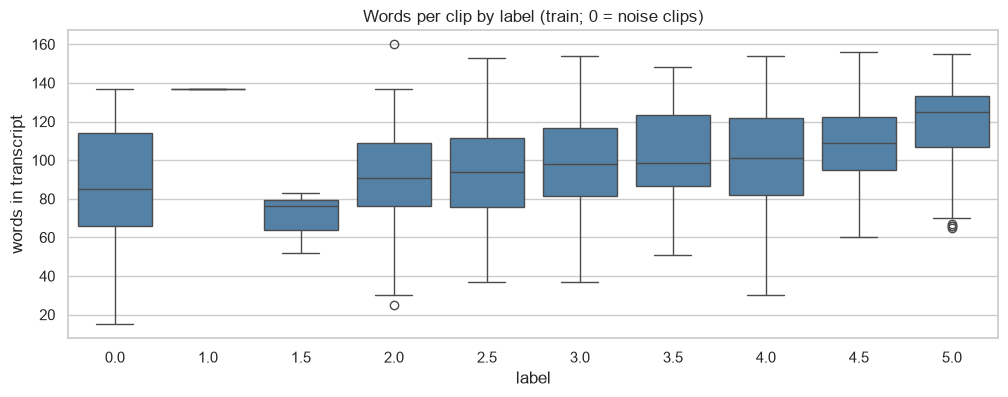

label
0.0     85.0
1.0    137.0
1.5     76.0
2.0     90.5
2.5     94.0
3.0     98.0
3.5     98.5
4.0    101.0
4.5    109.0
5.0    125.0


In [43]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.boxplot(data=asr_train, x="label", y="n_words", color="steelblue", ax=ax)   # one box per label value
ax.set(title="Words per clip by label (train; 0 = noise clips)", xlabel="label", ylabel="words in transcript")
plt.show()
print(asr_train.groupby("label")["n_words"].median().to_string())              # median words per label

#### What to look for
- If the boxes rise with the label, stronger speakers say more in the same time. This makes word count a useful but "unfair"
  feature: it measures fluency, not grammar, so we will use it with care.
- The label-0 box shows how much text Whisper produces on noise.

### Step 16.3 - Empty, very short and very repetitive transcripts

#### Goal
Find transcripts that are likely broken, because a grammar model would learn nonsense from them.

#### How
1. Flag a transcript as **empty** (0 words), **very short** (fewer than 20 words), **repetitive** (more than 15% repeated trigrams)
   or **prompt leak** (it contains a phrase copied from the initial prompt, such as "we went there" or "it was good").
2. Count the flags per split and group, and list the flagged clips with their label and the start of their text.

#### Terms
- **Prompt leak**: words of the initial prompt that Whisper copies into the transcript although they were not said.

In [44]:
SHORT_TRANSCRIPT_WORDS = 20        # fewer words than this in 45-60 s of audio is suspicious
REPETITIVE_TRIGRAM_FRACTION = 0.15 # more than 15% repeated three-word sequences suggests a loop
PROMPT_PHRASES = ["we went there", "it was good"]   # distinctive pieces of DISFLUENT_PROMPT

asr_df["trigram_repeat"] = asr_df["text"].apply(lambda t: repeated_trigram_fraction(text_to_words(t)))
asr_df["flag_empty"] = asr_df["n_words"] == 0
asr_df["flag_short"] = (asr_df["n_words"] > 0) & (asr_df["n_words"] < SHORT_TRANSCRIPT_WORDS)
asr_df["flag_repetitive"] = asr_df["trigram_repeat"] > REPETITIVE_TRIGRAM_FRACTION
asr_df["flag_prompt_leak"] = asr_df["text"].str.lower().apply(lambda t: any(p in t for p in PROMPT_PHRASES))
asr_df["group"] = np.select([asr_df["split"] == "test", asr_df["is_noise"] == True],      # readable group per clip
                            ["test", "train noise"], default="train speech")

flag_columns = ["flag_empty", "flag_short", "flag_repetitive", "flag_prompt_leak"]
print(asr_df.groupby("group")[flag_columns].sum())                                        # counts per group
flagged = asr_df[asr_df[flag_columns].any(axis=1)]
print(f"\nFlagged clips: {len(flagged)}")
print(flagged[["group", "filename", "label", "n_words", "trigram_repeat", "text"]]
      .assign(text=flagged["text"].str[:80]).round(3).to_string(index=False))

              flag_empty  flag_short  flag_repetitive  flag_prompt_leak
group                                                                  
test                   0           1                4                 2
train noise            0           1                5                 5
train speech           0           0                8                 5

Flagged clips: 28
       group       filename  label  n_words  trigram_repeat                                                                             text
train speech  audio_138.wav    2.0       76           0.027 So, uh, we stayed in that resort because we want to, uh, do, we want to go on no
 train noise audio_5066.wav    0.0       97           0.074 It was the best thing I've ever liked in my life, and it was a good thing to rem
 train noise audio_5069.wav    0.0       23           0.190 So, uh, I think, like, we went there and, uh, we went, uh, we went, uh, we went,
 train noise audio_5056.wav    0.0       71           0.3

#### What to look for
- Ideally, flags appear only for noise clips. A flagged **speech** clip needs listening: it may be very quiet, very short
  (Part 1 found clips of 6 to 20 seconds) or a Whisper repetition loop.
- A repetitive transcript inflates word counts and must not be trusted for grammar features.
- "it was good" can of course be said for real, so read a prompt-leak flag before discarding anything.

### Step 16.4 - Remove artifacts caused by the prompt

#### Goal
Step 16.3 showed that the disfluent prompt sometimes backfires. In a few clips Whisper copied the prompt itself
("I think, like, we went there and, you know, we went there ...") or got stuck writing "um, um, um, um, ...".
This happens mostly where a speaker starts after a long silence. These words were never said, so they would distort every
later feature (word counts, filler rates, confidence). Remove them before computing statistics.

At the same time, **genuine repetition must be kept**: "there are a lot of there are a lot of" is the speaker's real
struggle with the sentence, which is exactly what the grammar score is about. So the rule is narrow and only targets the
two signatures of the prompt:
1. A segment that contains the prompt's opening ("i think, like, we went there"), or "we went there" two or more times,
   is a prompt copy. The whole segment and its words are removed.
2. A run of five or more "um" in a row is a hesitation loop. It is removed completely. Listening confirmed that these runs sit on
   silence: audio_444 has almost no "um" there, and audio_375 says "um" several times but spread out, never 20 in a row.
   Real "um" outside such runs are kept.

#### How
1. For every clip, go through its segments. Drop prompt-copy segments, and drop the words whose start time falls inside them.
2. In the remaining text and word list, remove runs of five or more "um".
3. Keep the original text in `text_raw`, and replace `text`, `words`, `segments` and `n_words` with the cleaned versions,
   so Steps 17 to 20 use clean transcripts automatically.
4. Re-save `outputs/asr/transcripts.csv` with both the raw and the cleaned text, and list every changed clip.

#### Terms
- **Artifact**: something in the output that comes from the tool, not from the data.

In [45]:
PROMPT_COPY_OPENING = "i think, like, we went there"   # the prompt's opening words, as Whisper writes them
PROMPT_COPY_PHRASE = "we went there"                    # a phrase from the prompt; twice in one segment = copy
UM_RUN = re.compile(r"\b(um,?\s+){4,}um\b,?", flags=re.IGNORECASE)  # five or more "um" in a row (plus a trailing comma)


def is_prompt_copy(segment_text):
    """True if a segment looks like a copy of the initial prompt."""
    lowered = segment_text.lower()
    return PROMPT_COPY_OPENING in lowered or lowered.count(PROMPT_COPY_PHRASE) >= 2


def remove_um_runs_in_words(words, min_run=5):
    """Remove every run of at least min_run consecutive 'um' words; shorter runs stay as they are."""
    kept, run = [], []                                     # run = the current stretch of consecutive "um" words
    for word in words + [None]:                            # None marks the end, so the last run is also handled
        if word is not None and text_to_words(word["word"]) == ["um"]:
            run.append(word)                               # still inside a run of "um"
            continue
        kept.extend([] if len(run) >= min_run else run)       # long run -> drop it; short run -> keep all
        run = []
        if word is not None:
            kept.append(word)                              # the word that ended the run
    return kept


def clean_record(record):
    """Return text, words, segments of one transcript with prompt copies and um-runs removed."""
    bad_spans = [(s["start"], s["end"]) for s in record["segments"] if is_prompt_copy(s["text"])]  # time spans to remove
    segments = [s for s in record["segments"] if not is_prompt_copy(s["text"])]                    # keep the other segments
    words = [w for w in record["words"]
             if not any(start <= w["start"] < end for start, end in bad_spans)]                     # words outside removed spans
    has_um_run = any(UM_RUN.search(s["text"]) for s in segments)                                   # any hesitation loop left?
    if has_um_run:
        words = remove_um_runs_in_words(words)                                                     # drop the loops
        segments = [{**s, "text": re.sub(r"\s{2,}", " ", UM_RUN.sub("", s["text"])).strip()}       # same fix in the text,
                    for s in segments]                                                             # then tidy double spaces
    text = " ".join(s["text"] for s in segments)                                                   # rebuild the full text
    return pd.Series({"text": text, "words": words, "segments": segments,
                      "n_words": len(words), "n_removed_segments": len(bad_spans), "um_run_fixed": has_um_run})


asr_df["text_raw"] = asr_df["text"]                                     # keep the original transcript
asr_df["n_words_raw"] = asr_df["n_words"]
cleaned = asr_df.apply(clean_record, axis=1)                            # one cleaned row per clip
asr_df[cleaned.columns] = cleaned                                       # replace text, words, segments, n_words

changed = asr_df[(asr_df["n_removed_segments"] > 0) | asr_df["um_run_fixed"]]
print(f"Clips changed: {len(changed)} | per group: {changed['group'].value_counts().to_dict()} | "
      f"words removed in total: {(changed['n_words_raw'] - changed['n_words']).sum()}\n")
print(changed[["group", "filename", "label", "n_words_raw", "n_words", "n_removed_segments", "um_run_fixed"]]
      .to_string(index=False))
asr_df[["split", "filename", "text", "text_raw", "n_words"]].to_csv(TRANSCRIPTS_CSV, index=False)  # raw and clean text
print("\nRe-saved", TRANSCRIPTS_CSV, "with raw and cleaned text")

Clips changed: 9 | per group: {'train noise': 4, 'train speech': 4, 'test': 1} | words removed in total: 116

       group       filename  label  n_words_raw  n_words  n_removed_segments  um_run_fixed
 train noise audio_5069.wav    0.0           23        5                   1         False
 train noise audio_5056.wav    0.0           71       56                   1         False
train speech  audio_444.wav    3.0          128      109                   0          True
 train noise audio_5060.wav    0.0           69       60                   1         False
 train noise audio_5048.wav    0.0           99       81                   1         False
train speech  audio_375.wav    3.5           57       43                   0          True
train speech  audio_642.wav    3.0           47       45                   1         False
train speech  audio_139.wav    4.0           79       76                   1         False
        test   audio_66.wav    NaN           67       49               

#### What to look for
- Only a handful of clips should change, most of them noise clips. If many speech clips changed, the rule would be too broad.
- Speech clips that lose many words (for example a whole 30-second window) are worth listening to: the speaker may have
  been silent or very quiet there, which is when Whisper falls back on the prompt.
- Genuine repetitions such as "there are a lot of there are a lot of" are untouched on purpose.

## Step 17 - ASR statistics per clip

#### Goal
Turn each transcript into numbers that describe how much was said, how fluently, and how confident Whisper was.
They serve the noise gate now and the grammar model later.

#### How
For every clip compute:
1. `n_words` and `words_per_sec` (words divided by the clip duration in seconds): speaking rate.
2. `mean_word_prob` and `min_word_prob`: Whisper's average and lowest word confidence.
3. `mean_no_speech_prob`, `mean_avg_logprob` (averaged over segments) and `max_compression_ratio` (worst segment).
4. `trigram_repeat`: share of repeated trigrams (hallucination signal).
5. `filler_frac`: share of words that are fillers (um, uh, hmm, er, ah, mm, like).
If a transcript has no words or no segments, the "most suspicious" value is used (probability 0, no-speech probability 1,
log probability -5, compression ratio 0), so the table has no gaps.
Save the table to `outputs/asr_stats.csv`.

#### Terms
- **Speaking rate**: words per second. Typical conversational English is about 2 to 3 words per second.
- **Filler**: a word that fills a pause without adding meaning.

In [46]:
def compute_asr_stats(record):
    """Return the ASR statistics of one transcript record (a row of asr_df)."""
    words = text_to_words(record["text"])                         # normalised words for fillers and repeats
    probabilities = [w["probability"] for w in record["words"]]   # Whisper's per-word confidence
    segments = record["segments"]
    return {
        "n_words": record["n_words"],
        "words_per_sec": record["n_words"] / record["duration_s"],
        "mean_word_prob": float(np.mean(probabilities)) if probabilities else 0.0,
        "min_word_prob": float(np.min(probabilities)) if probabilities else 0.0,
        "mean_no_speech_prob": float(np.mean([s["no_speech_prob"] for s in segments])) if segments else 1.0,
        "mean_avg_logprob": float(np.mean([s["avg_logprob"] for s in segments])) if segments else -5.0,
        "max_compression_ratio": float(np.max([s["compression_ratio"] for s in segments])) if segments else 0.0,
        "trigram_repeat": repeated_trigram_fraction(words),
        "filler_frac": sum(w in FILLER_WORDS for w in words) / len(words) if words else 0.0,
    }


ASR_FEATURE_COLUMNS = ["n_words", "words_per_sec", "mean_word_prob", "min_word_prob", "mean_no_speech_prob",
                       "mean_avg_logprob", "max_compression_ratio", "trigram_repeat", "filler_frac"]
asr_stats = pd.concat([asr_df[["split", "filename"]],
                       pd.DataFrame([compute_asr_stats(r) for _, r in asr_df.iterrows()], index=asr_df.index)], axis=1)
ASR_STATS_CSV = os.path.join(OUTPUT_DIR, "asr_stats.csv")
asr_stats.to_csv(ASR_STATS_CSV, index=False)
print("Saved", ASR_STATS_CSV, asr_stats.shape)
asr_stats.groupby(asr_df["group"])[ASR_FEATURE_COLUMNS].median().T.round(3)       # medians per group

Saved .\outputs\asr_stats.csv (985, 11)


group,test,train noise,train speech
n_words,97.500,84.000,104.000
words_per_sec,2.064,1.415,1.881
mean_word_prob,0.894,0.592,0.885
min_word_prob,0.082,0.019,0.085
mean_no_speech_prob,0.180,0.462,0.188
mean_avg_logprob,-0.254,-0.708,-0.279
max_compression_ratio,1.624,1.564,1.608
trigram_repeat,0.021,0.017,0.021
filler_frac,0.011,0.012,0.012


#### What to look for
- Speech clips should have `mean_word_prob` well above 0.5 and `words_per_sec` around 1.5 to 3.
- Compare train speech with test: similar medians mean the test recordings behave like the training ones.

## Step 18 - Noise versus speech through the ASR lens

### Step 18.1 - Boxplots of the ASR statistics

#### Goal
See which ASR statistics behave differently on the noise clips.

#### How
1. Build `gate_table`: the training clips with their Part 1 audio features, their ASR statistics, the label and `is_noise`.
2. Draw one boxplot per ASR statistic, speech versus noise, with the clips as dots.

#### Terms
- None new.

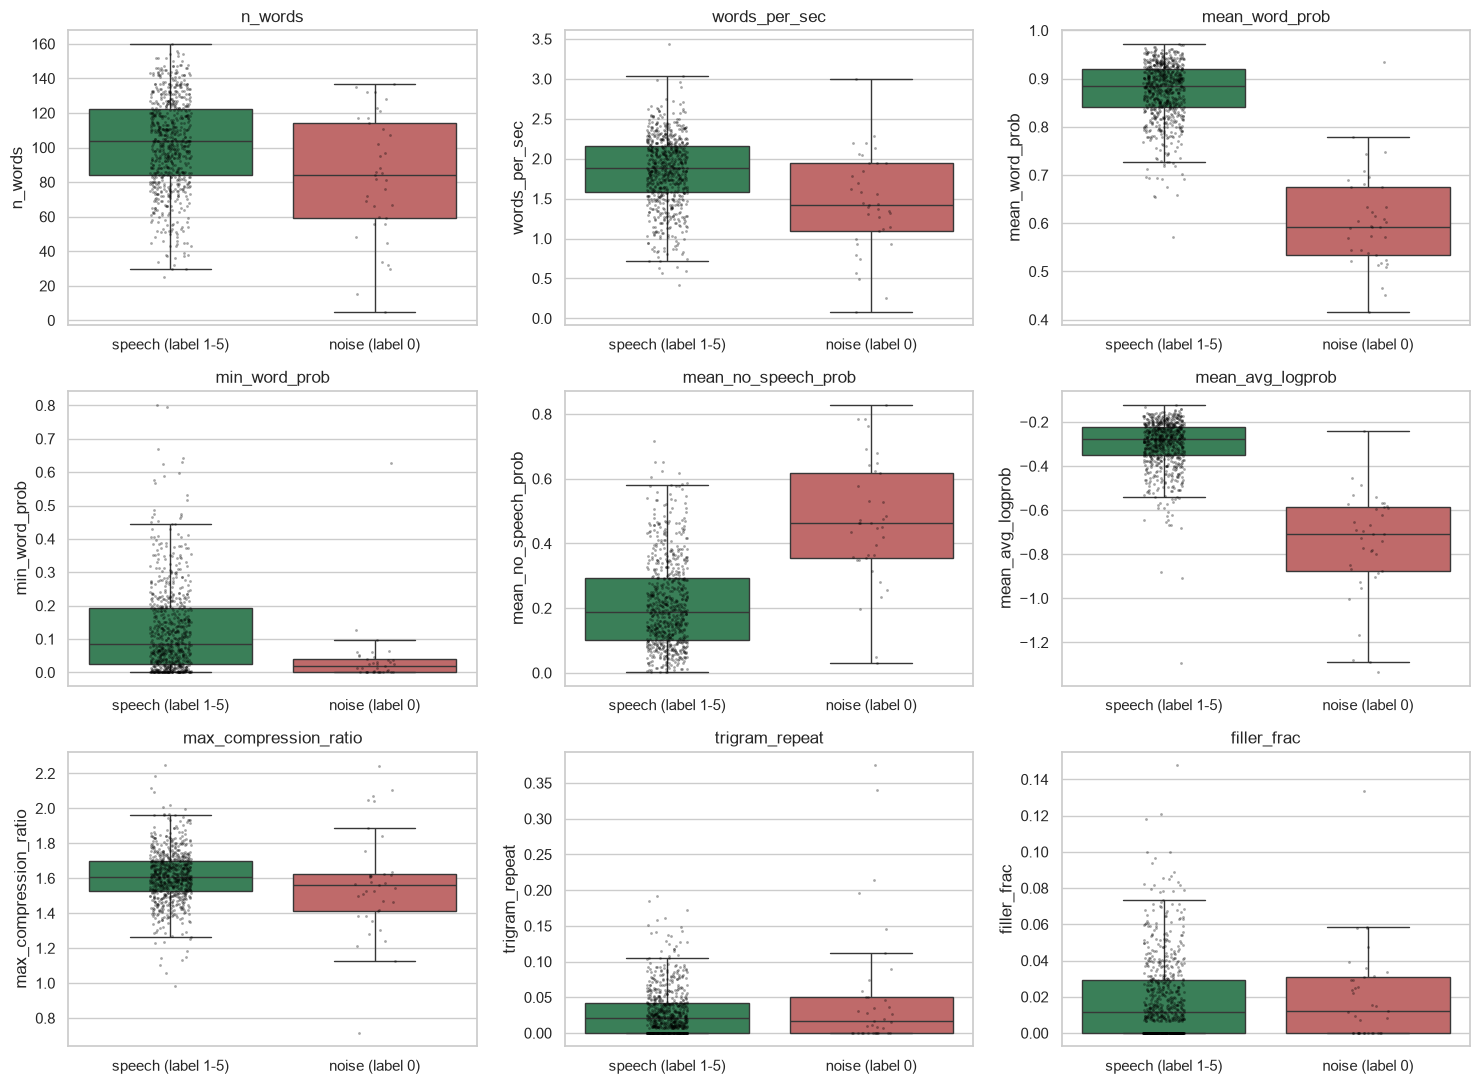

In [47]:
gate_table = (train_df[["split", "filename", "label", "is_noise"]]
              .merge(features_df, on=["split", "filename"], validate="one_to_one")     # Part 1 audio features
              .merge(asr_stats, on=["split", "filename"], validate="one_to_one"))      # ASR statistics
gate_table["group"] = np.where(gate_table["is_noise"], "noise (label 0)", "speech (label 1-5)")

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, feature in zip(axes.flat, ASR_FEATURE_COLUMNS):
    sns.boxplot(data=gate_table, x="group", y=feature, hue="group", order=GROUP_ORDER,
                palette=["seagreen", "indianred"], showfliers=False, legend=False, ax=ax)
    sns.stripplot(data=gate_table, x="group", y=feature, order=GROUP_ORDER, color="black", size=2, alpha=0.35, ax=ax)
    ax.set(title=feature, xlabel="")
plt.tight_layout()
plt.show()

#### What to look for
- Clear separation means Whisper "knows" these clips are different, for example lower word confidence or higher no-speech probability.
- If the noise boxes overlap the speech boxes for most statistics, Whisper treats noise clips almost like speech, which is
  consistent with speech being buried under the noise.

### Step 18.2 - Medians and single-feature ROC AUC for all features

#### Goal
Rank every single feature, acoustic (Part 1) and ASR (Step 17), by how well it alone separates noise from speech.

#### How
1. Print the median of each ASR statistic for speech and noise.
2. For every feature compute the ROC AUC for `is_noise`, the separation strength `max(AUC, 1 - AUC)` and the direction
   (same method as Step 6.4).
3. Plot all features in one horizontal bar chart, coloured by source.

#### Terms
- **ROC AUC**: see Step 6.4. 1.0 or 0.0 = perfect separation, 0.5 = useless.

group                  speech (label 1-5)  noise (label 0)
n_words                           104.000           84.000
words_per_sec                       1.881            1.415
mean_word_prob                      0.885            0.592
min_word_prob                       0.085            0.019
mean_no_speech_prob                 0.188            0.462
mean_avg_logprob                   -0.279           -0.708
max_compression_ratio               1.608            1.564
trigram_repeat                      0.021            0.017
filler_frac                         0.012            0.012 



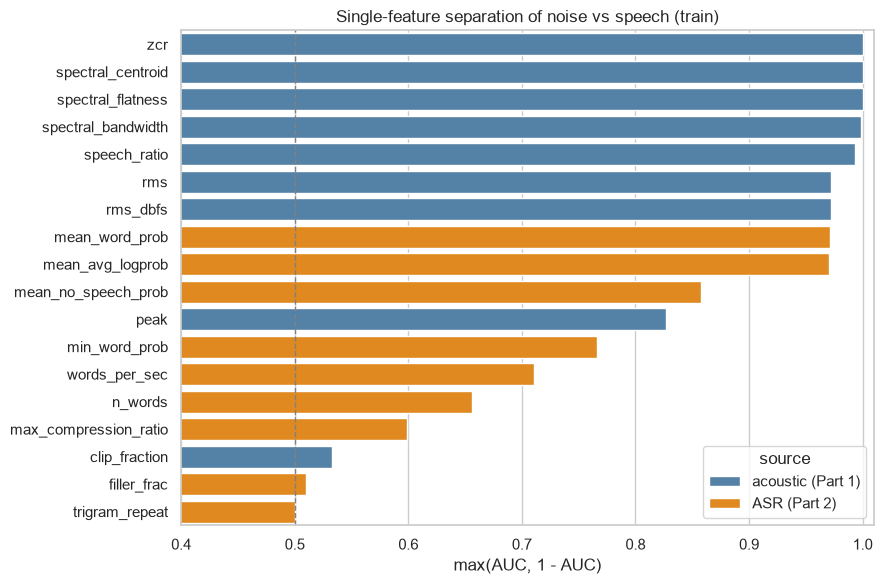

,feature,source,auc,separation,direction
0,zcr,acoustic (Part 1),1.0000,1.0000,higher for noise
1,spectral_centroid,acoustic (Part 1),1.0000,1.0000,higher for noise
2,spectral_flatness,acoustic (Part 1),1.0000,1.0000,higher for noise
3,spectral_bandwidth,acoustic (Part 1),0.9985,0.9985,higher for noise
4,speech_ratio,acoustic (Part 1),0.9932,0.9932,higher for noise
5,rms,acoustic (Part 1),0.9724,0.9724,higher for noise
6,rms_dbfs,acoustic (Part 1),0.9724,0.9724,higher for noise
7,mean_word_prob,ASR (Part 2),0.0290,0.9710,lower for noise
8,mean_avg_logprob,ASR (Part 2),0.0300,0.9700,lower for noise
9,mean_no_speech_prob,ASR (Part 2),0.8574,0.8574,higher for noise


In [48]:
print(gate_table.groupby("group")[ASR_FEATURE_COLUMNS].median().T.loc[:, GROUP_ORDER].round(3).to_string(), "\n")

ranking_rows = []
for source, columns in [("acoustic (Part 1)", FEATURE_COLUMNS), ("ASR (Part 2)", ASR_FEATURE_COLUMNS)]:
    for feature in columns:
        auc = roc_auc_score(gate_table["is_noise"], gate_table[feature])   # chance a noise clip ranks above a speech clip
        ranking_rows.append({"feature": feature, "source": source, "auc": auc, "separation": max(auc, 1 - auc),
                             "direction": "higher for noise" if auc >= 0.5 else "lower for noise"})
feature_ranking = pd.DataFrame(ranking_rows).sort_values("separation", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=feature_ranking, y="feature", x="separation", hue="source",
            palette={"acoustic (Part 1)": "steelblue", "ASR (Part 2)": "darkorange"}, dodge=False, ax=ax)
ax.axvline(0.5, color="grey", linestyle="--", linewidth=1)                 # 0.5 = no better than chance
ax.set(title="Single-feature separation of noise vs speech (train)", xlabel="max(AUC, 1 - AUC)", ylabel="", xlim=(0.4, 1.01))
plt.tight_layout()
plt.show()
feature_ranking.round(4)

#### What to look for
- Bars near 1.0 are features that alone separate the groups. Part 1 already found zcr, spectral centroid and spectral flatness at 1.0.
- An ASR feature near 1.0 adds a second, independent kind of evidence (what Whisper heard, not only the sound spectrum),
  which makes the gate more robust to a different noise type in the test set.

### Step 18.3 - What did Whisper write for the noise clips?

#### Goal
Check whether Whisper recovered real words from the buried speech or produced hallucinations.

#### How
1. Count, per noise clip, the words with probability above 0.5 ("confident words").
2. Print six noise transcripts with their word counts and mean word probability.

#### Terms
- **Confident word**: a word Whisper gives probability above 0.5.

In [49]:
CONFIDENT_WORD_PROB = 0.5                                                   # probability above which a word counts as confident
noise_asr = asr_df[asr_df["group"] == "train noise"].copy()
noise_asr["confident_words"] = noise_asr["words"].apply(lambda ws: sum(w["probability"] > CONFIDENT_WORD_PROB for w in ws))
print(f"Noise clips: {len(noise_asr)} | with no words: {(noise_asr['n_words'] == 0).sum()} | "
      f"median words: {noise_asr['n_words'].median():.0f} | median confident words: {noise_asr['confident_words'].median():.0f}\n")
for _, row in noise_asr.sample(n=6, random_state=SEED).iterrows():           # six reproducible examples
    mean_prob = np.mean([w["probability"] for w in row["words"]]) if row["words"] else 0.0
    print(f"{row['filename']} | words {row['n_words']} | confident {row['confident_words']} | mean prob {mean_prob:.2f}")
    print(textwrap.fill(row["text"][:400] or "(empty)", 120), "\n")

Noise clips: 37 | with no words: 0 | median words: 84 | median confident words: 53

audio_5067.wav | words 59 | confident 35 | mean prob 0.59
Okay, I feel like I have found a festival that is so, so, uh, actually really great. The rooms were very beautiful. To
the point where I'm all according to the theme of the resort that I just mentioned. The rooms were very festival. I will
recommend this to all people too. It's a place that we must visit. 

audio_5061.wav | words 95 | confident 53 | mean prob 0.52
For me, the best day of my life, you know, is the beginning of the day when I come out and I'm, um, focusing on what I
feel to be in you. Umm, it's been completely my life. It's also been different that I've been feeling for you, although
I think it's bad things have happened I have a new story that's new, but for me, that is just like a new way for it to
be in my life. so it's a relationship betw 

audio_5039.wav | words 34 | confident 18 | mean prob 0.52
Umm, the proof playground is a

#### What to look for
- Coherent sentences on a topic, with many confident words, mean Whisper recovered real speech that a human cannot hear.
  Then label 0 really means "speech made unusable on purpose", and the noise gate must rely on the noise, not on the text.
- Short stock phrases ("Thank you.", "Bye.") or the same sentence repeated are hallucinations.

## Step 19 - Noise gate model with honest cross validation

### Step 19.1 - Choose the gate features

#### Goal
Choose a small set of strong, non-redundant features for the gate.

#### How
1. Start from the ranking in Step 18.2.
2. Drop `rms` because `rms_dbfs` holds the same information on another scale.
3. Keep the top `GATE_N_FEATURES = 6`, which must include at least one ASR feature, so the gate uses both kinds of evidence.

Note: the ranking was computed on all training clips, so the cross validation below is very slightly optimistic. With only six
simple features and a large margin this effect is small, but it is the reason the test preview in Step 20 still needs listening.

#### Terms
- **Redundant features**: features that carry the same information; they add nothing and can make a model unstable.
- **Feature selection leakage**: choosing features using data that later serves as validation data.

In [50]:
GATE_N_FEATURES = 6
candidates = feature_ranking[feature_ranking["feature"] != "rms"]                      # rms duplicates rms_dbfs
gate_features = candidates["feature"].head(GATE_N_FEATURES).tolist()                   # the strongest features
if not set(gate_features) & set(ASR_FEATURE_COLUMNS):                                   # no ASR feature made the cut
    best_asr = candidates[candidates["source"] == "ASR (Part 2)"]["feature"].iloc[0]   # best ASR feature
    gate_features = gate_features[:-1] + [best_asr]                                     # swap it in for the weakest
print("Gate features:", gate_features)

Gate features: ['zcr', 'spectral_centroid', 'spectral_flatness', 'spectral_bandwidth', 'speech_ratio', 'mean_word_prob']


#### What to look for
Six features, mostly the perfect acoustic ones from Part 1 plus the best ASR features.

### Step 19.2 - Out-of-fold predictions

#### Goal
Estimate how well the gate works on clips it has **not** seen during training.

#### How
1. Build a `Pipeline`: `StandardScaler` (rescale each feature) followed by `LogisticRegression`.
   Inside cross validation the scaler is fitted on the training folds only, so no information leaks from the validation fold.
2. `class_weight="balanced"` gives the 37 noise clips as much total weight as the 732 speech clips.
3. `StratifiedKFold(5)` splits the 769 clips into 5 folds with the same share of noise clips (about 7) in each.
4. `cross_val_predict` trains on 4 folds and predicts the 5th, five times, so every clip gets one **out-of-fold** probability.

#### Terms
- **Logistic regression**: a linear model that outputs a probability between 0 and 1 for the positive class (here noise).
- **Standardization**: subtract the mean and divide by the standard deviation, so all features have the same scale.
- **Pipeline**: a chain of steps that is fitted and applied as one model.
- **Leakage**: information from the validation data influencing training, which makes results look better than they are.
- **Stratified k-fold cross validation**: k train/validation splits that keep the class proportions equal in every fold.
- **Out-of-fold (OOF) prediction**: a prediction for a clip made by a model that was trained without that clip.

In [51]:
gate_model = Pipeline([
    ("scale", StandardScaler()),                                                       # fitted on the training folds only
    ("logreg", LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000)),     # small linear model
])
X_gate = gate_table[gate_features]                                                     # inputs: 769 x 6
y_gate = gate_table["is_noise"].astype(int)                                            # target: 1 = noise, 0 = speech
gate_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)                 # 5 folds, reproducible shuffle
gate_table["oof_noise_prob"] = cross_val_predict(gate_model, X_gate, y_gate, cv=gate_cv,
                                                 method="predict_proba")[:, 1]         # column 1 = probability of noise
print(f"Out-of-fold ROC AUC: {roc_auc_score(y_gate, gate_table['oof_noise_prob']):.4f}")

Out-of-fold ROC AUC: 1.0000


#### What to look for
An out-of-fold ROC AUC of 1.0 means that on every fold all noise clips got a higher probability than all speech clips.

### Step 19.3 - Choose the threshold from the out-of-fold probabilities

#### Goal
Turn probabilities into yes/no decisions with a threshold chosen on out-of-fold predictions, not on the training fit
(the training fit is over-confident on clips it has seen).

#### How
1. Try thresholds from 0.01 to 0.99.
2. For each, compute the F1 score of the noise class on the out-of-fold probabilities.
3. Among the thresholds with the best F1, take the middle one: it leaves the largest safety margin on both sides.
4. Report precision, recall and the confusion matrix at that threshold.

#### Terms
- **Threshold**: probability above which a clip is called noise.
- **Precision (noise)**: of the clips called noise, the share that really are noise.
- **Recall (noise)**: of the real noise clips, the share that were caught.
- **F1 score**: the harmonic mean of precision and recall; high only if both are high.
- **Confusion matrix**: a 2 x 2 table of true classes (rows) against predicted classes (columns).

In [52]:
thresholds = np.round(np.arange(0.01, 1.00, 0.01), 2)                                  # candidate thresholds
f1_scores = np.array([f1_score(y_gate, gate_table["oof_noise_prob"] >= t) for t in thresholds])
best_thresholds = thresholds[f1_scores == f1_scores.max()]                             # all thresholds with the best F1
GATE_THRESHOLD = float(best_thresholds[len(best_thresholds) // 2])                     # the middle one
gate_table["oof_pred_noise"] = gate_table["oof_noise_prob"] >= GATE_THRESHOLD

print(f"Best F1 {f1_scores.max():.3f} for thresholds {best_thresholds.min():.2f} to {best_thresholds.max():.2f} "
      f"-> chosen threshold {GATE_THRESHOLD:.2f}")
print(f"Noise precision: {precision_score(y_gate, gate_table['oof_pred_noise']):.3f} | "
      f"noise recall: {recall_score(y_gate, gate_table['oof_pred_noise']):.3f}")
pd.DataFrame(confusion_matrix(y_gate, gate_table["oof_pred_noise"]),
             index=["true speech", "true noise"], columns=["predicted speech", "predicted noise"])

Best F1 1.000 for thresholds 0.05 to 0.99 -> chosen threshold 0.52
Noise precision: 1.000 | noise recall: 1.000


,predicted speech,predicted noise
true speech,732,0
true noise,0,37


#### What to look for
- A wide range of equally good thresholds means the two groups are far apart, so the exact threshold does not matter much.
- Off-diagonal cells in the confusion matrix are mistakes: top right = speech wrongly gated (it would lose its score),
  bottom left = noise that slipped through.

### Step 19.4 - Probability histogram and the clips to listen to

#### Goal
See how far apart the two groups are, and list the clips that were misclassified or came closest to the threshold.

#### How
1. Plot histograms of the out-of-fold noise probability for speech and noise, with a log y-axis so the small noise group is visible,
   and a dashed line at the threshold.
2. List the misclassified clips, then the 5 speech clips with the highest and the 5 noise clips with the lowest probability.

#### Terms
- **Log scale**: an axis where each step multiplies the value by 10, so very different counts fit in one plot.

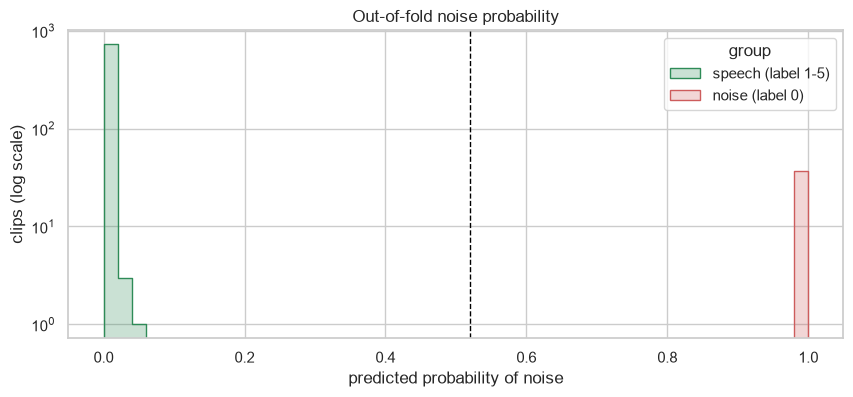

Misclassified clips: 0

Speech clips closest to the threshold:
     filename  label  oof_noise_prob    zcr  spectral_centroid  spectral_flatness  spectral_bandwidth  speech_ratio  mean_word_prob
 audio_79.wav    2.0          0.0477 0.3344          3162.1201             0.1326           1964.1869        0.5269          0.8515
 audio_80.wav    2.0          0.0357 0.1895          2589.2244             0.0714           2451.0665        1.0000          0.9287
audio_176.wav    4.5          0.0297 0.3111          2983.1377             0.0993           1849.1876        0.5533          0.7867
audio_161.wav    3.0          0.0236 0.3126          3045.9735             0.1930           2168.3975        0.2791          0.8954
audio_141.wav    3.0          0.0178 0.3327          3045.6290             0.1620           1920.9866        0.3454          0.8767

Noise clips closest to the threshold:
      filename  label  oof_noise_prob    zcr  spectral_centroid  spectral_flatness  spectral_bandwidth  sp

In [53]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(data=gate_table, x="oof_noise_prob", hue="group", hue_order=GROUP_ORDER, palette=["seagreen", "indianred"],
             bins=50, element="step", ax=ax)
ax.axvline(GATE_THRESHOLD, color="black", linestyle="--", linewidth=1)
ax.set(yscale="log", title="Out-of-fold noise probability", xlabel="predicted probability of noise", ylabel="clips (log scale)")
plt.show()

show_columns = ["filename", "label", "oof_noise_prob"] + gate_features
misclassified = gate_table[gate_table["oof_pred_noise"] != gate_table["is_noise"]]
print(f"Misclassified clips: {len(misclassified)}")
if len(misclassified):
    print(misclassified[show_columns].round(4).to_string(index=False))
print("\nSpeech clips closest to the threshold:")
print(gate_table[~gate_table["is_noise"]].nlargest(5, "oof_noise_prob")[show_columns].round(4).to_string(index=False))
print("\nNoise clips closest to the threshold:")
print(gate_table[gate_table["is_noise"]].nsmallest(5, "oof_noise_prob")[show_columns].round(4).to_string(index=False))

#### What to look for
- Good: the green and red histograms sit at opposite ends with an empty space in between, and no clip is misclassified.
- The "closest" lists are the clips to listen to. A speech clip with a high noise probability may be a genuinely noisy
  recording, which is useful to know for the grammar model too.

## Step 20 - Test set preview of the noise gate

#### Goal
Apply the gate to the test clips to see how many look like the training noise clips. **This is a preview only.**

#### How
1. Fit a fresh copy of the gate pipeline on all 769 training clips.
2. Build the same features for the 216 test clips and predict their noise probability.
3. Count the clips at or above the threshold, show their statistics and the start of their transcripts, and list the filenames.
4. Save `outputs/noise_gate_predictions.csv` (train out-of-fold and test probabilities) for later parts.

#### Terms
- **Final fit**: training the model on all available labelled data after cross validation has estimated its quality.

In [54]:
final_gate = clone(gate_model).fit(X_gate, y_gate)                                     # trained on all train clips
test_gate = (test_df[["split", "filename"]]
             .merge(features_df, on=["split", "filename"], validate="one_to_one")      # Part 1 audio features
             .merge(asr_stats, on=["split", "filename"], validate="one_to_one")        # ASR statistics
             .merge(asr_df[["split", "filename", "text"]], on=["split", "filename"]))  # transcript text
test_gate["noise_prob"] = final_gate.predict_proba(test_gate[gate_features])[:, 1]
test_gate["pred_noise"] = test_gate["noise_prob"] >= GATE_THRESHOLD

flagged_test = test_gate[test_gate["pred_noise"]]
print(f"PREVIEW ONLY: {len(flagged_test)} of {len(test_gate)} test clips flagged as noise (threshold {GATE_THRESHOLD:.2f})")
print(f"Highest test noise probability: {test_gate['noise_prob'].max():.4f}\n")
display_columns = ["filename", "noise_prob"] + gate_features
if len(flagged_test):
    print(flagged_test[display_columns].round(4).to_string(index=False))
    for row in flagged_test.itertuples(index=False):
        print(f"{row.filename}: {row.text[:150]}")
print("\nMost noise-like test clips:")
print(test_gate.nlargest(5, "noise_prob")[display_columns].round(4).to_string(index=False))

gate_predictions = pd.concat([
    gate_table[["split", "filename", "oof_noise_prob"]].rename(columns={"oof_noise_prob": "noise_prob"}),
    test_gate[["split", "filename", "noise_prob"]]], ignore_index=True)
gate_predictions["pred_noise"] = gate_predictions["noise_prob"] >= GATE_THRESHOLD
gate_predictions.to_csv(os.path.join(OUTPUT_DIR, "noise_gate_predictions.csv"), index=False)

PREVIEW ONLY: 0 of 216 test clips flagged as noise (threshold 0.52)
Highest test noise probability: 0.0262


Most noise-like test clips:
     filename  noise_prob    zcr  spectral_centroid  spectral_flatness  spectral_bandwidth  speech_ratio  mean_word_prob
 audio_38.wav      0.0262 0.3013          2776.1230             0.2456           1863.2125        0.4186          0.8662
 audio_22.wav      0.0251 0.3108          3042.5899             0.1117           1889.4037        0.7187          0.9251
 audio_28.wav      0.0236 0.2980          2829.2429             0.1375           1940.7349        0.6358          0.8814
audio_113.wav      0.0077 0.2269          2457.8208             0.0555           1740.7760        0.8731          0.8590
audio_163.wav      0.0072 0.1406          1978.4535             0.0411           1892.7991        1.0000          0.7687


#### What to look for
- Part 1 already suggested that the test set has no white-noise clips like the training ones, so 0 flagged clips is the expected result.
- If clips are flagged, listen to them (remember: test files are different recordings from train files with the same name).
- The highest test probability shows how close any test clip comes to the threshold.

## Part 2 summary

These numbers come from the local run (openai-whisper 20250625, `small` model, RTX 4060 laptop GPU).

### Findings

**ASR setup and runtime**
- openai-whisper was used. faster-whisper was tried first, but its GPU engine needs CUDA 12 libraries, while this environment's PyTorch uses CUDA 13.2.
- The pilot (Steps 13 and 14, 24 clips) compared the small model with and without the disfluent prompt. Without the prompt Whisper wrote
  0 hesitations per 100 words; with it 2.2. Repeats rose from 0.41 to 0.62 per 100 words, and the two versions differed on only 8.6% of words.
  The `small` model with the prompt was chosen. The medium model was not tried: loading it ran the laptop out of RAM.
- Full run: 985 of 985 clips and 0 errors. The transcription took 146 minutes in total (real-time factor 0.164, about 8.9 s per clip),
  with a peak of 1.23 GiB of GPU memory.

**Transcript quality**
- No transcript is empty. Only two are very short: test/audio_107 (8 words; the clip is 6.5 s long) and one noise clip.
- Words per clip rise with the score: median 90.5 words at label 2.0, 98 at 3.0, 101 at 4.0 and 125 at 5.0.
  Word count therefore carries a fluency signal, but it is not a pure grammar measure.
- **The prompt sometimes backfires.** Where a speaker starts after a long silence (many clips begin with 20 to 30 s of silence),
  Whisper copied the prompt ("I think, like, we went there and, you know, ...") or looped on "um, um, um". Step 16.4 removed these artifacts
  from 9 clips (4 speech, 1 test, 4 noise; 116 words in total). Genuine repetitions such as "there are a lot of there are a lot of" were kept.
- Eight speech clips are flagged as repetitive (more than 15% repeated trigrams). Reading them shows real speaker repetition
  ("a crowded market is a, is a, is a"), which is evidence for the grammar score, not an ASR error.

**Noise clips through the ASR lens**
- Whisper recovers speech from **all** 37 noise clips: a median of 84 words, of which 53 are confident (probability above 0.5),
  with coherent, on-topic sentences (for example audio_5072: "My goal is, I want to earn sufficient and honest money for me and my family...").
  This confirms that label 0 means "real speech made unusable by added noise", not silence.
- Whisper is less sure on noise: median word probability 0.59 vs 0.89 for speech (AUC 0.971), and average log probability -0.71 vs -0.28.
  But no ASR feature separates perfectly, and one noise clip (audio_5044) even has a mean word probability of 0.94.
  The acoustic features from Part 1 (zcr, spectral centroid, spectral flatness: AUC 1.0) remain the reliable signal.

**Noise gate (Step 19)**
- Features: zcr, spectral_centroid, spectral_flatness, spectral_bandwidth, speech_ratio and mean_word_prob, in a standardized logistic regression.
- 5-fold stratified cross validation: out-of-fold ROC AUC 1.000, noise precision 1.000 and recall 1.000 at threshold 0.52, and 0 misclassified clips.
  Every threshold from 0.05 to 0.99 is equally good. The closest speech clip (audio_79, label 2.0) gets 0.048,
  and the closest noise clip (audio_5044) gets 0.992.
- Caveat: the features were ranked on all training clips before cross validation, so the estimate is very slightly optimistic.

**Test preview (Step 20)**
- 0 of 216 test clips are flagged as noise. The highest test probability is 0.026 (test/audio_38).
  Together with Part 1, this strongly suggests the test set contains no noise clips of the training kind. This is a preview, not a final decision.

**Checked by ear**
- train/audio_139 (label 4.0) and audio_642 (label 3.0): both have a genuine delayed start. The removed prompt copies sat on silence,
  so no real speech was lost.
- train/audio_444 and audio_375: neither speaker says "um" 20 times in a row. audio_444 has mostly silence there, and audio_375 says
  "um" several times, but spread out. So the "um" runs are Whisper inventing hesitations during silence, and Step 16.4 removes each run
  completely; the speaker's real, spread-out "um" are kept.
- test/audio_66: a long silence at the start, followed by speech that is hard to understand even for a human. The removed prompt copy
  sat in that silence. The rest of its transcript should be treated as uncertain.
- train/audio_5044 (a noise clip with mean word probability 0.94): the speech is not audible to a human, so its transcript cannot be
  checked by ear. Whisper's confidence on noise clips simply cannot be verified, which is one more reason the gate must not depend on it.

### Next steps (Part 3: Features)
1. **Handcrafted text features** from the cleaned transcripts: sentence count and length, clause markers (because, which, although),
   verb-form and agreement errors from a grammar checker, part-of-speech patterns, type-token ratio.
2. **Fluency features** from the word timestamps: speaking rate, pause count and length, hesitation and repeat rates, and the
   Whisper confidence statistics from Step 17. Use them with care, because they measure fluency rather than grammar.
3. **Handling the noise clips:** train the grammar model on the 732 speech clips only (labels 1 to 5), and use the noise gate to assign 0 to gated clips.
4. **Baseline models** (Part 4): start with ridge regression and gradient boosting on these features. Report training RMSE,
   cross-validated RMSE and Pearson correlation, and compare with the mean-predictor baseline from Step 3.3 (RMSE 1.014).

# PART 3: Feature extraction

**What this part does**
- Turns every clip into numbers ("features") that a model in Part 4 can learn from. A **feature** is one number that describes
  one property of a clip, for example "grammar edits per 100 words = 4.2" or "speaking rate = 2.1 words per second".
- It builds three groups of features, from the transcripts and word timings of Part 2 and from the audio itself (see the map below).
- It saves every group to `outputs/features/`, one row per clip, always in the same row order.
- At the end it **explores** how the features relate to the grammar score, to see which ones look useful.

**What this part does NOT do**
- It trains no model, and nothing in it is fitted using the labels: no scaling, no feature selection, no PCA used for modelling.
  The labels are only *looked at* in the exploration steps at the end (Steps 37 to 39).
- **Leakage** means information from the answers sneaking into the inputs. Example: if we picked the 10 features that correlate best
  with the score on all training clips, and then cross validated a model on those same clips, the validation score would look
  better than it really is, because the feature choice already "saw" the validation labels. That is why feature selection
  belongs inside the cross validation of Part 4, not here.
- It downloads nothing and installs nothing. Models are loaded from a local folder if one exists, otherwise from the library's own cache.

**A change from the original plan: grammar errors without Java**
The plan was to count grammar errors with LanguageTool, a rule-based grammar checker. LanguageTool runs as a Java program,
and Java is not available in this environment. Instead we use the method of the *Gramformer* project: a small neural model rewrites
each sentence into correct English, and the tool ERRANT lists and labels every change it made (for example "wrong verb tense").
This needs no Java, and its error categories are about grammar, not about punctuation, which suits speech transcripts better.

## Part 3 map

| Group | Step | What it measures | Saved file in `outputs/features/` |
|---|---|---|---|
| **5a Text** | 23 | Grammar edits made by a correction model, per category | `gec_errors.csv` |
| | 24 | Sentence length, parts of speech, tenses, parse-tree depth, subordinate clauses | `spacy_features.csv` |
| | 25 | Vocabulary variety (type-token ratios) | kept in memory, part of `text_features.csv` |
| | 26 | How predictable the text is for GPT-2 (perplexity) | `gpt2_perplexity.csv` |
| | 28 | All 5a features together | `text_features.csv` |
| **5b Fluency** | 29 to 32 | Speaking rate, pauses, fillers, repeats, Whisper confidence | `fluency_features.csv` |
| **5c Embeddings** | 33 | Audio embeddings from WavLM (layer 6 and last layer) | `audio_emb_layer6.npy`, `audio_emb_last.npy`, `audio_emb_index.csv` |
| | 34 | Text embeddings from DeBERTa | `text_emb_deberta.npy`, `text_emb_index.csv` |
| **Combined** | 36 | 5a + 5b in one table (embeddings stay in their own files) | `features_all.csv` |

Every file has one row per clip, in the order of the **master index** built in Step 21.4. An assertion checks this each time a file is saved.

## Step 21 - Part 3 setup

### Step 21.1 - Part 3 run switches

#### Goal
Collect the settings that control the slow steps of Part 3 in one place, like the Part 2 switches in Step 11.1.

#### How
1. One switch per slow feature group decides whether it may be computed.
2. `USE_CACHED_FEATURES` decides whether saved feature files are reused.
3. Create the folder `outputs/features/`. On Kaggle, if an attached dataset contains a `features` folder with saved results,
   copy it into the working folder (same idea as the `asr` folder in Step 11.1).

| Switch | Default | What it does | On Kaggle |
|---|---|---|---|
| `RUN_GEC` | `True` | Run the grammar correction model and ERRANT (Step 23). | `False` if you attached the saved `features` folder. |
| `RUN_SPACY` | `True` | Compute the spaCy features (Step 24). | `False` with the saved folder, or `True`: spaCy is fast. |
| `RUN_GPT2` | `True` | Compute the GPT-2 perplexity (Step 26). | `False` with the saved folder. |
| `RUN_AUDIO_EMBEDDINGS` | `True` | Compute the WavLM audio embeddings (Step 33). | `False` with the saved folder (needs a GPU otherwise). |
| `RUN_TEXT_EMBEDDINGS` | `True` | Compute the DeBERTa text embeddings (Step 34). | `False` with the saved folder. |
| `USE_CACHED_FEATURES` | `True` | `True`: load saved files and only compute clips that are missing. `False`: delete the saved file of each group that runs and compute it again. | Leave `True`. |

A group whose switch is `False` and that has no saved file is simply left empty (missing values), and the notebook still runs to the end.

#### Terms
- **Cache**: a saved result that is loaded instead of computed again. Example: `outputs/asr_stats.csv` from Part 2.
- **Resumable**: a long loop that writes its results as it goes, so after an interruption it continues where it stopped.

In [55]:
RUN_GEC = True               # grammar error correction model + ERRANT (Step 23)
RUN_SPACY = True             # spaCy sentence, part-of-speech, tense and parse features (Step 24)
RUN_GPT2 = True              # GPT-2 perplexity (Step 26)
RUN_AUDIO_EMBEDDINGS = True  # WavLM audio embeddings (Step 33)
RUN_TEXT_EMBEDDINGS = True   # DeBERTa text embeddings (Step 34)
USE_CACHED_FEATURES = True   # True = reuse saved feature files; False = recompute the groups that run

FEATURES_DIR = os.path.join(OUTPUT_DIR, "features")   # every Part 3 file is saved in this folder
os.makedirs(FEATURES_DIR, exist_ok=True)              # create it if needed

if IS_KAGGLE and not os.listdir(FEATURES_DIR):                         # nothing saved yet in /kaggle/working
    for folder, subfolders, files in os.walk("/kaggle/input"):         # look for an attached "features" folder
        if os.path.basename(folder) == "features" and "features_all.csv" in files:
            shutil.copytree(folder, FEATURES_DIR, dirs_exist_ok=True)  # copy the saved results into place
            print("Copied saved feature files from", folder)
            break

print("RUN_GEC:", RUN_GEC, "| RUN_SPACY:", RUN_SPACY, "| RUN_GPT2:", RUN_GPT2,
      "| RUN_AUDIO_EMBEDDINGS:", RUN_AUDIO_EMBEDDINGS, "| RUN_TEXT_EMBEDDINGS:", RUN_TEXT_EMBEDDINGS,
      "| USE_CACHED_FEATURES:", USE_CACHED_FEATURES)
print("Features folder:", FEATURES_DIR, "| saved files:", sorted(os.listdir(FEATURES_DIR)))

RUN_GEC: True | RUN_SPACY: True | RUN_GPT2: True | RUN_AUDIO_EMBEDDINGS: True | RUN_TEXT_EMBEDDINGS: True | USE_CACHED_FEATURES: True
Features folder: .\outputs\features | saved files: ['audio_emb_index.csv', 'audio_emb_last.npy', 'audio_emb_layer6.npy', 'features_all.csv', 'fluency_features.csv', 'gec_errors.csv', 'gpt2_perplexity.csv', 'spacy_features.csv', 'text_emb_deberta.npy', 'text_emb_index.csv', 'text_features.csv']


#### What to look for
- Locally the folder is `./outputs/features`. On the first run it is empty; after a full run it lists all the files from the map above.
- On Kaggle with the switches set to `False`, the list must contain the saved files, otherwise those feature groups stay empty.

### Step 21.2 - New imports, device and versions

#### Goal
Import only the libraries that Parts 1 and 2 did not import, and print the versions and the GPU, so a result can be traced to its setup.

#### How
1. Import the new tools: statistics functions from SciPy, PCA from scikit-learn, Hugging Face `transformers`, `spaCy` and `errant`.
2. `errant` is imported inside `try`, so the notebook still runs from saved files where it is not installed.
3. Lower the logging level of `transformers` so it prints only real errors (it otherwise prints long loading reports, explained in Step 34).
   Also hide one harmless deprecation notice that DeBERTa's library code prints (`torch.jit.script` is deprecated).
4. Set `DISABLE_SAFETENSORS_CONVERSION`. When transformers loads weights stored in the older `.bin` format, it otherwise starts a
   background thread that asks the Hugging Face website whether a converted copy exists, even with `local_files_only=True`.
   An offline notebook must not do that (Step 21.3).
5. Reuse `DEVICE` and `USE_FP16` from Step 11.2 and print the GPU name and free memory.

#### Terms
- **transformers**: the Hugging Face library that downloads and runs pretrained neural networks (GPT-2, WavLM, DeBERTa, T5).
- **spaCy**: a library that analyses text: it splits sentences, tags each word's part of speech (noun, verb, ...) and builds a parse tree.
- **ERRANT**: a tool that compares an original sentence with a corrected one and labels each change, e.g. `R:VERB:TENSE` for "go -> went".
- **Pretrained model**: a network already trained by someone else on a large dataset; we only use it, we do not train it.
- **Environment variable**: a named setting that programs read from the operating system, e.g. `os.environ["NAME"] = "1"`.

In [56]:
import torch.nn.functional as F                   # cross_entropy: the per-token loss used for GPT-2 perplexity
from scipy.stats import spearmanr, ks_2samp       # rank correlation (Step 37) and the train/test shift test (Step 39)
from sklearn.decomposition import PCA             # squeezes 1536 numbers into 2 for the plots in Step 35 (drawing only)
import transformers                               # Hugging Face library for pretrained networks
from transformers import (AutoTokenizer, AutoModel, AutoModelForCausalLM,   # "Auto" classes pick the right
                          AutoModelForSeq2SeqLM, AutoFeatureExtractor)      # architecture from the model name
import spacy                                      # sentence splitting, part-of-speech tags, parse trees
from huggingface_hub import try_to_load_from_cache  # checks whether a model file is already on disk (Step 21.3)

try:
    import errant                                 # labels the edits between an original and a corrected sentence
except ImportError:                               # not installed: grammar errors can only be loaded from the saved file
    errant = None

transformers.logging.set_verbosity_error()        # print only real errors, not loading reports
os.environ["DISABLE_SAFETENSORS_CONVERSION"] = "1"  # stop transformers from asking the Hub to convert .bin weights (Step 21.3)
warnings.filterwarnings("ignore", message=".*torch.jit.script.*deprecated")  # harmless notice from DeBERTa's library code

for package in ["torch", "transformers", "tokenizers", "sentencepiece", "numpy", "pandas", "scikit-learn",
                "scipy", "matplotlib", "seaborn", "tqdm", "spacy", "en_core_web_sm", "errant"]:
    try:
        print(f"{package:<15} {version(package)}")         # version() was imported in Step 11.2
    except Exception:
        print(f"{package:<15} NOT INSTALLED")
print("device         ", DEVICE, "| fp16:", USE_FP16)       # chosen in Step 11.2
if DEVICE == "cuda":
    free_bytes, total_bytes = torch.cuda.mem_get_info()     # free and total GPU memory in bytes
    print("GPU            ", torch.cuda.get_device_name(0), f"| VRAM free {free_bytes / 2**30:.1f} of {total_bytes / 2**30:.1f} GiB")

torch           2.14.1+cu132
transformers    5.18.0
tokenizers      0.23.2
sentencepiece   0.2.2
numpy           2.5.2
pandas          3.0.6
scikit-learn    1.9.1
scipy           1.18.1
matplotlib      3.11.2
seaborn         0.13.2
tqdm            4.70.1
spacy           3.8.16
en_core_web_sm  3.8.0
errant          3.0.2
device          cuda | fp16: True
GPU             NVIDIA GeForce RTX 4060 Laptop GPU | VRAM free 6.9 of 8.0 GiB


#### What to look for
- Every package should have a version. `errant NOT INSTALLED` means Step 23 can only load `gec_errors.csv`, not compute it.
- `device cuda` is needed for a fast run of Steps 23, 26, 33 and 34. On `cpu` they work but take several times longer.

### Step 21.3 - Where the models come from (offline support)

#### Goal
Load every model from a local folder when one exists (for example a Kaggle dataset under `/kaggle/input`, which works without internet),
and otherwise from the library's normal cache.

#### How
1. List the five models of this part, plus a fallback for the two embedding models.
2. `resolve_model_source(name)` searches the local model folders (`/kaggle/input` on Kaggle, `./models` locally) for a folder named
   like the model (for example `wavlm-base-plus`) that contains a model configuration file.
3. If it finds one, it returns that folder; if not, it returns the model name, and the library loads it from its cache
   (`~/.cache/huggingface` or the spaCy package), downloading it only the very first time.
4. `load_options(source)` returns `local_files_only=True` when the model is already in the cache. Without it, the library still contacts
   the Hub on every load (to check for newer files), which is exactly what an offline notebook must not do.
5. Load the spaCy English model now, because both ERRANT (Step 23) and the spaCy features (Step 24) use it.

#### Terms
- **Hugging Face Hub**: the website that hosts pretrained models; a model name like `microsoft/wavlm-base-plus` is its address there.
- **Model cache**: a folder on disk where the library keeps downloaded models, so the second load needs no internet.
- **Fallback**: a second choice used only if the first one fails to load.
- **`local_files_only=True`**: an option of `from_pretrained` that forbids any internet access and uses the files on disk only.

In [57]:
MODEL_NAMES = {
    "gec": "prithivida/grammar_error_correcter_v1",  # T5 grammar correction model used by Gramformer (Step 23)
    "spacy": "en_core_web_sm",                       # small English spaCy pipeline (Steps 23 and 24)
    "gpt2": "gpt2",                                  # the smallest GPT-2 language model (Step 26)
    "audio": "microsoft/wavlm-base-plus",            # speech model for the audio embeddings (Step 33)
    "audio_fallback": "facebook/wav2vec2-base",      # used only if WavLM fails to load
    "text": "microsoft/deberta-v3-base",             # text model for the text embeddings (Step 34)
    "text_fallback": "roberta-base",                 # used only if DeBERTa or its tokenizer fails to load
}
LOCAL_MODEL_DIRS = ["/kaggle/input"] if IS_KAGGLE else [os.path.join(".", "models")]   # where to look first


def resolve_model_source(name):
    """Return a local folder that holds the model, or the model name itself to use the library cache."""
    folder_name = name.split("/")[-1]                                   # "microsoft/wavlm-base-plus" -> "wavlm-base-plus"
    for root in LOCAL_MODEL_DIRS:
        if not os.path.isdir(root):                                     # the folder does not exist on this machine
            continue
        for folder, subfolders, files in os.walk(root):                 # visit every folder below root
            base = os.path.basename(folder)
            if base == folder_name and "config.json" in files:          # a Hugging Face model folder
                return folder
            if base.startswith(folder_name + "-") and "config.cfg" in files:  # a spaCy model folder, e.g. en_core_web_sm-3.8.0
                return folder
    return name                                                         # no local copy: use the library cache


def load_options(source):
    """Extra from_pretrained arguments: stay offline when the model is a local folder or already in the cache."""
    if os.path.isdir(source):
        return {}                                                       # a folder path never needs the internet
    cached = try_to_load_from_cache(source, "config.json")              # path of the cached file, or None
    return {"local_files_only": True} if isinstance(cached, str) else {}


for key, name in MODEL_NAMES.items():
    source = resolve_model_source(name)
    if os.path.isdir(source):
        status = "local folder"
    elif key == "spacy":                                                 # spaCy models are installed Python packages
        status = "installed package" if spacy.util.is_package(source) else "NOT INSTALLED"
    else:
        status = "in cache" if load_options(source) else "not cached (would download)"
    print(f"{key:<15} -> {source:<40} {status}")                        # where each model will be loaded from

nlp = spacy.load(resolve_model_source(MODEL_NAMES["spacy"]))            # the spaCy English pipeline, used in Steps 23-24
print("spaCy pipeline steps:", nlp.pipe_names)

gec             -> prithivida/grammar_error_correcter_v1    in cache
spacy           -> en_core_web_sm                           installed package
gpt2            -> gpt2                                     in cache
audio           -> microsoft/wavlm-base-plus                in cache
audio_fallback  -> facebook/wav2vec2-base                   not cached (would download)
text            -> microsoft/deberta-v3-base                in cache
text_fallback   -> roberta-base                             not cached (would download)


spaCy pipeline steps: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


#### What to look for
- Locally every line usually shows the plain model name and `in cache`: no `./models` folder exists, so the cache is used, offline.
  The two fallback models may show `not cached`; that only matters if a first-choice model fails to load.
  The spaCy model is a Python package, not a Hugging Face model, so it shows `installed package` instead.
- On Kaggle with attached model datasets, the lines should show paths under `/kaggle/input`. A plain name there means the model
  will be downloaded, which fails when the notebook has no internet.
- The spaCy pipeline should list `tagger`, `parser` and `lemmatizer` among its steps; Step 24 needs all three.

### Step 21.4 - The master index and the transcripts

#### Goal
Fix one row order for all 985 clips, and attach the cleaned transcripts and word timings of Part 2 in that order.
Every file saved in this part will follow this order, so row 17 is always the same clip in every file.

#### How
1. Take `clips_info` from Step 12 (key, path, duration, label) and add `is_train` and `is_noise = (label == 0)`.
   Test clips have no label, so their `is_noise` is `False` (unknown, but the noise gate in Step 20 flagged none).
2. Check that no `(split, filename)` key appears twice.
3. Define two helpers used in every later step:
   - `align_to_master(table)`: reorder any table into master index order (clips missing from the table get empty rows).
   - `assert_same_order(table)`: stop with an error if a table's rows are not in master index order.
4. Attach the cleaned transcript `text`, the word list `words` (with start, end and probability per word) and `n_words` from
   `asr_df` (Step 16.4), and add `has_text` (False for an empty transcript).

#### Terms
- **Master index**: the one reference table that fixes which clips exist and in which order.
- **Assertion**: a line `assert condition, message` that stops the notebook with the message if the condition is false. Example: `assert 2 + 2 == 4`.
- **Left join**: keep every row of the left table and attach matching rows of the right table (see Step 12).

In [58]:
KEY = ["split", "filename"]                                          # the full key of a clip (filenames repeat across splits)
master_index = clips_info[["split", "filename", "label", "duration_s", "path"]].reset_index(drop=True)
master_index["is_train"] = master_index["split"] == "train"          # True for the 769 labelled clips
master_index["is_noise"] = master_index["label"] == 0                # True only for the label-0 noise clips (NaN == 0 is False)
assert not master_index.duplicated(KEY).any(), "a (split, filename) key appears twice"
assert len(master_index) == len(all_clips), "the master index must have one row per clip"


def assert_same_order(table, name):
    """Stop with an error if table does not have exactly the master index rows in the master index order."""
    same_order = (len(table) == len(master_index)
                  and (table["split"].to_numpy() == master_index["split"].to_numpy()).all()
                  and (table["filename"].to_numpy() == master_index["filename"].to_numpy()).all())
    assert same_order, f"{name}: rows are not in master index order"


def align_to_master(table, name):
    """Return table reordered to the master index order; clips missing from table get empty (NaN) rows."""
    aligned = master_index[KEY].merge(table, on=KEY, how="left", validate="one_to_one")  # a left merge keeps the left order
    assert_same_order(aligned, name)
    return aligned


transcripts = align_to_master(asr_df[KEY + ["text", "words", "n_words"]], "transcripts")  # cleaned text of Step 16.4
transcripts["duration_s"] = master_index["duration_s"]                # header duration, used by the fluency features
transcripts["has_text"] = transcripts["n_words"].fillna(0) > 0        # False for an empty (or missing) transcript
transcripts["text"] = transcripts["text"].fillna("")                  # a missing transcript becomes an empty string
transcripts["words"] = transcripts["words"].apply(lambda w: w if isinstance(w, list) else [])  # and an empty word list

print("master_index:", master_index.shape, "| train:", master_index["is_train"].sum(),
      "| test:", (~master_index["is_train"]).sum(), "| noise:", master_index["is_noise"].sum())
print("Clips without text:", (~transcripts["has_text"]).sum())
master_index.head(3)

master_index: (985, 7) | train: 769 | test: 216 | noise: 37
Clips without text: 0


,split,filename,label,duration_s,path,is_train,is_noise
0,train,audio_192.wav,3.0,60.508375,.\train\audio_192.wav,True,False
1,train,audio_436.wav,3.0,60.074688,.\train\audio_436.wav,True,False
2,train,audio_447.wav,3.5,60.074688,.\train\audio_447.wav,True,False


#### What to look for
- 985 rows: 769 train (37 of them noise) and 216 test, and no assertion error.
- "Clips without text: 0" is expected: Part 2 found no empty transcript. The code still handles empty ones, so a new dataset would not crash it.

### Step 21.5 - The text used for the grammar features

#### Goal
Decide which version of each transcript the grammar features read.

#### How
1. Start from the cleaned transcript of Step 16.4 (prompt copies and "um" loops removed).
2. Also remove the hesitation sounds (um, uh, er, ah, hmm, ...; the list `HESITATION_WORDS` from Step 14.2) and the comma after them.
   They are fluency, not grammar, and the fluency group (Steps 29 to 32) counts them separately from the word timings.
   Left in, they would be counted twice: as "errors" by the correction model and as fillers.
3. Keep everything else, including genuine repetitions ("there are a lot of there are a lot of"), which can be a grammar signal.
4. Show one before-and-after example.

#### Terms
- **Regular expression (regex)**: a small pattern language to find text. Example: `\bum\b` finds the word "um" but not "umbrella" (`\b` = word boundary).
- **Disfluency**: an interruption in the flow of speech, such as "um", a repeated word or a restarted sentence.

In [59]:
HESITATION_PATTERN = re.compile(
    r"\b(" + "|".join(sorted(HESITATION_WORDS, key=len, reverse=True)) + r")\b[,.]?\s*",  # longest first: "umm" before "um"
    flags=re.IGNORECASE)                                                                 # "Um" and "um" both match


def strip_hesitations(text):
    """Remove hesitation sounds (and a comma or full stop right after them) and tidy the spaces."""
    without = HESITATION_PATTERN.sub("", str(text))        # delete every match
    return re.sub(r"\s{2,}", " ", without).strip()         # collapse double spaces left behind


transcripts["grammar_text"] = transcripts["text"].apply(strip_hesitations)   # the input of Steps 23 to 26 and 34

example = transcripts.loc[transcripts["text"].str.contains(r"\b[Uu]m+\b"), ["text", "grammar_text"]].iloc[0]
print("BEFORE:", textwrap.shorten(example["text"], 300))
print("AFTER: ", textwrap.shorten(example["grammar_text"], 300))
n_removed = transcripts["text"].apply(lambda t: len(text_to_words(t))) - transcripts["grammar_text"].apply(lambda t: len(text_to_words(t)))
print(f"\nHesitation words removed: {n_removed.sum()} in total, in {(n_removed > 0).sum()} of {len(transcripts)} clips")

BEFORE: Umm, well, this, the playground is very, very beautiful and fun. There are, there are places like the merry-go-round, the swing, which people usually enjoy the swing. It has to be like, it's more like a game of chess, because one sits in it, and the other sits in it. We'll have to push and [...]
AFTER:  well, this, the playground is very, very beautiful and fun. There are, there are places like the merry-go-round, the swing, which people usually enjoy the swing. It has to be like, it's more like a game of chess, because one sits in it, and the other sits in it. We'll have to push and move [...]

Hesitation words removed: 1027 in total, in 411 of 985 clips


#### What to look for
- The "after" text must read like the "before" text without the hesitation sounds; no real word may disappear.
- The counts show how common hesitations are. They are not lost: Step 31 counts them from the word timings.

### Step 21.6 - A resumable runner for per-clip features

#### Goal
Write once the loop that every slow text feature uses: compute the clips that are not saved yet, save as it goes, and return the
result in master index order.

#### How
`run_feature_batches(name, cache_path, run_switch, compute_batch, batch_size)`:
1. If `USE_CACHED_FEATURES` is `False` and the group is going to run, delete the old file so everything is recomputed.
2. Read the saved rows (if any) and find the clips that are still missing.
3. If the switch allows it, compute the missing clips `batch_size` at a time with `compute_batch` and append each finished batch to the
   CSV file. A batch that fails is reported and skipped, so it is simply retried on the next run.
4. Read the whole file back, put it into master index order, and, if it is complete, save it again in that order.
5. Record the run time of the group in `PART3_RUNTIMES` for the Part 3 summary.

#### Terms
- **Batch**: a group of items processed together. Example: 16 transcripts sent to the GPU at once instead of one by one.
- **Append**: add rows to the end of an existing file without rewriting it (`mode="a"` in `to_csv`).
- **Callback / function argument**: passing a function to another function. Here each step passes its own `compute_batch`.

In [60]:
PART3_RUNTIMES = {}   # group name -> seconds spent computing in this run (0 when everything came from the cache)


def run_feature_batches(name, cache_path, run_switch, compute_batch, batch_size=1):
    """Compute per-clip features resumably and return them in master index order (missing clips = NaN rows)."""
    if os.path.exists(cache_path) and not USE_CACHED_FEATURES and run_switch:
        os.remove(cache_path)                                              # forced recompute: start from an empty file
    saved = pd.read_csv(cache_path) if os.path.exists(cache_path) else pd.DataFrame(columns=KEY)
    saved_keys = set(zip(saved["split"], saved["filename"]))               # clips already in the file
    todo = transcripts[[key not in saved_keys for key in zip(transcripts["split"], transcripts["filename"])]]
    print(f"{name}: {len(saved_keys)} clips saved, {len(todo)} to compute (switch {'on' if run_switch else 'off'})")

    start = time.perf_counter()
    if len(todo) and run_switch:
        rows = list(todo.itertuples(index=False))                          # one named tuple per clip: row.grammar_text, ...
        for first in tqdm(range(0, len(rows), batch_size), desc=name, mininterval=10):
            batch = rows[first:first + batch_size]
            try:
                values = compute_batch(batch)                              # list of dicts, one per clip in the batch
            except Exception as err:                                       # report and skip; retried on the next run
                print(f"  batch starting at {batch[0].split}/{batch[0].filename} failed: {err!r}")
                continue
            new_rows = pd.DataFrame([{"split": r.split, "filename": r.filename, **v} for r, v in zip(batch, values)])
            new_rows.to_csv(cache_path, mode="a", header=not os.path.exists(cache_path), index=False)  # checkpoint
    PART3_RUNTIMES[name] = time.perf_counter() - start

    if not os.path.exists(cache_path):                                     # nothing saved and nothing computed
        print(f"{name}: no saved file and the switch is off, so this group stays empty")
        return master_index[KEY].copy()
    table = align_to_master(pd.read_csv(cache_path), name)                 # master index order, NaN rows for gaps
    n_missing = table.drop(columns=KEY).isna().all(axis=1).sum()           # clips with no values at all
    if n_missing == 0:
        table.to_csv(cache_path, index=False)                              # complete: store it in master index order
    print(f"{name}: {len(table) - n_missing} of {len(table)} clips have values | computed in {PART3_RUNTIMES[name]:.0f} s")
    return table

#### What to look for
This cell only defines the function and prints nothing. Steps 23, 24 and 26 call it.

## Step 22 - Pilot clips for Part 3

#### Goal
Choose 10 clips to try every new feature on before running it on all 985, so the meaning of each number is clear first.

#### How
1. For each score level from 1.0 to 5.0 (in steps of 0.5), draw one speech clip with the fixed seed: 9 clips.
2. Add one noise clip (label 0): 10 clips.
3. Print each clip's label, word count and the start of its grammar text.

#### Terms
- **Pilot**: a small trial run on a few items before the full run (as in Step 13).
- **Fixed seed**: `random_state=SEED` makes the random choice the same on every run.

In [61]:
speech_train = master_index[master_index["is_train"] & ~master_index["is_noise"]]       # labelled speech clips
pilot_parts = [speech_train[speech_train["label"] == level].sample(n=1, random_state=SEED)  # one clip per score level
               for level in np.arange(1.0, 5.01, 0.5) if (speech_train["label"] == level).any()]
pilot_parts.append(master_index[master_index["is_noise"]].sample(n=1, random_state=SEED))  # plus one noise clip
pilot_index = pd.concat(pilot_parts)                                                       # 10 rows of the master index
pilot = transcripts.loc[pilot_index.index]                                                 # the same rows of transcripts
pilot_labels = master_index.loc[pilot_index.index, "label"]                                # labels, for display only

for row_id, row in pilot.iterrows():
    print(f"{row.filename:<15} label {pilot_labels[row_id]:.1f} | {row.n_words:>3.0f} words | "
          f"{textwrap.shorten(row.grammar_text, 95)}")

audio_108.wav   label 1.0 | 137 words | As a young child, one of the most exciting place to be was the playground. It was a place [...]


audio_65.wav    label 1.5 |  83 words | A crowded market often means more opportunity, not less opportunity. First if a market [...]
audio_420.wav   label 2.0 |  89 words | I am going to tell about my hobby and my hobby, generally a hobby is considered as a [...]
audio_587.wav   label 2.5 | 114 words | In my life, one of the best days in my life is going to Kaspo with my friends and also [...]
audio_534.wav   label 3.0 | 154 words | Today, my topic is about describing the scene of a crowded market. Here, I can say in my [...]
audio_383.wav   label 3.5 |  76 words | The hobby that I enjoy the most is painting. Painting brings such a calm and relaxing [...]
audio_267.wav   label 4.0 |  73 words | as a creative person, I like to draw or paint, my favorite hobby is painting. I love [...]
audio_12.wav    label 4.5 |  95 words | Well, the scene of a school playground may be described as, place where kids are playing. [...]
audio_661.wav   label 5.0 |  83 words | A journey or travel experien

#### What to look for
Ten lines, labels 1.0 to 5.0 plus one 0.0. The same 10 clips are used in every pilot cell of this part (Steps 23 to 31), so you
can follow one clip through all its features.

# Group 5a: Text features (from the transcript)

## Step 23 - Grammar errors found by a correction model

### Step 23.1 - Load the correction model and ERRANT

#### Goal
Load the two tools that count grammar errors: a model that rewrites a sentence into correct English, and ERRANT, which lists the changes.

#### How
1. Load the tokenizer and the model `prithivida/grammar_error_correcter_v1` (the model behind Gramformer) with `AutoModelForSeq2SeqLM`.
2. Keep it in full precision (float32). This model family (T5) is known to produce broken output in half precision (fp16),
   and at about 220 million parameters it fits easily in GPU memory anyway.
3. Load ERRANT and give it the spaCy pipeline from Step 21.3, so spaCy is loaded only once.
4. Both loads are skipped when `RUN_GEC` is `False`.

#### Terms
- **Grammatical error correction (GEC)**: rewriting a sentence so it is grammatical. Example: "He go to school" -> "He goes to school".
- **Sequence-to-sequence (seq2seq) model**: a network that reads one text and writes another, like a translator. Here it "translates" incorrect English into correct English.
- **T5**: a family of seq2seq models from Google. This one was fine-tuned for correction and expects the prefix `gec: ` before each sentence.
- **Tokenizer**: splits text into the small pieces (tokens) a model reads. Example: "unhappy" -> "un", "happy".
- **float32 / fp16**: numbers stored with 32 or 16 bits. fp16 halves memory and is faster, but can overflow (become infinite) in some models.

In [62]:
GEC_BATCH_SIZE = 32        # sentence pieces corrected together in one call to the GPU
GEC_NUM_BEAMS = 4          # beam search width: the model keeps the 4 best partial corrections while writing
GEC_MAX_CHUNK_WORDS = 40   # longer sentences are cut into pieces of at most 40 words (the model was trained on sentences)

gec_tokenizer, gec_model, errant_annotator = None, None, None    # stay None when the step only loads the saved file
if RUN_GEC and errant is not None:
    gec_source = resolve_model_source(MODEL_NAMES["gec"])
    gec_tokenizer = AutoTokenizer.from_pretrained(gec_source, **load_options(gec_source))            # T5 tokenizer
    gec_model = AutoModelForSeq2SeqLM.from_pretrained(gec_source, **load_options(gec_source)).to(DEVICE).eval()  # float32; eval() = no training behaviour
    errant_annotator = errant.load("en", nlp=nlp)                                       # reuse the spaCy pipeline of Step 21.3
    n_params = sum(p.numel() for p in gec_model.parameters())                           # count the model's weights
    print(f"Loaded {MODEL_NAMES['gec']} ({n_params / 1e6:.0f} M parameters) on {DEVICE} | ERRANT ready")
else:
    print("RUN_GEC is False or errant is missing: grammar errors will only be loaded from the saved file")

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

Loaded prithivida/grammar_error_correcter_v1 (223 M parameters) on cuda | ERRANT ready


#### What to look for
One line saying the model (about 223 M parameters) is on `cuda` and ERRANT is ready.

### Step 23.2 - Correct a transcript and count the edits per category

#### Goal
Turn one transcript into grammar-error counts, split into categories that a teacher would recognise.

#### How
1. **Split** the text into sentences at `.`, `!` and `?` (Whisper writes punctuation), and cut any sentence longer than 40 words into pieces.
2. **Correct** the pieces in batches: add the prefix `gec: `, run `generate` with beam search, and decode the output back to text.
   Pieces of several transcripts go to the GPU together, sorted by length so that little padding is needed.
3. **Compare** each piece with its correction using ERRANT, which returns a list of edits. Each edit has a type like `R:VERB:TENSE`:
   the first letter is the operation (**M**issing word, **R**eplaced word, **U**nnecessary word) and the rest is the word class.
4. **Group** the edit types into broad categories:

| Category | ERRANT types | Example |
|---|---|---|
| `verb_form` | VERB:FORM, VERB:TENSE, VERB:INFL | "yesterday I go" -> "went" |
| `agreement` | VERB:SVA, NOUN:NUM | "there is many people" -> "are"; "many book" -> "books" |
| `determiner` | DET | "I went to market" -> "to the market" |
| `preposition` | PREP | "good in cricket" -> "good at cricket" |
| `pronoun` | PRON | "for me and my family" -> "myself" |
| `other_grammar` | all other word-level types (NOUN, VERB, ADJ, ADV, CONJ, PART, WO, OTHER, ...) | word choice, word order, repeated words |
| `punct`, `orth`, `spell` | PUNCT, ORTH (capitals, spacing), SPELL | not grammar (see Step 23.6) |

5. Return the edits per 100 words for every category, two totals (all edits, and **grammar-only edits** that leave out `punct`,
   `orth` and `spell`), and the share of pieces the model changed at all.

#### Terms
- **Beam search**: while writing, the model keeps the few most likely partial outputs instead of only the single best word at each step. More beams = better but slower.
- **Per 100 words**: dividing a count by the number of words and multiplying by 100, so long and short transcripts can be compared. Example: 6 errors in 150 words = 4.0 per 100 words.
- **Edit**: one change between the original and the corrected sentence. "He go" -> "He goes" is one edit of type `R:VERB:SVA`.

In [63]:
SENTENCE_END = re.compile(r"(?<=[.!?])\s+")          # a space that follows . ! or ? = a sentence boundary
GEC_GROUPS = {"VERB:FORM": "verb_form", "VERB:TENSE": "verb_form", "VERB:INFL": "verb_form",
              "VERB:SVA": "agreement", "NOUN:NUM": "agreement", "DET": "determiner", "PREP": "preposition",
              "PRON": "pronoun", "PUNCT": "punct", "ORTH": "orth", "SPELL": "spell"}   # every other type -> other_grammar
GEC_CATEGORIES = ["verb_form", "agreement", "determiner", "preposition", "pronoun", "other_grammar", "punct", "orth", "spell"]
NOT_GRAMMAR = {"punct", "orth", "spell"}             # left out of the grammar-only total


def split_into_chunks(text, max_words=GEC_MAX_CHUNK_WORDS):
    """Split text into sentences, then cut sentences longer than max_words into pieces."""
    chunks = []
    for sentence in SENTENCE_END.split(text.strip()):
        words = sentence.split()                                       # split on spaces
        for first in range(0, len(words), max_words):                  # 0, 40, 80, ...
            chunks.append(" ".join(words[first:first + max_words]))
    return [chunk for chunk in chunks if chunk]                        # drop empty pieces


def correct_chunks(chunks):
    """Return the model's corrected version of every chunk, computed in batches of similar length."""
    corrected = [None] * len(chunks)
    order = sorted(range(len(chunks)), key=lambda i: len(chunks[i]))            # shortest first: little padding per batch
    for first in range(0, len(order), GEC_BATCH_SIZE):
        positions = order[first:first + GEC_BATCH_SIZE]
        batch_text = ["gec: " + chunks[i] for i in positions]                    # the prefix the model expects
        batch = gec_tokenizer(batch_text, return_tensors="pt", padding=True,     # pad = make all rows equally long
                              truncation=True, max_length=128).to(DEVICE)
        with torch.no_grad():                                                    # no gradients: we only use the model
            output_ids = gec_model.generate(**batch, num_beams=GEC_NUM_BEAMS, max_new_tokens=128)
        for i, text in zip(positions, gec_tokenizer.batch_decode(output_ids, skip_special_tokens=True)):
            corrected[i] = text                                                  # put each result back in its original place
    return corrected


def edit_category(edit_type):
    """'R:VERB:TENSE' -> 'verb_form'; drop the operation letter and look the rest up in GEC_GROUPS."""
    return GEC_GROUPS.get(edit_type.split(":", 1)[1], "other_grammar")


def find_edits(original, corrected):
    """ERRANT edits between two sentences; tokenise=True lets spaCy split off punctuation ('people.' -> 'people', '.')."""
    return errant_annotator.annotate(errant_annotator.parse(original, tokenise=True),
                                     errant_annotator.parse(corrected, tokenise=True))


def summarise_edits(text, chunks, corrected):
    """Grammar edit rates for one transcript from its pieces and their corrections (NaN for an empty transcript)."""
    n_words = len(text_to_words(text))                                 # words without punctuation (Step 14.2)
    counts = dict.fromkeys(GEC_CATEGORIES, 0)                          # every category starts at 0
    n_changed = 0
    if chunks:
        for original, fixed in zip(chunks, corrected):
            edits = find_edits(original, fixed)
            n_changed += len(edits) > 0                                # True counts as 1
            for edit in edits:
                counts[edit_category(edit.type)] += 1
    if n_words == 0:                                                   # empty transcript: rates are undefined
        return {**{f"gec_{c}_per_100w": np.nan for c in GEC_CATEGORIES},
                "gec_all_per_100w": np.nan, "gec_grammar_per_100w": np.nan, "gec_share_chunks_changed": np.nan,
                "gec_grammar_edits": 0}
    grammar_edits = sum(n for c, n in counts.items() if c not in NOT_GRAMMAR)
    return {**{f"gec_{c}_per_100w": 100 * n / n_words for c, n in counts.items()},
            "gec_all_per_100w": 100 * sum(counts.values()) / n_words,
            "gec_grammar_per_100w": 100 * grammar_edits / n_words,
            "gec_share_chunks_changed": n_changed / len(chunks),
            "gec_grammar_edits": grammar_edits}


def gec_features_batch(texts):
    """Grammar edit features for several transcripts; their pieces are corrected together for speed."""
    chunk_lists = [split_into_chunks(text) for text in texts]          # pieces of every transcript
    corrected = correct_chunks([c for chunks in chunk_lists for c in chunks])   # one flat list for the GPU
    results, position = [], 0
    for text, chunks in zip(texts, chunk_lists):
        results.append(summarise_edits(text, chunks, corrected[position:position + len(chunks)]))  # this transcript's share
        position += len(chunks)
    return results

#### What to look for
This cell only defines the functions. The next cell shows them at work on the smoke-test sentence and on one real transcript.

### Step 23.3 - See the corrections on one sentence and one transcript

#### Goal
Read what the model changes before trusting any count.

#### How
1. Correct the test sentence "He go to school yesterday and buy a book." and list ERRANT's edits.
2. Do the same for the first six pieces of the lowest-scored pilot clip, printing original, correction and edit types.

#### Terms
- None new.

In [64]:
if gec_model is not None:
    demo_sentence = "He go to school yesterday and buy a book."
    demo_fixed = correct_chunks([demo_sentence])[0]
    print("ORIGINAL :", demo_sentence)
    print("CORRECTED:", demo_fixed)
    for edit in find_edits(demo_sentence, demo_fixed):
        print(f"   {edit.type:<14} '{edit.o_str}' -> '{edit.c_str}'  [{edit_category(edit.type)}]")   # o_str = original words

    low_clip = pilot.iloc[0]                                           # the pilot clip with the lowest label
    print(f"\n===== {low_clip.filename} (label {pilot_labels.iloc[0]:.1f}), first 6 pieces")
    pieces = split_into_chunks(low_clip.grammar_text)[:6]
    for original, fixed in zip(pieces, correct_chunks(pieces)):
        print("ORIG:", original)
        print("CORR:", fixed)
        print("   edits:", [(e.type, e.o_str, e.c_str) for e in find_edits(original, fixed)] or "none")
else:
    print("RUN_GEC is False: no live corrections to show")

ORIGINAL : He go to school yesterday and buy a book.
CORRECTED: He went to school yesterday and bought a book.
   R:VERB:TENSE   'go' -> 'went'  [verb_form]
   R:VERB:TENSE   'buy' -> 'bought'  [verb_form]

===== audio_108.wav (label 1.0), first 6 pieces


ORIG: As a young child, one of the most exciting place to be was the playground.
CORR: As a young child, one of the most exciting places to be was the playground.
   edits: [('R:NOUN:NUM', 'place', 'places')]
ORIG: It was a place where the rules of classrooms and the structure environment of schools has been played well in our, like, the school days.
CORR: It was a place where the rules of classrooms and the structured environment of schools played well in our, like, the school days.
   edits: [('R:MORPH', 'structure', 'structured'), ('U:VERB:TENSE', 'has been', '')]
ORIG: We need to play very good sports in our playgrounds and we are lots of injuries in that our school time.
CORR: We need to play very good sports in our playgrounds and there are lots of injuries in our school time.
   edits: [('R:PRON', 'we', 'there'), ('U:PREP', 'that', '')]
ORIG: So, at the time, just, we played a lot of things, even we have got injuries in that.
CORR: So, at the time, just, we played a lot of thing

#### What to look for
- The test sentence should come back as "He went to school yesterday and bought a book." with two `R:VERB:TENSE` edits.
- In the real transcript, check whether each edit fixes a real mistake. Typical false alarms: added commas or full stops
  (category `punct`), capital letters (`orth`), and small rewrites of correct but informal speech (`other_grammar`).

### Step 23.4 - Grammar error features on the 10 pilot clips

#### Goal
See the values per clip next to the label, and measure the time per clip to estimate the full run.

#### How
1. Run `gec_features_batch` on the 10 pilot clips and time it.
2. Show the table with the label, the number of words and the main rates.

#### Terms
- None new.

In [65]:
if gec_model is not None:
    start = time.perf_counter()
    gec_pilot = pd.DataFrame(gec_features_batch(list(pilot["grammar_text"])), index=pilot.index)
    seconds_per_clip = (time.perf_counter() - start) / len(pilot)
    print(f"{seconds_per_clip:.2f} s per clip -> about {seconds_per_clip * len(master_index) / 60:.0f} min for all {len(master_index)} clips\n")
    shown = ["gec_grammar_per_100w", "gec_all_per_100w", "gec_verb_form_per_100w", "gec_agreement_per_100w",
             "gec_determiner_per_100w", "gec_punct_per_100w", "gec_share_chunks_changed"]
    print(pd.concat([pilot[["filename", "n_words"]], pilot_labels, gec_pilot[shown]], axis=1).round(2).to_string(index=False))

0.60 s per clip -> about 10 min for all 985 clips

      filename  n_words  label  gec_grammar_per_100w  gec_all_per_100w  gec_verb_form_per_100w  gec_agreement_per_100w  gec_determiner_per_100w  gec_punct_per_100w  gec_share_chunks_changed
 audio_108.wav      137    1.0                  5.11              5.11                    0.73                    0.73                     0.00                0.00                      0.62
  audio_65.wav       83    1.5                  6.02              7.23                    1.20                    0.00                     0.00                1.20                      0.50
 audio_420.wav       89    2.0                  1.12              2.25                    0.00                    0.00                     0.00                1.12                      0.20
 audio_587.wav      114    2.5                  5.26              5.26                    0.00                    0.00                     1.75                0.00                      0.75

#### What to look for
- If the feature tracks grammar, `gec_grammar_per_100w` should tend to fall as the label rises. With one clip per level the trend is
  noisy; the real test is the correlation over all clips in Step 37.
- Compare `gec_all_per_100w` with `gec_grammar_per_100w`: the difference is punctuation, capitals and spelling, which are mostly
  Whisper's choices, not the speaker's.

### Step 23.5 - Full run: grammar errors for all clips

#### Goal
Compute the grammar error features for every clip and save them to `outputs/features/gec_errors.csv`.

#### How
1. Call the resumable runner of Step 21.6 with 8 clips per batch; their sentence pieces are corrected together.
2. A batch that fails is reported and retried on the next run; the file is saved after every batch.

#### Terms
- None new.

In [66]:
GEC_CSV = os.path.join(FEATURES_DIR, "gec_errors.csv")
gec_table = run_feature_batches("gec_errors", GEC_CSV, RUN_GEC and gec_model is not None,
                                lambda batch: gec_features_batch([row.grammar_text for row in batch]), batch_size=8)
gec_table.drop(columns=KEY).describe().T[["mean", "50%", "min", "max"]].round(2)

gec_errors: 985 clips saved, 0 to compute (switch on)
gec_errors: 985 of 985 clips have values | computed in 0 s


,mean,50%,min,max
gec_verb_form_per_100w,0.46,0.00,0.0,7.89
gec_agreement_per_100w,0.38,0.00,0.0,5.26
gec_determiner_per_100w,0.39,0.00,0.0,5.00
gec_preposition_per_100w,0.55,0.00,0.0,8.45
gec_pronoun_per_100w,0.13,0.00,0.0,3.33
gec_other_grammar_per_100w,1.79,1.46,0.0,11.36
gec_punct_per_100w,0.56,0.00,0.0,7.69
gec_orth_per_100w,0.11,0.00,0.0,5.13
gec_spell_per_100w,0.03,0.00,0.0,2.08
gec_all_per_100w,4.40,3.88,0.0,22.73


#### What to look for
- "985 of 985 clips have values". On a second run the computing time is 0 s, because everything comes from the file.
- Typical speech has a few grammar edits per 100 words. Look at the maximum: a very high value is worth reading (Step 23.3 shows how).

### Step 23.6 - Caveat: these are edits of a transcript, not of the speaker

The counts are approximate, for four reasons:
- **The text comes from Whisper.** Whisper decides the punctuation, the capital letters and the spelling. That is why `punct`, `orth`
  and `spell` are left out of `gec_grammar_per_100w`, the main grammar feature. They are still saved, in case they help a model.
- **Whisper may tidy grammar.** A speech recogniser tends to write the most likely words, which can quietly fix small slips
  ("a apple" may be written "an apple"). Real error counts are probably a little higher than what we measure.
- **The correction model is not perfect.** It sometimes rewrites correct but informal speech, and sometimes misses errors.
  Spoken English is also legitimately different from written English (sentence fragments, "so ... and then ...").
- **Repetitions count as edits.** "there are, there are places" gets an "unnecessary words" edit. This mixes some fluency into the
  grammar count; the fluency group measures repetitions separately, so a model can tell them apart.

So no single count should be read as the truth about one speaker. The features are useful if, *on average over many clips*, they rise
and fall with the grammar score, which Step 37 checks.

## Step 24 - Sentence structure features with spaCy

### Step 24.1 - What spaCy sees in one sentence

#### Goal
Understand the spaCy output that the features are built from, on the smoke-test sentence.

#### How
1. Run the spaCy pipeline on "He go to school yesterday and buy a book."
2. Print each word with its part of speech, its fine-grained tag, its tense, its dependency label, its parent word ("head") and its depth in the tree.

#### Terms
- **Part of speech (POS)**: the word class: NOUN, VERB, ADJ (adjective), ADV (adverb), AUX (auxiliary verb such as "is", "have", "will"), PRON (pronoun), CCONJ/SCONJ (conjunctions such as "and", "because").
- **Fine-grained tag**: a more detailed class. Example: `VBD` = verb in the past tense ("went"), `VBZ` = present tense, third person ("goes"), `VBG` = "-ing" form.
- **Dependency parse (parse tree)**: every word points to the word it depends on, its **head**. The main verb is the **root** and points to itself. Example: in "a book", "a" depends on "book".
- **Depth**: how many steps a word is from the root. Long chains of dependent words mean more complex sentences.

In [67]:
def token_depth(token):
    """Number of steps from token up to the root of its sentence (the root has depth 0)."""
    depth = 0
    while token.head.i != token.i:             # the root is its own head (compare positions: spaCy makes a new
        token = token.head                     # Token object on every access, so "is" would never be True)
        depth += 1
    return depth


demo_doc = nlp("He go to school yesterday and buy a book.")
print(pd.DataFrame([{"word": t.text, "pos": t.pos_, "tag": t.tag_, "tense": ",".join(t.morph.get("Tense")) or "-",
                     "dependency": t.dep_, "head": t.head.text, "depth": token_depth(t)} for t in demo_doc]).to_string(index=False))

     word   pos tag tense dependency head  depth
       He  PRON PRP     -      nsubj   go      1
       go  VERB VBP  Pres       ROOT   go      0
       to   ADP  IN     -       prep   go      1
   school  NOUN  NN     -       pobj   to      2
yesterday  NOUN  NN     -   npadvmod   go      1
      and CCONJ  CC     -         cc   go      1
      buy  VERB  VB     -       conj   go      1
        a   DET  DT     -        det book      3
     book  NOUN  NN     -       dobj  buy      2
        . PUNCT   .     -      punct   go      1


#### What to look for
- "go" is the ROOT (depth 0) and is tagged present tense (`VBP`), although "yesterday" asks for the past. spaCy describes the sentence as
  it is; it does not correct it. That is why tense features describe *what forms the speaker uses*, while Step 23 finds the *mistakes*.
- "buy" hangs under "go" with the label `conj` (joined by "and"), and "book" under "buy" as its object (`dobj`).

### Step 24.2 - The spaCy feature function

#### Goal
Describe the structure of each transcript with numbers: how long and complex its sentences are, which word classes and tenses it uses.

#### How
From the spaCy analysis of the grammar text, count only real words (no punctuation, no spaces) and compute:
1. `n_sentences`, `mean_sentence_len` (words per sentence) and `share_sentences_without_verb` (sentences with no VERB or AUX, i.e. fragments).
2. The share of each word class among all words: `noun_share` (nouns and proper nouns), `verb_share`, `adj_share`, `adv_share`,
   `aux_share`, `pron_share`, `conj_share` (both kinds of conjunction).
3. Tenses of **finite verbs** (verbs that carry a tense): `tense_past_share` (tag `VBD`) and `tense_present_share` (tags `VBP`, `VBZ`).
4. `future_marker_count`: "will", "'ll", "shall" used as helper verbs, plus "going to" followed by a verb ("going to play", not "going to school").
5. `tense_variety`: how many of five verb forms appear at least once: past, present, future, perfect ("have seen"),
   progressive ("is playing"). From 0 to 5.
6. `mean_parse_depth` (average over sentences of the deepest word) and `max_parse_depth` (deepest word in the transcript).
7. `subordinate_clauses_per_sentence`: words with the dependency labels `advcl`, `ccomp`, `relcl`, `acl`, `csubj`, per sentence.
8. `mean_word_len`: average number of letters per word.

An empty transcript gets NaN for every share and average, and 0 for the counts.

#### Terms
- **Finite verb**: a verb form with a tense, such as "went" or "goes"; "to go" and "going" are not finite.
- **Subordinate clause**: a part of a sentence with its own verb that depends on the main clause. Example: "I stayed home *because it rained*".
  The labels: `advcl` (adverbial clause, "because it rained"), `ccomp` (clause as object, "I think *that he left*"), `relcl` (relative clause,
  "the man *who called*"), `acl` (clause describing a noun, "a reason *to leave*"), `csubj` (clause as subject, "*What he said* was true").
- **Share**: a count divided by a total, between 0 and 1. Example: 12 nouns out of 60 words = 0.2.

In [68]:
POS_GROUPS = {"noun_share": {"NOUN", "PROPN"}, "verb_share": {"VERB"}, "adj_share": {"ADJ"}, "adv_share": {"ADV"},
              "aux_share": {"AUX"}, "pron_share": {"PRON"}, "conj_share": {"CCONJ", "SCONJ"}}
SUBORDINATE_DEPS = {"advcl", "ccomp", "relcl", "acl", "csubj"}     # dependency labels of subordinate clauses
FUTURE_WORDS = {"will", "'ll", "shall"}                              # helper verbs that mark the future
SPACY_COUNT_COLUMNS = ["n_sentences", "future_marker_count", "tense_variety"]   # 0 (not NaN) for an empty transcript


def is_word(token):
    """True for real words; punctuation and spaces are not counted."""
    return not (token.is_punct or token.is_space)


def verb_forms(doc):
    """Set of verb forms used in the doc: past, present, future, perfect, progressive; also return the future count."""
    forms, n_future = set(), 0
    for token in doc:
        if token.tag_ == "VBD":
            forms.add("past")
        if token.tag_ in {"VBP", "VBZ"}:
            forms.add("present")
        is_will = token.tag_ == "MD" and token.lower_ in FUTURE_WORDS                                    # "will go"
        is_going_to = (token.lower_ == "going" and token.i + 2 < len(doc)                               # "going to go":
                       and doc[token.i + 1].lower_ == "to" and doc[token.i + 2].tag_ == "VB")           # going + to + base verb
        if is_will or is_going_to:
            forms.add("future")
            n_future += 1
        helpers = {child.lemma_ for child in token.children if child.dep_ in {"aux", "auxpass"}}         # helper verbs of this verb
        if token.tag_ == "VBN" and "have" in helpers:
            forms.add("perfect")                                                                         # "have seen"
        if token.tag_ == "VBG" and "be" in helpers:
            forms.add("progressive")                                                                     # "is playing"
    return forms, n_future


def spacy_features(text):
    """Sentence, word class, tense and parse features of one transcript."""
    doc = nlp(text)
    sentences = [s for s in doc.sents if any(is_word(t) for t in s)]          # ignore sentences made only of punctuation
    words = [t for t in doc if is_word(t)]
    if not words:                                                             # empty transcript
        return {**{c: 0 for c in SPACY_COUNT_COLUMNS},
                **dict.fromkeys(["mean_sentence_len", "share_sentences_without_verb", *POS_GROUPS, "tense_past_share",
                                 "tense_present_share", "mean_parse_depth", "max_parse_depth",
                                 "subordinate_clauses_per_sentence", "mean_word_len"], np.nan)}
    features = {"n_sentences": len(sentences),
                "mean_sentence_len": np.mean([sum(is_word(t) for t in s) for s in sentences]),
                "share_sentences_without_verb": np.mean([not any(t.pos_ in {"VERB", "AUX"} for t in s) for s in sentences])}
    for name, tags in POS_GROUPS.items():
        features[name] = sum(t.pos_ in tags for t in words) / len(words)
    n_past = sum(t.tag_ == "VBD" for t in words)                               # finite past verbs
    n_present = sum(t.tag_ in {"VBP", "VBZ"} for t in words)                   # finite present verbs
    n_finite = n_past + n_present
    features["tense_past_share"] = n_past / n_finite if n_finite else np.nan
    features["tense_present_share"] = n_present / n_finite if n_finite else np.nan
    forms, features["future_marker_count"] = verb_forms(doc)
    features["tense_variety"] = len(forms)
    sentence_depths = [max(token_depth(t) for t in s) for s in sentences]      # deepest word of each sentence
    features["mean_parse_depth"] = np.mean(sentence_depths)
    features["max_parse_depth"] = max(sentence_depths)
    features["subordinate_clauses_per_sentence"] = sum(t.dep_ in SUBORDINATE_DEPS for t in words) / len(sentences)
    features["mean_word_len"] = np.mean([len(t.text) for t in words if t.is_alpha] or [np.nan])  # letters only
    return features


print(pd.Series(spacy_features("He go to school yesterday and buy a book. I will play because I have finished my homework.")).round(3).to_string())

n_sentences                         2.000
mean_sentence_len                   9.000
share_sentences_without_verb        0.000
noun_share                          0.222
verb_share                          0.222
adj_share                           0.000
adv_share                           0.000
aux_share                           0.111
pron_share                          0.222
conj_share                          0.111
tense_past_share                    0.000
tense_present_share                 1.000
future_marker_count                 1.000
tense_variety                       3.000
mean_parse_depth                    3.000
max_parse_depth                     3.000
subordinate_clauses_per_sentence    0.500
mean_word_len                       3.944


#### What to look for
For the two test sentences you should see 2 sentences, a future marker ("will"), a subordinate clause ("because ...") and a tense
variety of at least 3 (present, future, perfect "have finished"). Note that "go" counts as present tense: spaCy reports the form used.

### Step 24.3 - spaCy features on the pilot clips

#### Goal
See the structure numbers of the 10 pilot clips next to their labels, and time the function.

#### How
1. Run `spacy_features` on the 10 pilot grammar texts and time it.
2. Print a selection of the columns.

#### Terms
- None new.

In [69]:
start = time.perf_counter()
spacy_pilot = pd.DataFrame([spacy_features(t) for t in pilot["grammar_text"]], index=pilot.index)
seconds_per_clip = (time.perf_counter() - start) / len(pilot)
print(f"{seconds_per_clip:.3f} s per clip -> about {seconds_per_clip * len(master_index):.0f} s for all clips\n")
shown = ["n_sentences", "mean_sentence_len", "share_sentences_without_verb", "tense_past_share", "tense_variety",
         "mean_parse_depth", "subordinate_clauses_per_sentence", "mean_word_len"]
print(pd.concat([pilot[["filename"]], pilot_labels, spacy_pilot[shown]], axis=1).round(2).to_string(index=False))

0.038 s per clip -> about 38 s for all clips

      filename  label  n_sentences  mean_sentence_len  share_sentences_without_verb  tense_past_share  tense_variety  mean_parse_depth  subordinate_clauses_per_sentence  mean_word_len
 audio_108.wav    1.0            8              17.12                           0.0              0.31              3              5.12                              0.75           4.10
  audio_65.wav    1.5            5              16.60                           0.0              0.07              2              4.20                              2.00           3.88
 audio_420.wav    2.0            5              17.80                           0.0              0.00              3              5.80                              1.00           5.11
 audio_587.wav    2.5            3              38.67                           0.0              0.20              5              5.00                              0.67           3.76
 audio_534.wav    3.0            3

#### What to look for
- Sentence counts depend on where Whisper put full stops, so `n_sentences` and `mean_sentence_len` are partly Whisper's style.
- Stronger speakers often use more subordinate clauses and deeper trees, and a greater tense variety. Single clips vary a lot.

### Step 24.4 - Full run: spaCy features for all clips

#### Goal
Compute the spaCy features for every clip and save them to `outputs/features/spacy_features.csv`.

#### How
1. Call the resumable runner with batches of 25 clips (spaCy is fast, so fewer, larger file writes).

#### Terms
- None new.

In [70]:
SPACY_CSV = os.path.join(FEATURES_DIR, "spacy_features.csv")
spacy_table = run_feature_batches("spacy_features", SPACY_CSV, RUN_SPACY,
                                  lambda batch: [spacy_features(row.grammar_text) for row in batch], batch_size=25)
spacy_table.drop(columns=KEY).describe().T[["mean", "50%", "min", "max"]].round(3)

spacy_features: 985 clips saved, 0 to compute (switch on)
spacy_features: 985 of 985 clips have values | computed in 0 s


,mean,50%,min,max
n_sentences,5.022,5.000,1.000,17.000
mean_sentence_len,25.655,20.667,3.000,128.000
share_sentences_without_verb,0.020,0.000,0.000,0.412
noun_share,0.217,0.211,0.071,0.500
verb_share,0.132,0.130,0.000,0.333
adj_share,0.070,0.068,0.000,0.161
adv_share,0.062,0.058,0.000,0.211
aux_share,0.074,0.071,0.000,0.216
pron_share,0.143,0.145,0.000,0.354
conj_share,0.077,0.077,0.000,0.170


#### What to look for
- All 985 clips have values, and the shares lie between 0 and 1.
- A `max_parse_depth` far above the median usually means one very long run-on sentence without full stops.

## Step 25 - Vocabulary variety

### Step 25.1 - Why plain TTR is not enough

#### Goal
Measure how varied a speaker's vocabulary is, in a way that does not simply reward short transcripts.

#### How
1. **Type-token ratio (TTR)** = unique words / all words. "the cat saw the dog" has 5 words (tokens) and 4 different words (types): TTR = 0.8.
2. The problem: the longer a text, the more often common words ("the", "and", "I") repeat, so TTR falls with length even for the same speaker.
3. **Root TTR** = unique words / square root of all words grows more fairly with length. We keep both.
4. The cell shows the problem on one long transcript: TTR of its first 25, 50, 100 and 150 words.

#### Terms
- **Token**: one occurrence of a word. **Type**: one distinct word. "I think I can" has 4 tokens and 3 types.
- **Square root**: the number that multiplied by itself gives the input. sqrt(100) = 10.

In [71]:
long_words = text_to_words(transcripts.loc[transcripts["n_words"].idxmax(), "grammar_text"])   # the longest transcript
for n in [25, 50, 100, 150]:
    part = long_words[:n]                                            # the first n words
    print(f"first {len(part):>3} words: TTR {len(set(part)) / len(part):.2f} | root TTR {len(set(part)) / np.sqrt(len(part)):.2f}")

first  25 words: TTR 0.92 | root TTR 4.60
first  50 words: TTR 0.80 | root TTR 5.66
first 100 words: TTR 0.61 | root TTR 6.10
first 150 words: TTR 0.58 | root TTR 7.10


#### What to look for
TTR falls steadily as the same text gets longer, while root TTR rises. Neither is perfect, but together they let a model separate
"varied vocabulary" from "short answer".

### Step 25.2 - Vocabulary features for all clips

#### Goal
Compute the vocabulary features for every clip. This is instant, so no cache file is needed; they are saved with the other text
features in Step 28.

#### How
1. Lowercase words without punctuation (`text_to_words` from Step 14.2) of the grammar text.
2. `n_words_text`, `n_unique_words`, `ttr` and `root_ttr` (NaN when there are no words).

#### Terms
- None new.

In [72]:
def vocabulary_features(text):
    """Word count, unique word count, type-token ratio and root TTR of one transcript."""
    words = text_to_words(text)
    n_words, n_unique = len(words), len(set(words))
    return {"n_words_text": n_words, "n_unique_words": n_unique,
            "ttr": n_unique / n_words if n_words else np.nan,
            "root_ttr": n_unique / np.sqrt(n_words) if n_words else np.nan}


vocab_table = pd.concat([transcripts[KEY], pd.DataFrame([vocabulary_features(t) for t in transcripts["grammar_text"]])], axis=1)
assert_same_order(vocab_table, "vocab_table")
print(pd.concat([pilot[["filename"]], pilot_labels, vocab_table.loc[pilot.index, ["n_words_text", "ttr", "root_ttr"]]], axis=1)
      .round(3).to_string(index=False))

      filename  label  n_words_text   ttr  root_ttr
 audio_108.wav    1.0           137 0.526     6.151
  audio_65.wav    1.5            83 0.518     4.720
 audio_420.wav    2.0            89 0.753     7.102
 audio_587.wav    2.5           114 0.535     5.713
 audio_534.wav    3.0           154 0.455     5.641
 audio_383.wav    3.5            76 0.605     5.277
 audio_267.wav    4.0            72 0.764     6.482
  audio_12.wav    4.5            90 0.656     6.219
 audio_661.wav    5.0            83 0.687     6.257
audio_5067.wav    0.0            58 0.690     5.252

#### What to look for
On the pilot clips, compare `ttr` and `root_ttr` for clips of different length: a short clip can have a high TTR only because it is short.

## Step 26 - GPT-2 perplexity

### Step 26.1 - Load GPT-2

#### Goal
Load a language model that can tell how "expected" a text is for fluent English.

#### How
1. Load the smallest GPT-2 (124 million parameters) and its tokenizer, in half precision (fp16) on the GPU, which halves memory and time.
   Unlike T5 in Step 23, GPT-2 works well in fp16.

#### Terms
- **Language model**: a network trained to predict the next word of a text. GPT-2 was trained on 8 million web pages.
- **GPT-2 tokenizer**: splits text into sub-word pieces. Example: "playground" -> "play", "ground".

In [73]:
GPT2_MAX_TOKENS = 512    # longest piece fed to GPT-2 at once (GPT-2 can read 1024; 512 keeps memory small)
GPT2_BATCH_SIZE = 16     # pieces processed together

gpt2_tokenizer, gpt2_model = None, None
if RUN_GPT2:
    gpt2_source = resolve_model_source(MODEL_NAMES["gpt2"])
    gpt2_tokenizer = AutoTokenizer.from_pretrained(gpt2_source, **load_options(gpt2_source))
    gpt2_model = AutoModelForCausalLM.from_pretrained(
        gpt2_source, dtype=torch.float16 if USE_FP16 else torch.float32,                    # fp16 on the GPU only
        **load_options(gpt2_source)).to(DEVICE).eval()
    print(f"Loaded {MODEL_NAMES['gpt2']} ({sum(p.numel() for p in gpt2_model.parameters()) / 1e6:.0f} M parameters), dtype {gpt2_model.dtype}")
else:
    print("RUN_GPT2 is False: perplexity will only be loaded from the saved file")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded gpt2 (124 M parameters), dtype torch.float16


#### What to look for
About 124 M parameters and `torch.float16` on the GPU.

### Step 26.2 - From word predictions to perplexity

#### Goal
Measure how surprised GPT-2 is by a transcript. Text with grammar errors is usually more surprising than correct text.

#### How
1. Tokenize the text and cut it into pieces of at most 512 tokens, each starting with GPT-2's start token, so the first word is predicted too.
2. For every token, GPT-2 gives a probability to the token that really comes next. The **loss** of a token is minus the log of that
   probability: 0 if GPT-2 was sure, large if it was surprised.
3. Put pieces of several clips in one batch. Shorter pieces are padded, and padded positions are ignored through the attention mask.
4. Per clip, add the losses of all its tokens and divide by the number of tokens (mean loss), then `perplexity = exp(mean loss)`.
5. Check it on the smoke-test sentences.

#### Terms
- **Loss (cross-entropy)**: minus the log of the probability given to the right answer. Probability 0.5 -> loss 0.69; probability 0.01 -> loss 4.6.
- **Perplexity**: `exp(mean loss)`. Roughly "how many words GPT-2 was choosing between" at each step. Lower = more predictable text.
  Example (next cell): "He go to school yesterday and buy a book." has perplexity about 127; the corrected sentence about 47.
  Most of the difference comes from two tokens: GPT-2 gives " go" after "He" a loss of about 11 (very surprised), but " went" only about 5.
- **Padding**: filler tokens that make all rows of a batch equally long. **Attention mask**: 1 for real tokens, 0 for padding.
- **exp**: the exponential function, the inverse of the natural log. exp(3.85) = 47.

In [74]:
def gpt2_pieces(text):
    """Token id lists of at most GPT2_MAX_TOKENS, each starting with GPT-2's start token."""
    ids = gpt2_tokenizer(text).input_ids                       # the whole text as token ids
    step = GPT2_MAX_TOKENS - 1                                 # leave room for the start token
    return [[gpt2_tokenizer.bos_token_id] + ids[i:i + step] for i in range(0, len(ids), step)]


def gpt2_loss_sums(pieces):
    """For each piece: (sum of token losses, number of predicted tokens)."""
    results = []
    for first in range(0, len(pieces), GPT2_BATCH_SIZE):
        batch = pieces[first:first + GPT2_BATCH_SIZE]
        width = max(len(p) for p in batch)                                          # length of the longest piece
        input_ids = torch.full((len(batch), width), gpt2_tokenizer.eos_token_id)    # pad with the end token ...
        attention = torch.zeros((len(batch), width), dtype=torch.long)              # ... and mark padding with 0
        for row, piece in enumerate(batch):
            input_ids[row, :len(piece)] = torch.tensor(piece)
            attention[row, :len(piece)] = 1
        input_ids, attention = input_ids.to(DEVICE), attention.to(DEVICE)
        with torch.no_grad():
            logits = gpt2_model(input_ids=input_ids, attention_mask=attention).logits.float()   # scores for every next token
        token_loss = F.cross_entropy(logits[:, :-1].transpose(1, 2),              # prediction made at position t ...
                                     input_ids[:, 1:], reduction="none")            # ... is scored against token t + 1
        mask = attention[:, 1:].float()                                             # only real tokens count
        results.extend(zip((token_loss * mask).sum(dim=1).tolist(), mask.sum(dim=1).tolist()))
    return results


def gpt2_features_batch(texts):
    """Mean loss, perplexity and token count for a list of texts, batching pieces across texts."""
    pieces, owner = [], []                                     # owner[i] = which text piece i belongs to
    for index, text in enumerate(texts):
        for piece in (gpt2_pieces(text) if text.strip() else []):   # an empty text has no pieces
            pieces.append(piece)
            owner.append(index)
    loss_sum, n_tokens = np.zeros(len(texts)), np.zeros(len(texts))
    for index, (piece_loss, piece_tokens) in zip(owner, gpt2_loss_sums(pieces)):
        loss_sum[index] += piece_loss
        n_tokens[index] += piece_tokens
    mean_loss = np.where(n_tokens > 0, loss_sum / np.maximum(n_tokens, 1), np.nan)   # NaN for an empty text
    return [{"gpt2_mean_loss": l, "gpt2_perplexity": np.exp(l), "gpt2_n_tokens": int(n)} for l, n in zip(mean_loss, n_tokens)]


if gpt2_model is not None:
    for sentence in ["He go to school yesterday and buy a book.", "He went to school yesterday and bought a book."]:
        result = gpt2_features_batch([sentence])[0]
        print(f"perplexity {result['gpt2_perplexity']:6.1f} | mean loss {result['gpt2_mean_loss']:.3f} | {sentence}")

perplexity  127.1 | mean loss 4.845 | He go to school yesterday and buy a book.
perplexity   47.4 | mean loss 3.859 | He went to school yesterday and bought a book.


#### What to look for
The corrected sentence must have the clearly lower perplexity (about 47 versus 127; fp16 can change the last digit).
GPT-2 judges the whole text, so perplexity also rises with unusual topics, names and Whisper's punctuation, not only with grammar errors.

### Step 26.3 - Perplexity of the pilot clips

#### Goal
See the perplexity of real transcripts next to their labels, and time the step.

#### How
1. Run `gpt2_features_batch` on the 10 pilot grammar texts at once and time it.

#### Terms
- None new.

In [75]:
if gpt2_model is not None:
    start = time.perf_counter()
    gpt2_pilot = pd.DataFrame(gpt2_features_batch(list(pilot["grammar_text"])), index=pilot.index)
    seconds_per_clip = (time.perf_counter() - start) / len(pilot)
    print(f"{seconds_per_clip:.3f} s per clip -> about {seconds_per_clip * len(master_index):.0f} s for all clips\n")
    print(pd.concat([pilot[["filename"]], pilot_labels, gpt2_pilot], axis=1).round(2).to_string(index=False))

0.031 s per clip -> about 31 s for all clips

      filename  label  gpt2_mean_loss  gpt2_perplexity  gpt2_n_tokens
 audio_108.wav    1.0            3.75            42.51            158
  audio_65.wav    1.5            3.87            48.16             91
 audio_420.wav    2.0            4.10            60.15            101
 audio_587.wav    2.5            3.88            48.36            131
 audio_534.wav    3.0            3.53            34.23            163
 audio_383.wav    3.5            3.12            22.67             82
 audio_267.wav    4.0            3.46            31.83             82
  audio_12.wav    4.5            3.52            33.88            106
 audio_661.wav    5.0            3.73            41.70             97
audio_5067.wav    0.0            3.59            36.28             69


#### What to look for
Whole transcripts usually have perplexities between about 15 and 60. If perplexity tracks grammar, low-score clips should tend to have
higher values. The noise clip's transcript was recovered from buried speech; its value shows how "normal" that text looks to GPT-2.

### Step 26.4 - Full run: perplexity for all clips

#### Goal
Compute the perplexity of every transcript and save `outputs/features/gpt2_perplexity.csv`.

#### How
1. Call the resumable runner with batches of 32 clips; their pieces are processed `GPT2_BATCH_SIZE` at a time on the GPU.

#### Terms
- None new.

In [76]:
GPT2_CSV = os.path.join(FEATURES_DIR, "gpt2_perplexity.csv")
gpt2_table = run_feature_batches("gpt2_perplexity", GPT2_CSV, RUN_GPT2 and gpt2_model is not None,
                                 lambda batch: gpt2_features_batch([row.grammar_text for row in batch]), batch_size=32)
gpt2_table.drop(columns=KEY).describe().T[["mean", "50%", "min", "max"]].round(2)

gpt2_perplexity: 985 clips saved, 0 to compute (switch on)
gpt2_perplexity: 985 of 985 clips have values | computed in 0 s


,mean,50%,min,max
gpt2_mean_loss,3.65,3.60,2.2,5.96
gpt2_perplexity,44.40,36.68,9.0,387.91
gpt2_n_tokens,114.78,115.00,4.0,212.00


#### What to look for
All clips have values. Perplexity is skewed (a few very high values), which is why the mean loss, its logarithm, is kept as well.
Spearman correlation in Step 37 gives both the same ranking anyway.

## Step 27 - All text features on the pilot clips

#### Goal
Read the main text features of the 10 pilot clips side by side with the start of each transcript, to connect numbers and text.

#### How
1. Join the pilot rows of the four 5a feature tables (grammar edits, spaCy, vocabulary, GPT-2) on the master index rows.
2. Print a compact table, then each transcript's first 160 characters.

#### Terms
- None new.

In [77]:
overview_columns = ["gec_grammar_per_100w", "mean_sentence_len", "subordinate_clauses_per_sentence", "tense_variety",
                    "root_ttr", "gpt2_perplexity"]
pilot_overview = pd.concat([gec_table, spacy_table.drop(columns=KEY), vocab_table.drop(columns=KEY),
                            gpt2_table.drop(columns=KEY)], axis=1).loc[pilot.index]
pilot_overview = pilot_overview.reindex(columns=KEY + overview_columns)          # missing groups show as NaN
print(pd.concat([pilot_overview[["filename"]], pilot_labels, pilot_overview[overview_columns]], axis=1)
      .round(2).to_string(index=False), "\n")
for row_id, row in pilot.iterrows():
    print(f"[{pilot_labels[row_id]:.1f}] {row.filename}: {textwrap.shorten(row.grammar_text, 160)}")

      filename  label  gec_grammar_per_100w  mean_sentence_len  subordinate_clauses_per_sentence  tense_variety  root_ttr  gpt2_perplexity
 audio_108.wav    1.0                  5.11              17.12                              0.75              3      6.15            42.51
  audio_65.wav    1.5                  6.02              16.60                              2.00              2      4.72            48.16
 audio_420.wav    2.0                  1.12              17.80                              1.00              3      7.10            60.15
 audio_587.wav    2.5                  5.26              38.67                              0.67              5      5.71            48.36
 audio_534.wav    3.0                  3.25              51.67                              3.00              3      5.64            34.23
 audio_383.wav    3.5                  3.95              19.00                              1.50              2      5.28            22.67
 audio_267.wav    4.0      

#### What to look for
Pick two clips with very different labels and check whether their numbers differ in the expected direction: fewer grammar edits,
longer sentences with more subordinate clauses, more varied vocabulary and lower perplexity for the higher label. With one clip per
level, exceptions are normal; the overall pattern is measured in Step 37.

## Step 28 - Merge and save the text features

#### Goal
Put all 5a features in one table in master index order and save `outputs/features/text_features.csv`.

#### How
1. Start from the master index columns (key, label, `is_noise`, `is_train`) and add `has_text`.
2. Attach the grammar edit, spaCy, vocabulary and GPT-2 tables side by side. They are all in master index order, which is asserted first.
3. Save, then print the shape, the missing values per column and summary statistics.

#### Terms
- **describe()**: a pandas summary of each column: count, mean, standard deviation, minimum, quartiles and maximum.

In [78]:
INDEX_COLUMNS = KEY + ["label", "is_noise", "is_train"]                    # the master index columns kept in every table
for name, table in [("gec_table", gec_table), ("spacy_table", spacy_table), ("vocab_table", vocab_table), ("gpt2_table", gpt2_table)]:
    assert_same_order(table, name)                                         # rows line up, so a side-by-side join is safe

text_features = pd.concat([master_index[INDEX_COLUMNS], transcripts[["has_text"]],
                           gec_table.drop(columns=KEY), spacy_table.drop(columns=KEY),
                           vocab_table.drop(columns=KEY), gpt2_table.drop(columns=KEY)], axis=1)
TEXT_FEATURES_CSV = os.path.join(FEATURES_DIR, "text_features.csv")
text_features.to_csv(TEXT_FEATURES_CSV, index=False)
TEXT_FEATURE_COLUMNS = [c for c in text_features.columns if c not in INDEX_COLUMNS + ["has_text"]]
print(f"Saved {TEXT_FEATURES_CSV}: {text_features.shape} ({len(TEXT_FEATURE_COLUMNS)} feature columns)")
missing = text_features[TEXT_FEATURE_COLUMNS].isna().sum()
print("Missing values per column:", "none" if missing.sum() == 0 else missing[missing > 0].to_dict())
text_features[TEXT_FEATURE_COLUMNS].describe().T.round(3)

Saved .\outputs\features\text_features.csv: (985, 44) (38 feature columns)
Missing values per column: {'tense_past_share': 1, 'tense_present_share': 1}


,count,mean,std,min,25%,50%,75%,max
gec_verb_form_per_100w,985.0,0.464,0.817,0.000,0.000,0.000,0.909,7.895
gec_agreement_per_100w,985.0,0.382,0.764,0.000,0.000,0.000,0.704,5.263
gec_determiner_per_100w,985.0,0.386,0.725,0.000,0.000,0.000,0.794,5.000
gec_preposition_per_100w,985.0,0.550,0.889,0.000,0.000,0.000,0.962,8.451
gec_pronoun_per_100w,985.0,0.129,0.390,0.000,0.000,0.000,0.000,3.333
gec_other_grammar_per_100w,985.0,1.793,1.524,0.000,0.820,1.460,2.521,11.364
gec_punct_per_100w,985.0,0.561,0.829,0.000,0.000,0.000,1.010,7.692
gec_orth_per_100w,985.0,0.115,0.416,0.000,0.000,0.000,0.000,5.128
gec_spell_per_100w,985.0,0.025,0.175,0.000,0.000,0.000,0.000,2.083
gec_all_per_100w,985.0,4.404,2.786,0.000,2.400,3.883,6.061,22.727


#### What to look for
- 985 rows. With every switch on, no missing values; a column with 985 missing values means its group was switched off without a saved file.
- In `describe()`, check that shares lie between 0 and 1 and that no column has the same value everywhere (`std` = 0).

# Group 5b: Fluency features (from the word timings)

## Step 29 - Fluency thresholds

#### Goal
Put every threshold of the fluency features in one place, with the reason for its value, so they are easy to find and change.

#### How
Define the constants used in Steps 30 and 31:

| Constant | Value | Why |
|---|---|---|
| `PAUSE_MIN_S` | 0.25 s | Gaps between words shorter than about a quarter second are normal speech rhythm (closing the mouth, breathing between words). 0.25 s is a common lower limit for a "silent pause" in fluency research. |
| `LONG_PAUSE_S` | 1.0 s | A silence of one second or more is clearly noticed by a listener as hesitation or searching for words. |
| `LOW_CONFIDENCE_PROB` | 0.5 | Whisper gives each word a probability. Below 0.5 it was more unsure than sure, often on unclear or mispronounced words. |
| `HESITATION_WORDS` | from Step 14.2 | um, umm, uh, uhh, uhm, hmm, mm, er, erm, ah: pure hesitation sounds. |
| `LIKE_WORD` | "like" | Counted separately, because "like" is often a real word ("I like painting"), not only a filler ("it was, like, big"). |

Pauses are measured only **between the first and the last word**. Silence before the speaker starts (many clips begin with 20 to
30 seconds of silence, see Part 2) and after they stop is not hesitation inside speech.

#### Terms
- **Fluency**: how smoothly someone speaks: speed, pauses, fillers and repetitions. Related to, but different from, grammar.
- **Silent pause**: a gap with no words between two words. **Filled pause**: a hesitation sound such as "um".

In [79]:
PAUSE_MIN_S = 0.25          # a gap between two words at least this long counts as a pause
LONG_PAUSE_S = 1.0          # a gap at least this long counts as a long pause
LOW_CONFIDENCE_PROB = 0.5   # a word below this Whisper probability counts as low confidence
LIKE_WORD = "like"          # counted separately from the hesitation sounds
print("Hesitation words (Step 14.2):", sorted(HESITATION_WORDS))

Hesitation words (Step 14.2): ['ah', 'er', 'erm', 'hmm', 'mm', 'uh', 'uhh', 'uhm', 'um', 'umm']


#### What to look for
The list printed is the one from Step 14.2, so Parts 2 and 3 use the same definition of a hesitation sound.

## Step 30 - Pilot: how pauses are computed from word timings

#### Goal
See the raw material of the fluency features: each word with its start and end time, and the gap to the previous word.

#### How
1. Take two pilot clips, one with a low and one with a high label.
2. For their first 30 words, print the word, its start and end time, Whisper's probability, and the **gap** = this word's start minus the
   previous word's end. Mark gaps that count as a pause or a long pause.
   (Showing 30 words for all 10 pilot clips would be 300 lines; Step 31 shows the resulting features for all 10.)

#### Terms
- **Word timestamp**: the time in seconds where Whisper thinks a word starts and ends (Step 13.2 asked for them with `word_timestamps=True`).
- **Gap**: the silence between two words. Example: "school" ends at 4.10 s and "and" starts at 4.62 s -> gap 0.52 s, a pause.

In [80]:
def word_timing_table(words):
    """One row per word: the word, its times, its probability and the gap to the previous word."""
    table = pd.DataFrame(words)[["word", "start", "end", "probability"]]
    table["gap"] = table["start"] - table["end"].shift(1)                  # shift(1) = the previous row's end time
    table["pause"] = np.select([table["gap"] >= LONG_PAUSE_S, table["gap"] >= PAUSE_MIN_S], ["LONG PAUSE", "pause"], "")
    return table


for position in [1, 8]:                                                    # pilot rows: label 1.5 and label 5.0
    row = pilot.iloc[position]
    print(f"===== {row.filename} (label {pilot_labels.iloc[position]:.1f}), first 30 words")
    print(word_timing_table(row.words).head(30).round(2).to_string(index=False), "\n")

===== audio_65.wav (label 1.5), first 30 words
        word  start   end  probability  gap pause
           A   4.48  5.48         0.31  NaN      
     crowded   5.48  5.76         0.65 0.00      
      market   5.76  6.22         0.93 0.00      
       often   6.22  7.26         0.93 0.00      
       means   7.26  7.80         0.97 0.00      
        more   7.80  8.44         0.95 0.00      
opportunity,   8.44  9.16         0.83 0.00      
         not   9.70 10.20         0.95 0.54 pause
        less  10.20 10.74         1.00 0.00      
opportunity.  10.74 13.14         0.68 0.00      
       First  13.74 13.88         0.87 0.60 pause
          if  13.88 14.12         0.53 0.00      
           a  14.12 14.24         0.85 0.00      
      market  14.24 14.58         0.95 0.00      
    crowded,  14.58 15.62         0.83 0.00      
          it  16.12 16.28         0.94 0.50 pause
       means  16.28 16.90         0.99 0.00      
        that  16.90 18.00         0.84 0.00      
   

#### What to look for
- The first word's gap is empty (NaN): there is no previous word. Its start time shows the silence before speaking, which is not counted.
- Most gaps are 0.0 or a few hundredths of a second. Whisper often lets one word end exactly where the next begins, which hides very short pauses.
- Hesitation sounds ("Um,") usually get a low probability: Whisper is unsure how to spell them.

## Step 31 - Fluency features for all clips

### Step 31.1 - The fluency feature function

#### Goal
Turn each clip's word timings into fluency numbers.

#### How
For one clip, with `n` words, duration `D` (whole clip) and speech span `S` (first word start to last word end):
1. `speaking_rate` = n / D words per second. This is `words_per_sec` from Part 2 (Step 17), reused, not recomputed.
2. Gaps between consecutive words; a pause is a gap of at least `PAUSE_MIN_S`.
   `pause_count`, `long_pause_count`, `mean_pause_len`, `max_pause_len` (0 when there is no pause), and
   `pause_time_ratio` = total pause time / S.
3. `articulation_rate` = n / (S - total pause time): the speed while actually speaking.
4. `filler_count` (hesitation sounds) and `filler_rate` per 100 words; `like_count` and `like_rate` per 100 words.
5. `immediate_repeat_count`: a word directly repeated ("I I think"), with `count_immediate_repeats` from Step 14.2, and its rate per 100 words.
6. `mean_word_prob` and `min_word_prob` from Part 2 (Step 17, reused), and `share_low_confidence_words` (probability below 0.5).

An empty transcript gets 0 for every count and NaN for every rate, mean and share.

#### Terms
- **Speaking rate**: words per second over the whole clip, silences included.
- **Articulation rate**: words per second over the time the person is actually speaking, pauses excluded. Example: 100 words, 50 s of speech
  with 10 s of pauses -> speaking 100 / 50 = 2.0, articulation 100 / 40 = 2.5 words per second.
- **Pause time ratio**: the share of the speech span spent in pauses. 0.2 = one fifth of the time silent.

In [81]:
FLUENCY_COUNT_COLUMNS = ["pause_count", "long_pause_count", "filler_count", "like_count", "immediate_repeat_count"]
FLUENCY_OTHER_COLUMNS = ["articulation_rate", "mean_pause_len", "max_pause_len", "pause_time_ratio", "filler_rate",
                         "like_rate", "immediate_repeat_rate", "share_low_confidence_words"]


def fluency_features(words):
    """Pause, filler, repetition and confidence features from one clip's word list (dicts with word, start, end, probability)."""
    if not words:                                                          # empty transcript
        return {**dict.fromkeys(FLUENCY_COUNT_COLUMNS, 0), **dict.fromkeys(FLUENCY_OTHER_COLUMNS, np.nan)}
    starts = np.array([w["start"] for w in words])
    ends = np.array([w["end"] for w in words])
    gaps = starts[1:] - ends[:-1]                                          # silence between word i and word i + 1
    pauses = gaps[gaps >= PAUSE_MIN_S]
    span = ends[-1] - starts[0]                                            # first word start to last word end
    pause_time = pauses.sum()
    tokens = [token for w in words for token in text_to_words(w["word"])]  # "Um," -> "um"; "don't" stays one word
    n = len(words)
    n_fillers = sum(t in HESITATION_WORDS for t in tokens)
    n_like = sum(t == LIKE_WORD for t in tokens)
    n_repeats = count_immediate_repeats(tokens)                            # Step 14.2
    return {"pause_count": len(pauses),
            "long_pause_count": int((gaps >= LONG_PAUSE_S).sum()),
            "filler_count": n_fillers, "like_count": n_like, "immediate_repeat_count": n_repeats,
            "articulation_rate": n / (span - pause_time) if span - pause_time > 0 else np.nan,
            "mean_pause_len": pauses.mean() if len(pauses) else 0.0,
            "max_pause_len": pauses.max() if len(pauses) else 0.0,
            "pause_time_ratio": pause_time / span if span > 0 else np.nan,
            "filler_rate": 100 * n_fillers / n, "like_rate": 100 * n_like / n,
            "immediate_repeat_rate": 100 * n_repeats / n,
            "share_low_confidence_words": np.mean([w["probability"] < LOW_CONFIDENCE_PROB for w in words])}


print(pd.Series(fluency_features(pilot.iloc[1]["words"])).round(3).to_string())   # the label-1.5 clip of Step 30

pause_count                   5.000
long_pause_count              0.000
filler_count                  0.000
like_count                    0.000
immediate_repeat_count        1.000
articulation_rate             1.626
mean_pause_len                0.552
max_pause_len                 0.860
pause_time_ratio              0.051
filler_rate                   0.000
like_rate                     0.000
immediate_repeat_rate         1.205
share_low_confidence_words    0.096


#### What to look for
Compare these numbers with the 30 words printed in Step 30: the pauses and fillers you saw there should appear in the counts.

### Step 31.2 - Fluency features on the pilot clips and for all clips

#### Goal
Compute the fluency features for all clips (this takes about a second, so no cache is needed), show the 10 pilot clips, and save
`outputs/features/fluency_features.csv`.

#### How
1. Run `fluency_features` on every clip's word list.
2. Attach `speaking_rate`, `mean_word_prob` and `min_word_prob` from `asr_stats` (Step 17), aligned to the master index.
3. Show the pilot rows, then save the table with the master index columns and `has_text`.

#### Terms
- None new.

In [82]:
reused = align_to_master(asr_stats[KEY + ["words_per_sec", "mean_word_prob", "min_word_prob"]], "asr_stats")  # Step 17
fluency_values = pd.DataFrame([fluency_features(w) for w in transcripts["words"]])
fluency_values["speaking_rate"] = reused["words_per_sec"].to_numpy()          # n_words / duration (Step 17)
fluency_values["mean_word_prob"] = reused["mean_word_prob"].to_numpy()
fluency_values["min_word_prob"] = reused["min_word_prob"].to_numpy()
fluency_values.loc[~transcripts["has_text"].to_numpy(), ["speaking_rate", "mean_word_prob", "min_word_prob"]] = np.nan  # no words

fluency_features_table = pd.concat([master_index[INDEX_COLUMNS], transcripts[["has_text"]], fluency_values], axis=1)
assert_same_order(fluency_features_table, "fluency_features")
FLUENCY_FEATURE_COLUMNS = list(fluency_values.columns)
FLUENCY_CSV = os.path.join(FEATURES_DIR, "fluency_features.csv")
fluency_features_table.to_csv(FLUENCY_CSV, index=False)
print(f"Saved {FLUENCY_CSV}: {fluency_features_table.shape} ({len(FLUENCY_FEATURE_COLUMNS)} feature columns)\n")

shown = ["speaking_rate", "articulation_rate", "pause_count", "long_pause_count", "pause_time_ratio", "filler_rate",
         "immediate_repeat_count", "share_low_confidence_words"]
print(pd.concat([pilot[["filename"]], pilot_labels, fluency_features_table.loc[pilot.index, shown]], axis=1)
      .round(2).to_string(index=False))

Saved .\outputs\features\fluency_features.csv: (985, 22) (16 feature columns)

      filename  label  speaking_rate  articulation_rate  pause_count  long_pause_count  pause_time_ratio  filler_rate  immediate_repeat_count  share_low_confidence_words
 audio_108.wav    1.0           3.04               3.26            5                 0              0.05         0.00                       0                        0.07
  audio_65.wav    1.5           1.38               1.63            5                 0              0.05         0.00                       1                        0.10
 audio_420.wav    2.0           1.48               1.78            6                 1              0.14         0.00                       0                        0.06
 audio_587.wav    2.5           1.90               2.23            7                 2              0.10         0.00                       1                        0.11
 audio_534.wav    3.0           2.56               2.84            3   

#### What to look for
- Speaking rates around 1.5 to 3 words per second, articulation rates a little higher (pauses removed).
- Stronger speakers often pause less and repeat less, but fluency is not the same as grammar: a fast speaker can still make errors.
- The noise clip's values come from speech Whisper recovered under the noise; its low-confidence share is usually higher.

## Step 32 - Caveat: Whisper and disfluencies

#### Goal
Know how far to trust the fluency numbers.

#### How
These features are **approximate**, because they rely on Whisper:
- **Whisper tends to drop fillers.** Without a prompt it wrote no hesitations at all in the pilot of Step 14. The disfluent prompt
  brought many back, but not all, so `filler_count` undercounts.
- **Whisper smooths word timings.** Word boundaries are estimated, and Whisper often stretches a word over the following silence.
  Short pauses are then hidden, so `pause_count` undercounts, especially short pauses.
- **Repetitions may be cleaned up**, in the same way as fillers.

The cell below shows how often `filler_count` is zero.

#### Terms
- None new.

In [83]:
has_words = fluency_features_table["has_text"]
groups = np.select([~fluency_features_table["is_train"], fluency_features_table["is_noise"]], ["test", "train noise"], "train speech")
zero_fillers = (fluency_features_table["filler_count"] == 0) & has_words
print(pd.DataFrame({"clips": pd.Series(groups).value_counts(),
                    "share with filler_count = 0": pd.Series(zero_fillers.to_numpy()).groupby(groups).mean().round(3),
                    "median pauses per clip": fluency_features_table["pause_count"].groupby(groups).median()}))

              clips  share with filler_count = 0  median pauses per clip
test            216                        0.583                     7.0
train noise      37                        0.514                     9.0
train speech    732                        0.586                     7.0


#### What to look for
If a large share of speech clips has no fillers at all, the filler features carry little information for many clips: real speakers
of 45 to 60 seconds almost always hesitate at least once. The pause counts are a more complete signal, but still a lower bound.

# Group 5c: Embeddings

## Step 33 - Audio embeddings with WavLM

### Step 33.1 - Load the speech model

#### Goal
Load a pretrained speech model whose internal numbers ("embeddings") describe how a clip sounds: pronunciation, rhythm, intonation, voice quality.

#### How
1. Load `microsoft/wavlm-base-plus` and its feature extractor. If loading fails, fall back to `facebook/wav2vec2-base`.
2. Use half precision (fp16) on the GPU and switch the model to evaluation mode. The model stays **frozen**: we never change its weights.
3. Print the number of layers and the size of each layer's output.

#### Terms
- **Embedding**: a list of numbers (a vector) that a network computes to describe its input. Similar inputs get similar vectors.
  Example: two clips of fluent speakers should get vectors that are closer to each other than to a clip of white noise.
- **WavLM**: a speech network from Microsoft, trained on 94,000 hours of unlabelled speech to understand audio. "base plus" = the 95 M parameter version.
- **Frozen model**: a pretrained network used as it is, without training it further on our data. It cannot overfit to our labels, but is not tuned to grammar either.
- **Feature extractor**: the small preprocessing step that comes with an audio model (here: normalising the waveform the way the model was trained).

In [84]:
AUDIO_WINDOW_S = 20                        # each clip is processed in windows of 20 seconds, so GPU memory stays small
AUDIO_LAYERS = {"layer6": 6, "last": -1}   # which hidden layers to keep: the middle layer and the last layer
AUDIO_CHECKPOINT_EVERY = 50                # save the embedding files after every 50 clips

audio_model, audio_extractor, AUDIO_MODEL_NAME = None, None, None
if RUN_AUDIO_EMBEDDINGS:
    for candidate in [MODEL_NAMES["audio"], MODEL_NAMES["audio_fallback"]]:          # first choice, then the fallback
        try:
            source = resolve_model_source(candidate)
            audio_extractor = AutoFeatureExtractor.from_pretrained(source, **load_options(source))
            audio_model = AutoModel.from_pretrained(
                source, dtype=torch.float16 if USE_FP16 else torch.float32, **load_options(source)).to(DEVICE).eval()
            AUDIO_MODEL_NAME = candidate
            break                                                                     # loaded: stop trying
        except Exception as err:
            print(f"Could not load {candidate}: {err!r}")
    if audio_model is not None:
        print(f"Loaded {AUDIO_MODEL_NAME}: {audio_model.config.num_hidden_layers} layers, "
              f"{audio_model.config.hidden_size} numbers per frame, dtype {audio_model.dtype}")
else:
    print("RUN_AUDIO_EMBEDDINGS is False: audio embeddings will only be loaded from the saved files")

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

Loaded microsoft/wavlm-base-plus: 12 layers, 768 numbers per frame, dtype torch.float16


#### What to look for
`microsoft/wavlm-base-plus: 12 layers, 768 numbers per frame, dtype torch.float16`. A "Could not load" line means the fallback was used;
note it, because the two models give different embeddings.

### Step 33.2 - From one clip to two fixed-size vectors

#### Goal
Turn a clip of any length into fixed-size vectors, the same size for every clip, so they can be stacked into a table.

#### How
1. Load the clip with `load_and_preprocess` from Step 9.1 (16 kHz, mono, peak normalised, no trimming), the same function Whisper used.
2. Cut it into windows of 20 seconds with no overlap. A last window shorter than 1 second is skipped (too short to describe anything),
   unless it is the only one.
3. Run each window through the model with `torch.no_grad()` and ask for all **hidden states**. WavLM makes one vector of 768 numbers
   for every 20 ms of audio (a **frame**), at each of its 12 layers.
4. Keep two layers: **layer 6** (middle) and the **last layer** (12). For each, take the **mean** and the **standard deviation** of every
   number over the frames of the window, and put them side by side: 768 + 768 = 1536 numbers.
5. Average the window vectors, weighting each window by its length, so a short last window counts less.

#### Terms
- **Hidden state / layer**: a network is a stack of layers; each turns the previous layer's vectors into new ones. Early layers describe
  sound (pitch, noise), middle layers describe speech sounds and pronunciation, the last layers are tuned to the training task. Layer 6
  often holds the most useful general speech information.
- **Frame**: one time step of the model, 20 ms of audio for WavLM. A 20 s window has about 1000 frames.
- **Mean pooling**: averaging the frame vectors over time into one vector. Example: frames [1, 3] and [3, 5] -> mean [2, 4].
- **Standard deviation pooling**: the spread of each number over time; it captures how much the sound varies (e.g. lively versus monotone).
- **`torch.no_grad()`**: tells PyTorch we will not train, so it does not store the extra data needed for training. Saves memory and time.

In [85]:
def embed_audio_clip(path):
    """Return {layer name: 1536 numbers (mean and std over time)} for one clip, averaged over 20 s windows."""
    y, sr = load_and_preprocess(path, target_sr=TARGET_SR, trim=False, normalize=True)   # Step 9.1
    window = AUDIO_WINDOW_S * sr                                                          # samples per window
    pooled = {name: [] for name in AUDIO_LAYERS}                                          # one vector per window and layer
    weights = []                                                                          # window lengths, for the average
    for first in range(0, len(y), window):
        piece = y[first:first + window]
        if len(piece) < sr and first > 0:                                                 # a last bit under 1 s: skip it
            continue
        inputs = audio_extractor(piece, sampling_rate=sr, return_tensors="pt").input_values   # (1, samples)
        inputs = inputs.to(DEVICE, dtype=audio_model.dtype)
        with torch.no_grad():
            hidden = audio_model(inputs, output_hidden_states=True).hidden_states        # 13 tensors of (1, frames, 768)
        for name, layer in AUDIO_LAYERS.items():
            frames = hidden[layer][0].float()                                             # (frames, 768) in float32
            pooled[name].append(torch.cat([frames.mean(dim=0), frames.std(dim=0)]).cpu().numpy())  # 1536 numbers
        weights.append(len(piece))
    return {name: np.average(np.stack(vectors), axis=0, weights=weights) for name, vectors in pooled.items()}


if audio_model is not None:
    pilot_path = master_index.loc[pilot.index[0], "path"]                                  # the first pilot clip
    start = time.perf_counter()
    pilot_embedding = embed_audio_clip(pilot_path)
    seconds_per_clip = time.perf_counter() - start
    print({name: vector.shape for name, vector in pilot_embedding.items()},
          f"| {seconds_per_clip:.2f} s for one clip -> about {seconds_per_clip * len(master_index) / 60:.0f} min for all clips")

{'layer6': (1536,), 'last': (1536,)} | 0.29 s for one clip -> about 5 min for all clips


#### What to look for
Two vectors of shape `(1536,)`. The time for one clip includes some one-off start-up cost, so the full run is usually a bit faster
per clip than this estimate.

### Step 33.3 - Full run: audio embeddings for all clips

#### Goal
Compute the audio embeddings of all 985 clips and save them as two arrays plus an index file.

#### How
1. `load_embedding_store` opens the saved arrays if they exist (and `USE_CACHED_FEATURES` is `True`), otherwise it creates arrays full of
   NaN, one row per clip in master index order, and an index table with a `done` column.
2. Loop over the clips that are not done, fill their rows, and save everything every 50 clips with `save_embedding_store`, so the run can resume.
3. The saved files: `audio_emb_layer6.npy` and `audio_emb_last.npy` (985 x 1536 each) and `audio_emb_index.csv` (split, filename, done).

#### Terms
- **.npy file**: numpy's own file format for one array; fast to save and load with `np.save` and `np.load`.
- **NaN row**: a row of "not a number" values that marks a clip that has not been computed yet.

In [86]:
def load_embedding_store(paths, index_path, width, run_switch):
    """Return (arrays by name, index table) from disk, or new NaN arrays when nothing usable is saved."""
    saved = all(os.path.exists(p) for p in [*paths.values(), index_path])
    if saved and (USE_CACHED_FEATURES or not run_switch):
        arrays = {name: np.load(path) for name, path in paths.items()}
        index = pd.read_csv(index_path)
        assert_same_order(index, index_path)                                   # the saved rows must follow the master index
    else:
        arrays = {name: np.full((len(master_index), width), np.nan, dtype=np.float32) for name in paths}
        index = master_index[KEY].assign(done=False)                            # nothing computed yet
    return arrays, index


def save_embedding_store(arrays, paths, index, index_path):
    """Save every array and the index table."""
    for name, path in paths.items():
        np.save(path, arrays[name])
    index.to_csv(index_path, index=False)

#### What to look for
This cell only defines the two helpers; Steps 33 and 34 both use them.

In [87]:
AUDIO_EMB_PATHS = {name: os.path.join(FEATURES_DIR, f"audio_emb_{name}.npy") for name in AUDIO_LAYERS}
AUDIO_EMB_INDEX = os.path.join(FEATURES_DIR, "audio_emb_index.csv")
audio_arrays, audio_index = load_embedding_store(AUDIO_EMB_PATHS, AUDIO_EMB_INDEX, 1536, RUN_AUDIO_EMBEDDINGS)
todo_rows = np.flatnonzero(~audio_index["done"].to_numpy())                    # row numbers still to compute
print(f"audio embeddings: {len(audio_index) - len(todo_rows)} clips saved, {len(todo_rows)} to compute")

start = time.perf_counter()
if len(todo_rows) and RUN_AUDIO_EMBEDDINGS and audio_model is not None:
    for count, row in enumerate(tqdm(todo_rows, desc="audio embeddings", mininterval=10), start=1):
        try:
            vectors = embed_audio_clip(master_index.at[row, "path"])
            for name in AUDIO_LAYERS:
                audio_arrays[name][row] = vectors[name]
            audio_index.at[row, "done"] = True
        except Exception as err:                                                # report and continue; retried next run
            print(f"  {master_index.at[row, 'split']}/{master_index.at[row, 'filename']} failed: {err!r}")
        if count % AUDIO_CHECKPOINT_EVERY == 0:
            save_embedding_store(audio_arrays, AUDIO_EMB_PATHS, audio_index, AUDIO_EMB_INDEX)   # checkpoint
    save_embedding_store(audio_arrays, AUDIO_EMB_PATHS, audio_index, AUDIO_EMB_INDEX)
PART3_RUNTIMES["audio_embeddings"] = time.perf_counter() - start
print(f"done: {audio_index['done'].sum()} of {len(audio_index)} | computed in {PART3_RUNTIMES['audio_embeddings']:.0f} s | "
      + " | ".join(f"{name} {array.shape}" for name, array in audio_arrays.items()))

audio embeddings: 985 clips saved, 0 to compute
done: 985 of 985 | computed in 0 s | layer6 (985, 1536) | last (985, 1536)


#### What to look for
- `done: 985 of 985` and two arrays of shape `(985, 1536)`. On a second run, 0 clips are computed.
- The files are large compared with the CSVs (about 6 MB each), which is why they are kept apart from `features_all.csv`.

## Step 34 - Text embeddings with DeBERTa

### Step 34.1 - Load the text model

#### Goal
Load a pretrained text model whose embeddings describe the meaning and style of a whole transcript.

#### How
1. Load `microsoft/deberta-v3-base` and its tokenizer (which needs the `sentencepiece` package). If either fails, fall back to `roberta-base`.
2. Keep float32: 985 short transcripts take well under a minute anyway, and float32 avoids any fp16 rounding risk. Evaluation mode; the model is frozen: not fine-tuned on our scores.
3. While loading, the library reports that the weights of DeBERTa's word-guessing head are not used. That is expected: we only need the
   body of the network, not the head that was used to train it, which is why that report is hidden (Step 21.2).
4. Show how the tokenizer splits one sentence.

#### Terms
- **DeBERTa**: a text network from Microsoft (184 M parameters) that reads a whole text at once and builds a vector for every token in context.
- **Fine-tuning**: training a pretrained model further on our own task. We do not do it here; the embeddings are general-purpose.
- **Model head**: the last small layer that turns a network's vectors into an answer for one task. We use the vectors before any head.

In [88]:
TEXT_MAX_TOKENS = 512      # longest input DeBERTa reads; longer transcripts are cut (truncated)
TEXT_BATCH_SIZE = 16       # transcripts processed together

text_model, text_tokenizer, TEXT_MODEL_NAME = None, None, None
if RUN_TEXT_EMBEDDINGS:
    for candidate in [MODEL_NAMES["text"], MODEL_NAMES["text_fallback"]]:
        try:
            source = resolve_model_source(candidate)
            text_tokenizer = AutoTokenizer.from_pretrained(source, **load_options(source))
            text_model = AutoModel.from_pretrained(source, **load_options(source)).to(DEVICE).eval()   # float32
            TEXT_MODEL_NAME = candidate
            break
        except Exception as err:
            print(f"Could not load {candidate}: {err!r}")
    if text_model is not None:
        print(f"Loaded {TEXT_MODEL_NAME}: {sum(p.numel() for p in text_model.parameters()) / 1e6:.0f} M parameters, "
              f"{text_model.config.hidden_size} numbers per token")
        print("Tokens:", text_tokenizer.convert_ids_to_tokens(text_tokenizer("He go to school yesterday.").input_ids))
else:
    print("RUN_TEXT_EMBEDDINGS is False: text embeddings will only be loaded from the saved files")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

Loaded microsoft/deberta-v3-base: 184 M parameters, 768 numbers per token
Tokens: ['[CLS]', '▁He', '▁go', '▁to', '▁school', '▁yesterday', '.', '[SEP]']


#### What to look for
- `microsoft/deberta-v3-base: 184 M parameters, 768 numbers per token`.
- The tokens start with `[CLS]` and end with `[SEP]` (special start and end markers); `▁` marks the start of a word.

### Step 34.2 - Embed every transcript

#### Goal
Turn each grammar text into one vector of 768 numbers and save `text_emb_deberta.npy`.

#### How
1. Tokenize a batch of transcripts with padding and **truncation** to 512 tokens.
2. Run DeBERTa and take the last hidden state: one 768-number vector per token.
3. **Mean pooling ignoring padding**: multiply by the attention mask (1 for real tokens, 0 for padding), add up, divide by the number of real tokens.
   Example: token vectors [2, 4], [4, 6] and a padding vector [9, 9] with mask [1, 1, 0] give ([2, 4] + [4, 6]) / 2 = [3, 5]; the padding is ignored.
4. Empty transcripts keep a NaN row. Save with the same store helpers as Step 33, plus `text_emb_index.csv`.

#### Terms
- **Truncation**: cutting a text that is too long for the model. Transcripts here have at most about 250 tokens, so nothing is actually cut;
  the cell prints the longest one to confirm it.
- **Last hidden state**: the vectors of the last layer, one per token.

In [89]:
TEXT_SHORT_NAME = "deberta" if TEXT_MODEL_NAME in (None, MODEL_NAMES["text"]) else "roberta"   # file name follows the model
TEXT_EMB_PATHS = {"text": os.path.join(FEATURES_DIR, f"text_emb_{TEXT_SHORT_NAME}.npy")}
TEXT_EMB_INDEX = os.path.join(FEATURES_DIR, "text_emb_index.csv")
text_arrays, text_index = load_embedding_store(TEXT_EMB_PATHS, TEXT_EMB_INDEX, 768, RUN_TEXT_EMBEDDINGS)
todo_rows = np.flatnonzero(~text_index["done"].to_numpy())
print(f"text embeddings: {len(text_index) - len(todo_rows)} clips saved, {len(todo_rows)} to compute")

start = time.perf_counter()
if len(todo_rows) and RUN_TEXT_EMBEDDINGS and text_model is not None:
    token_counts = transcripts["grammar_text"].apply(lambda t: len(text_tokenizer(t).input_ids))
    print(f"Longest transcript: {token_counts.max()} tokens (limit {TEXT_MAX_TOKENS}) -> {(token_counts > TEXT_MAX_TOKENS).sum()} truncated")
    for first in tqdm(range(0, len(todo_rows), TEXT_BATCH_SIZE), desc="text embeddings", mininterval=10):
        rows = todo_rows[first:first + TEXT_BATCH_SIZE]
        texts = transcripts.loc[rows, "grammar_text"].tolist()
        batch = text_tokenizer(texts, padding=True, truncation=True, max_length=TEXT_MAX_TOKENS, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            hidden = text_model(**batch).last_hidden_state                       # (batch, tokens, 768)
        mask = batch["attention_mask"].unsqueeze(-1).float()                       # (batch, tokens, 1): 1 = real token
        mean_pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)    # padding contributes nothing
        text_arrays["text"][rows] = mean_pooled.cpu().numpy()
        text_index.loc[rows, "done"] = True
    empty_rows = np.flatnonzero(~transcripts["has_text"].to_numpy())
    text_arrays["text"][empty_rows] = np.nan                                      # an empty transcript has no embedding
    save_embedding_store(text_arrays, TEXT_EMB_PATHS, text_index, TEXT_EMB_INDEX)
PART3_RUNTIMES["text_embeddings"] = time.perf_counter() - start
print(f"done: {text_index['done'].sum()} of {len(text_index)} | computed in {PART3_RUNTIMES['text_embeddings']:.0f} s | "
      f"shape {text_arrays['text'].shape}")

text embeddings: 985 clips saved, 0 to compute
done: 985 of 985 | computed in 0 s | shape (985, 768)


#### What to look for
`done: 985 of 985`, shape `(985, 768)`, and 0 truncated transcripts.

## Step 35 - Embedding sanity check with PCA

#### Goal
Check that the embeddings carry information, by drawing them. This is **for drawing only**: the PCA here is never used as model input,
and it does not look at the labels (they are only used to colour the dots afterwards).

#### How
1. For each of the three embedding sets (audio layer 6, audio last layer, text), reduce the vectors to 2 numbers with PCA, fitted on all
   clips without labels.
2. Left plot: the labelled speech clips, coloured by score. Right plot: all clips coloured by group (train speech, train noise, test).

#### Terms
- **PCA (principal component analysis)**: squeezing many numbers (here 1536 or 768) into a few (here 2) while keeping as much of the spread
  between clips as possible, so we can draw them. Example: points on a slanted line in 2D can be described by 1 number, their position along the line.
- **Explained variance**: the share of the total spread that the 2 PCA numbers keep. 0.30 = 30%.
- **Cluster**: a group of dots lying close together.

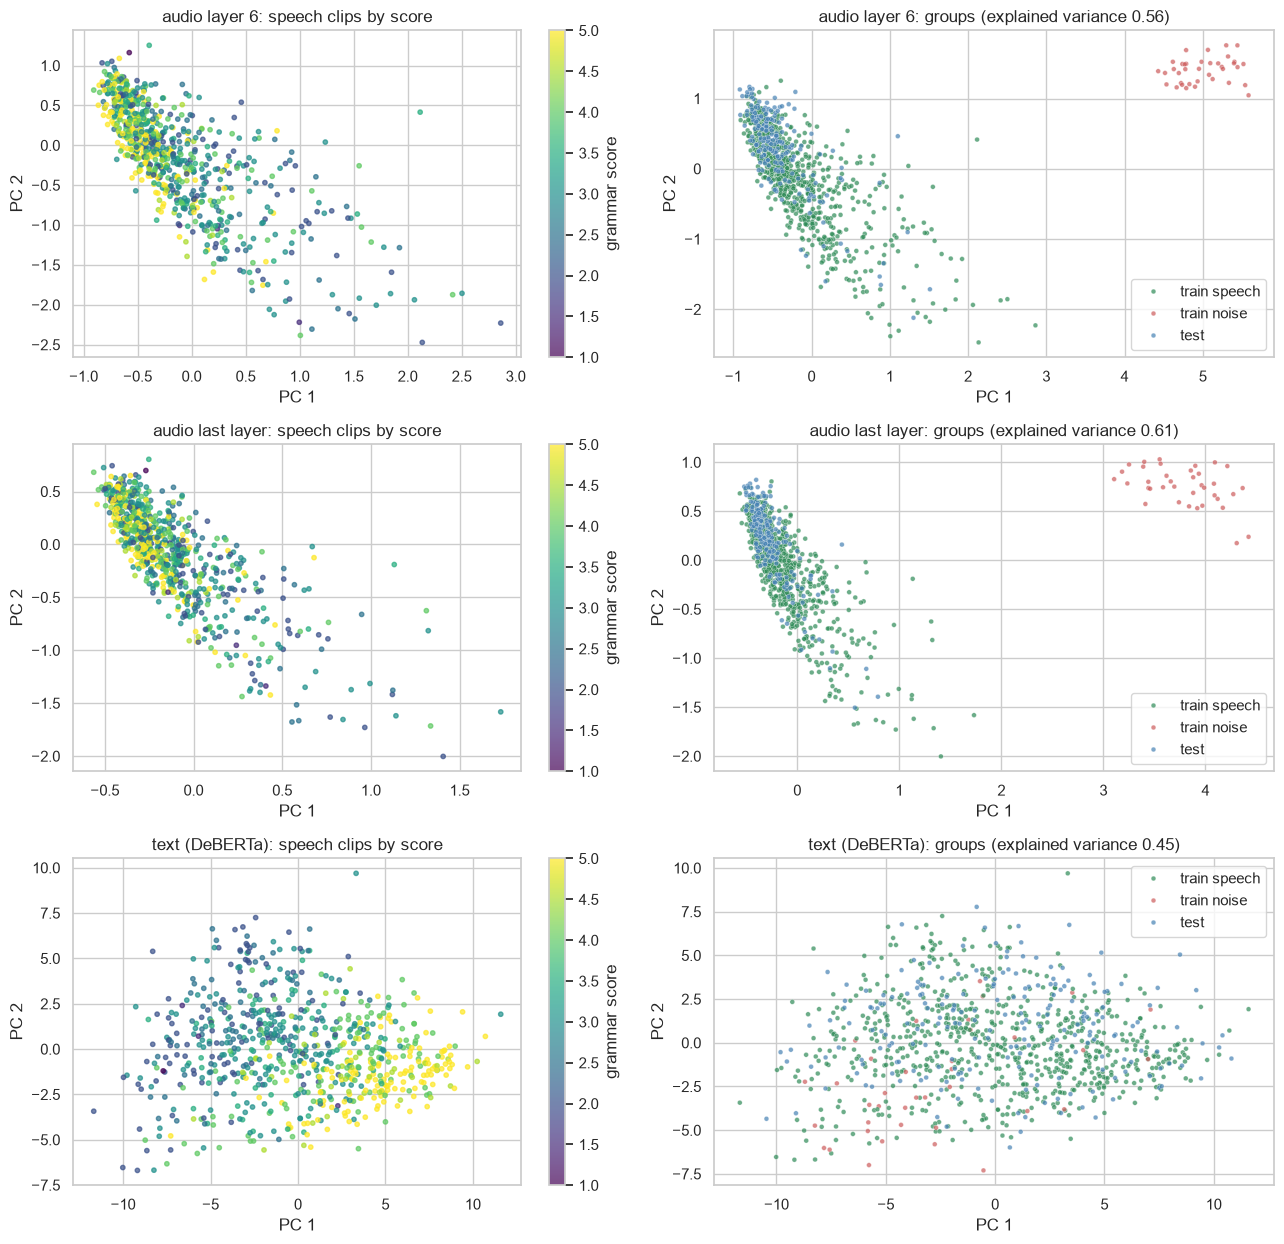

In [90]:
embedding_sets = {"audio layer 6": audio_arrays["layer6"], "audio last layer": audio_arrays["last"], "text (DeBERTa)": text_arrays["text"]}
plot_groups = pd.Series(np.select([~master_index["is_train"], master_index["is_noise"]], ["test", "train noise"], "train speech"))
speech_mask = (master_index["is_train"] & ~master_index["is_noise"]).to_numpy()

fig, axes = plt.subplots(len(embedding_sets), 2, figsize=(13, 4.2 * len(embedding_sets)), squeeze=False)
for row, (name, array) in enumerate(embedding_sets.items()):
    usable = ~np.isnan(array).any(axis=1)                                           # skip clips without an embedding
    if usable.sum() < 3:
        axes[row, 0].set_title(f"{name}: not available"); axes[row, 1].axis("off")
        continue
    pca = PCA(n_components=2, random_state=SEED)                                    # unsupervised: no labels used
    coords = np.full((len(array), 2), np.nan)
    coords[usable] = pca.fit_transform(array[usable])
    shown = usable & speech_mask
    points = axes[row, 0].scatter(coords[shown, 0], coords[shown, 1], c=master_index.loc[shown, "label"],
                                  cmap="viridis", s=10, alpha=0.7)
    fig.colorbar(points, ax=axes[row, 0], label="grammar score")
    axes[row, 0].set(title=f"{name}: speech clips by score", xlabel="PC 1", ylabel="PC 2")
    sns.scatterplot(x=coords[usable, 0], y=coords[usable, 1], hue=plot_groups[usable].to_numpy(), s=12, alpha=0.7,
                    hue_order=["train speech", "train noise", "test"], palette=["seagreen", "indianred", "steelblue"], ax=axes[row, 1])
    axes[row, 1].set(title=f"{name}: groups (explained variance {pca.explained_variance_ratio_.sum():.2f})", xlabel="PC 1", ylabel="PC 2")
plt.tight_layout()
plt.show()

#### What to look for
- **Noise versus speech (right column)**: the noise clips should form their own cluster in the audio plots, since they sound completely
  different. In the text plot they may mix with speech, because Whisper recovered normal sentences from them (Part 2).
- **Score (left column)**: a smooth colour change across the cloud (for example yellow on one side, purple on the other) would mean the
  embedding's main directions already relate to the score. No pattern is not bad news: the main directions of a frozen model often describe
  the speaker's voice or the topic, and a model in Part 4 can still find score information in the other directions.
- **Test (right column)**: test dots should lie inside the train-speech cloud. A separate test cluster would mean the test recordings differ.

# Combining and checking the features

## Step 36 - One table with all 5a and 5b features

#### Goal
Join the text and fluency features into `outputs/features/features_all.csv`, the main input of Part 4. The embeddings stay in their own
`.npy` files because they are large (1536 or 768 columns each); they share the same row order, so row 17 of every file is the same clip.

#### How
1. Check that both tables follow the master index, then put them side by side (master index columns and `has_text` only once).
2. Save, and print the shape and the missing values per column.
3. List **constant columns**: columns with a single value for every clip. They carry no information and will be dropped in Part 4
   (dropping them uses no labels, so it is not leakage).

#### Terms
- **Constant column**: a column where every row has the same value, e.g. a count that is 0 for every clip.

In [91]:
assert_same_order(text_features, "text_features")
assert_same_order(fluency_features_table, "fluency_features")
features_all = pd.concat([text_features, fluency_features_table[FLUENCY_FEATURE_COLUMNS]], axis=1)
ALL_FEATURE_COLUMNS = TEXT_FEATURE_COLUMNS + FLUENCY_FEATURE_COLUMNS
FEATURES_ALL_CSV = os.path.join(FEATURES_DIR, "features_all.csv")
features_all.to_csv(FEATURES_ALL_CSV, index=False)
assert_same_order(pd.read_csv(FEATURES_ALL_CSV), "features_all.csv on disk")       # the saved file keeps the order

print(f"Saved {FEATURES_ALL_CSV}: {features_all.shape} | {len(TEXT_FEATURE_COLUMNS)} text + "
      f"{len(FLUENCY_FEATURE_COLUMNS)} fluency = {len(ALL_FEATURE_COLUMNS)} feature columns")
missing = features_all[ALL_FEATURE_COLUMNS].isna().sum()
print("Missing values per column:", "none" if missing.sum() == 0 else missing[missing > 0].to_dict())
constant_columns = [c for c in ALL_FEATURE_COLUMNS if features_all[c].nunique(dropna=True) <= 1]
print("Constant columns (to drop in Part 4):", constant_columns or "none")

Saved .\outputs\features\features_all.csv: (985, 60) | 38 text + 16 fluency = 54 feature columns
Missing values per column: {'tense_past_share': 1, 'tense_present_share': 1}
Constant columns (to drop in Part 4): none


#### What to look for
- 985 rows and the expected number of columns; no assertion error.
- Missing values appear only where a value is undefined by design (for example a past-tense share for a transcript without finite verbs).
- A constant column means a feature that never fires; it is listed here and dropped later.

## Step 37 - How each feature relates to the grammar score (exploration)

#### Goal
See which features move together with the grammar score. **This is exploration, not model training**: nothing is fitted, and no feature
is selected here for the model (see the leakage note at the start of Part 3).

#### How
1. Use only the labelled **speech** clips (label above 0). The 37 noise clips are left out: their 0 means "no gradable speech", not "very bad grammar",
   and they would dominate every correlation.
2. For every 5a and 5b feature compute the **Spearman correlation** with the score, its p-value and the share of missing values.
3. Draw the 15 most positive and the 15 most negative correlations as a bar chart, and show the full ranked table.

#### Terms
- **Spearman correlation**: replaces values by their rank (1st, 2nd, ...) and then measures how well the two rankings agree, from -1 to +1.
  It suits our scores, which come in steps of 0.5, and it is not thrown off by a few extreme values. Example: if the clip with most grammar
  edits always has the lowest score, Spearman is -1.
- **p-value**: the chance of seeing a correlation at least this strong if there were no real relation. Small (e.g. below 0.001) = unlikely to be chance.
  With about 50 features, a few will reach p < 0.05 by chance alone, so look at the size of the correlation, not only at p.

732 speech clips, 54 features


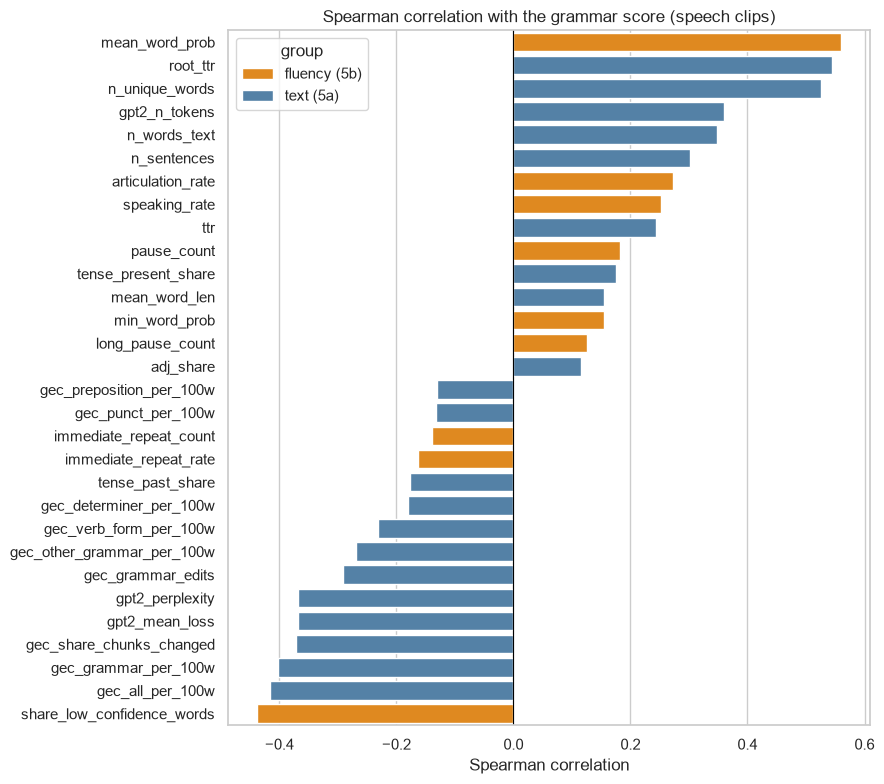

,feature,group,spearman,p_value,missing_share
0,mean_word_prob,fluency (5b),0.5600,0.0000,0.0
1,root_ttr,text (5a),0.5449,0.0000,0.0
2,n_unique_words,text (5a),0.5263,0.0000,0.0
3,gpt2_n_tokens,text (5a),0.3591,0.0000,0.0
4,n_words_text,text (5a),0.3480,0.0000,0.0
5,n_sentences,text (5a),0.3021,0.0000,0.0
6,articulation_rate,fluency (5b),0.2725,0.0000,0.0
7,speaking_rate,fluency (5b),0.2523,0.0000,0.0
8,ttr,text (5a),0.2428,0.0000,0.0
9,pause_count,fluency (5b),0.1813,0.0000,0.0


In [92]:
speech_rows = features_all[features_all["is_train"] & (features_all["label"] > 0)]       # labelled speech clips only
FEATURE_GROUP = {**dict.fromkeys(TEXT_FEATURE_COLUMNS, "text (5a)"), **dict.fromkeys(FLUENCY_FEATURE_COLUMNS, "fluency (5b)")}
correlation_rows = []
for feature in ALL_FEATURE_COLUMNS:
    values = speech_rows[feature]
    if values.nunique(dropna=True) <= 1:                                                  # constant: no correlation defined
        continue
    rho, p_value = spearmanr(values, speech_rows["label"], nan_policy="omit")             # ignore missing values
    correlation_rows.append({"feature": feature, "group": FEATURE_GROUP[feature], "spearman": rho,
                             "p_value": p_value, "missing_share": values.isna().mean()})
score_correlations = (pd.DataFrame(correlation_rows)
                      .assign(abs_spearman=lambda t: t["spearman"].abs())
                      .sort_values("spearman", ascending=False).reset_index(drop=True))
print(f"{len(speech_rows)} speech clips, {len(score_correlations)} features")

top = pd.concat([score_correlations.head(15), score_correlations.tail(15)]).drop_duplicates("feature")
top = top[top["spearman"].abs() > 0]
fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(data=top, y="feature", x="spearman", hue="group", dodge=False,
            palette={"text (5a)": "steelblue", "fluency (5b)": "darkorange"}, ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title="Spearman correlation with the grammar score (speech clips)", xlabel="Spearman correlation", ylabel="")
plt.tight_layout()
plt.show()
score_correlations.drop(columns="abs_spearman").round(4)

#### What to look for
- Correlations around 0.3 to 0.5 in absolute size are strong for single, hand-made features; below about 0.1 they are weak.
- Grammar features should be **negative** when they count errors (`gec_grammar_per_100w`) and positive when they measure complexity or variety.
- Watch for fluency features ranking above grammar features: then the raters' scores also reward fluency, and Part 4 should use both groups.
- `missing_share` above 0 tells you the feature is undefined for some clips; Part 4 must fill those gaps (inside its cross validation).

## Step 38 - Redundancy check: features that say the same thing

#### Goal
Find features that carry almost the same information, so Part 4 can keep one of each pair.

#### How
1. Take the 25 features with the largest absolute correlation with the score (from Step 37).
2. Compute the Spearman correlation between every pair of them on the speech clips, and draw it as a heatmap.
3. List the pairs with an absolute correlation above 0.9.

#### Terms
- **Heatmap**: a table drawn as coloured squares: red for strong positive, blue for strong negative, white for none.
- **Redundant features**: two features so strongly related that knowing one tells you the other. Example: `filler_count` and `filler_rate`
  for clips of similar length.

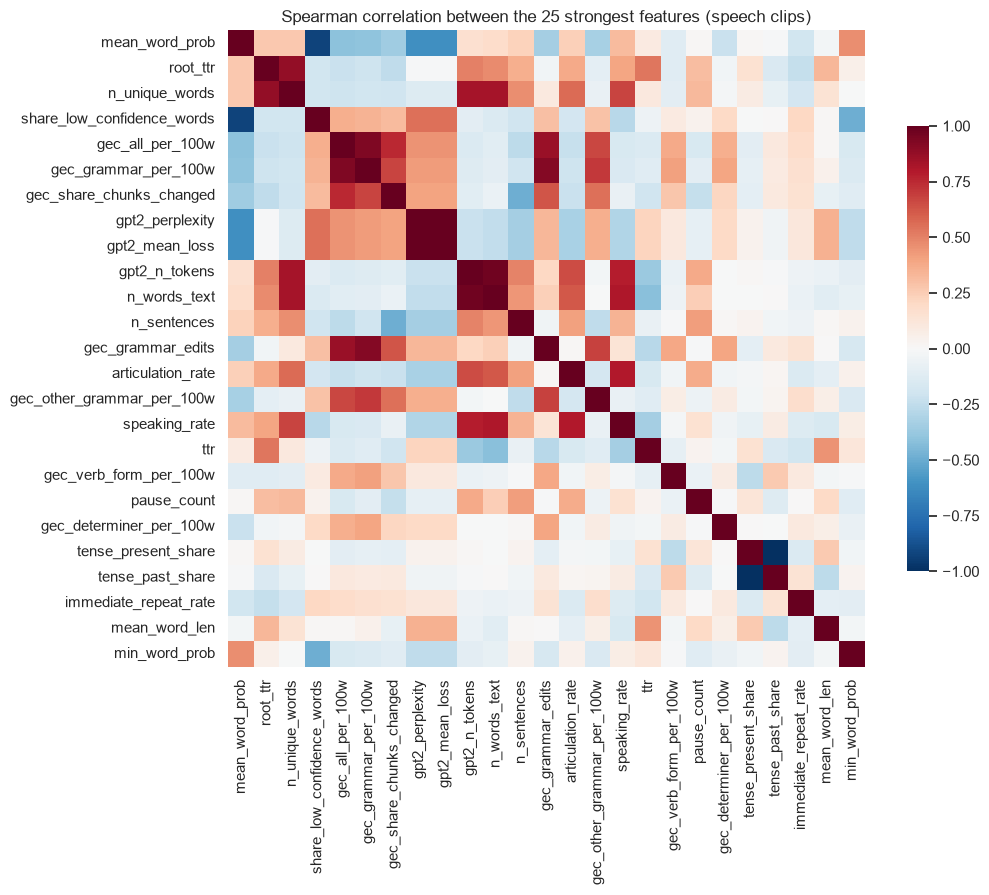

Pairs with |correlation| > 0.9: 6
           feature_a                  feature_b  spearman
 tense_present_share           tense_past_share    -1.000
     gpt2_perplexity             gpt2_mean_loss     1.000
       gpt2_n_tokens               n_words_text     0.974
    gec_all_per_100w       gec_grammar_per_100w     0.937
      mean_word_prob share_low_confidence_words    -0.923
gec_grammar_per_100w          gec_grammar_edits     0.922


In [93]:
top25 = score_correlations.sort_values("abs_spearman", ascending=False)["feature"].head(25).tolist()
pair_matrix = speech_rows[top25].corr(method="spearman")                    # feature-to-feature correlations (no labels)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(pair_matrix, cmap="RdBu_r", vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Spearman correlation between the 25 strongest features (speech clips)")
plt.tight_layout()
plt.show()

upper = pair_matrix.where(np.triu(np.ones(pair_matrix.shape, dtype=bool), k=1))  # each pair once (upper triangle)
redundant_pairs = (upper.stack().rename("spearman").reset_index()
                   .rename(columns={"level_0": "feature_a", "level_1": "feature_b"}))
redundant_pairs = redundant_pairs[redundant_pairs["spearman"].abs() > 0.9].sort_values("spearman", key=abs, ascending=False)
print(f"Pairs with |correlation| > 0.9: {len(redundant_pairs)}")
print(redundant_pairs.round(3).to_string(index=False) if len(redundant_pairs) else "none")

#### What to look for
- Dark squares away from the diagonal are pairs that move together. Expected examples: a count and its rate per 100 words,
  `gec_all_per_100w` and `gec_grammar_per_100w`, GPT-2 mean loss and perplexity (one is the log of the other, so exactly 1.0).
- A pair above 0.9 adds almost nothing over one of its members. For linear models, such pairs also make coefficients unstable.

## Step 39 - Distribution check: score levels and train versus test

#### Goal
For the 6 strongest features, see how their values change across score levels, and check that the test clips look like the training clips.

#### How
1. Group the speech clips' scores into four levels: 2 (1.0 to 2.5), 3 (3.0 and 3.5), 4 (4.0 and 4.5) and 5 (5.0). The 4 clips scored 1.0 or 1.5
   are too few for their own box and join level 2.
2. Draw one boxplot per feature across these levels.
3. Compare train speech with test for the same features: overlaid histograms, and a table with both medians and the **KS statistic**.

#### Terms
- **Boxplot**: see Step 6.2 (box = middle half of the values, line = median).
- **Distribution shift**: the test data having different typical values than the training data, which makes a trained model less accurate on test.
- **KS statistic (Kolmogorov-Smirnov)**: the largest gap between the two groups' cumulative distributions, from 0 (identical) to 1 (no overlap).
  Example: 0.05 is a negligible difference; 0.3 is a clear shift.

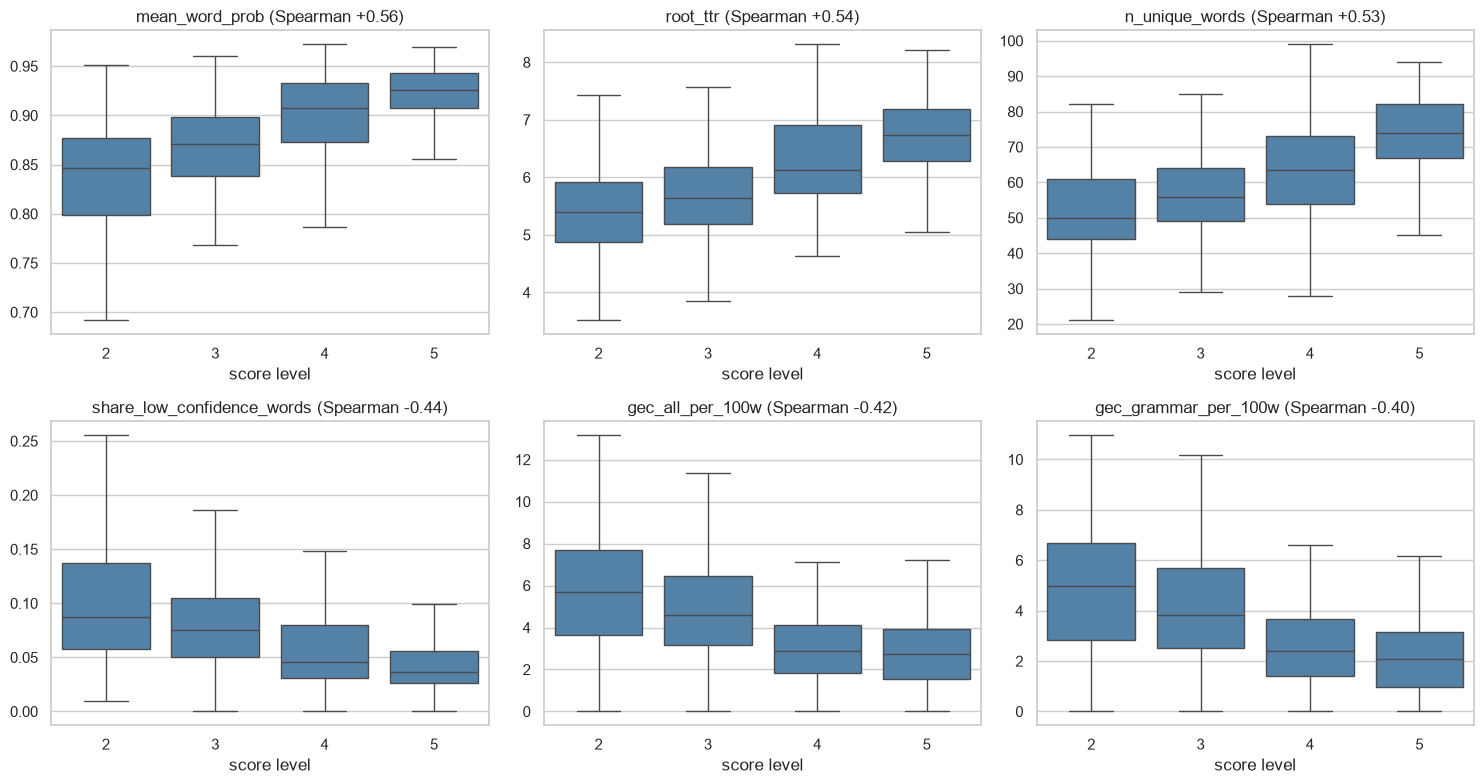

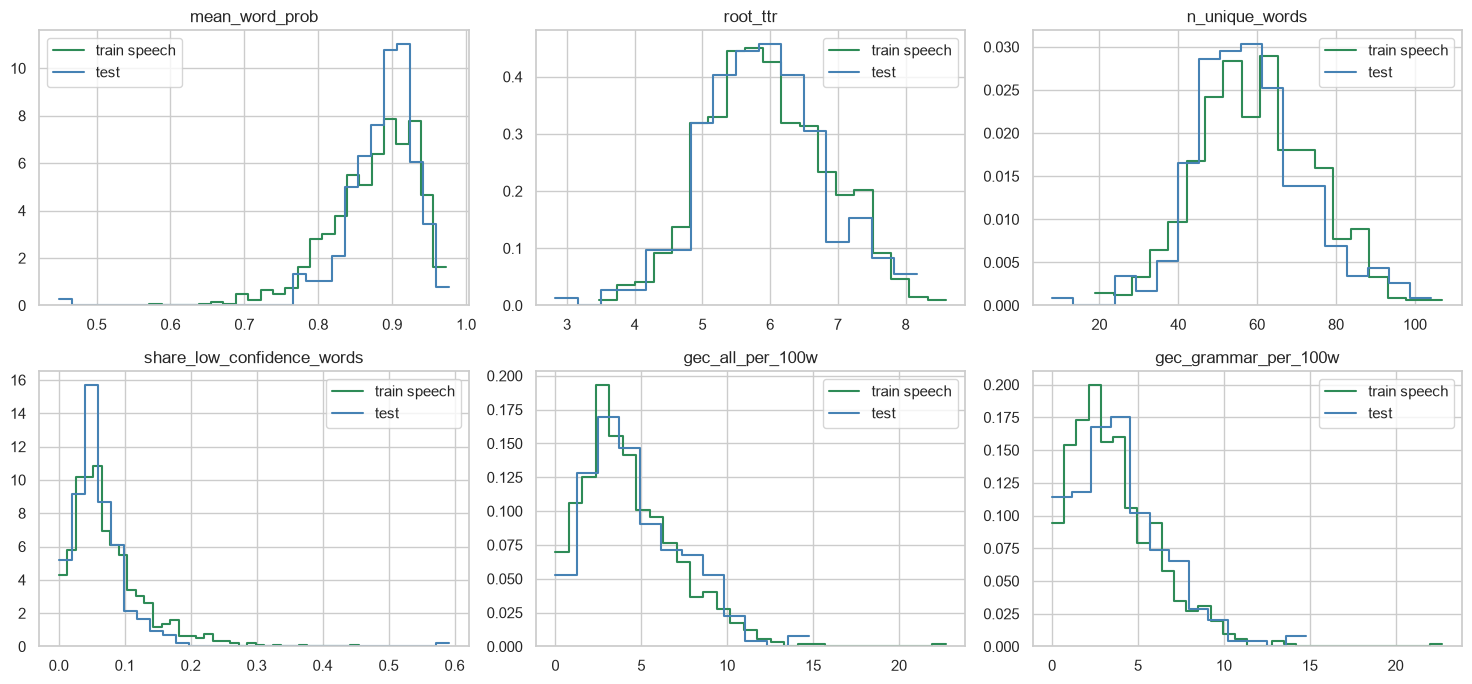

,feature,train speech median,test median,KS statistic,KS p-value
0,mean_word_prob,0.8851,0.8940,0.1535,0.0007
1,root_ttr,5.8908,5.8940,0.0634,0.4915
2,n_unique_words,60.0000,57.0000,0.0776,0.2518
3,share_low_confidence_words,0.0616,0.0535,0.1549,0.0006
4,gec_all_per_100w,3.8835,4.1494,0.0610,0.5400
5,gec_grammar_per_100w,3.1957,3.5191,0.0793,0.2305


In [94]:
top6 = score_correlations.sort_values("abs_spearman", ascending=False)["feature"].head(6).tolist()
score_level = np.clip(np.floor(speech_rows["label"]), 2, 5).astype(int)        # 1.0-2.5 -> 2, 3.0-3.5 -> 3, 4.0-4.5 -> 4, 5.0 -> 5

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feature in zip(axes.flat, top6):
    sns.boxplot(x=score_level, y=speech_rows[feature], color="steelblue", showfliers=False, ax=ax)
    rho = score_correlations.set_index("feature").at[feature, "spearman"]
    ax.set(title=f"{feature} (Spearman {rho:+.2f})", xlabel="score level", ylabel="")
plt.tight_layout()
plt.show()

test_rows = features_all[~features_all["is_train"]]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
shift_rows = []
for ax, feature in zip(axes.flat, top6):
    sns.histplot(speech_rows[feature], stat="density", element="step", fill=False, color="seagreen", label="train speech", ax=ax)
    sns.histplot(test_rows[feature], stat="density", element="step", fill=False, color="steelblue", label="test", ax=ax)
    ax.set(title=feature, xlabel="", ylabel="")
    ax.legend()
    ks = ks_2samp(speech_rows[feature].dropna(), test_rows[feature].dropna())
    shift_rows.append({"feature": feature, "train speech median": speech_rows[feature].median(),
                       "test median": test_rows[feature].median(), "KS statistic": ks.statistic, "KS p-value": ks.pvalue})
plt.tight_layout()
plt.show()
pd.DataFrame(shift_rows).round(4)

#### What to look for
- **Boxplots**: the boxes should climb (or fall) steadily from level 2 to level 5. A feature that only separates level 2 from the rest helps
  less than one with a steady trend.
- **Train versus test**: the two outlines should overlap. A KS statistic above about 0.2 is a warning sign. Remember that test clips are
  shorter on average (Part 1: 48.8 s versus 55.8 s), so counts that grow with length can shift for that reason alone; rates per 100 words should not.

## Part 3 summary

These numbers come from the local run (RTX 4060 laptop GPU, models listed in Step 21.3, `requirements_part3.txt`).

### Findings

**What was built**
- 54 hand-made features for all 985 clips in `features_all.csv` (985 rows x 60 columns with the master index columns):
  38 text features (13 grammar-edit, 18 spaCy, 4 vocabulary, 3 GPT-2) and 16 fluency features.
- Embeddings: audio layer 6 and last layer (985 x 1536 each, mean and standard deviation over time) and text (985 x 768).
- Every saved file has the master index row order; this is asserted when it is written and again when it is read back.
- No transcript is empty. The only missing values: `tense_past_share` and `tense_present_share` for one noise clip
  (train/audio_5069, 3 words, no finite verb). No constant columns.

**Run times (first run, computed from scratch)**
- Grammar correction + ERRANT about 25 minutes (873 clips in 1400 s, plus 112 clips from an earlier interrupted run),
  spaCy 42 s, GPT-2 31 s, WavLM 239 s, DeBERTa 10 s. The fluency and vocabulary features take about a second.
- The grammar correction ran 2 to 3 times slower than the pilot predicted: the laptop GPU was hot (85 C) and throttled to about 60% of its clock.
- With the caches in place, the whole of Part 3 runs in about a minute: every slow group loads its saved file.

**Grammar errors without Java**
- LanguageTool was replaced by the Gramformer method: the T5 correction model plus ERRANT. On "He go to school yesterday and buy a book."
  it finds exactly the two `R:VERB:TENSE` errors.
- Speech clips average 3.7 grammar edits per 100 words (median 3.2). Most edits are `other_grammar` (word choice, repetitions),
  then prepositions, verb forms, determiners and agreement. Punctuation, capitals and spelling add only 0.7 per 100 words.

**Relation with the score (732 speech clips, Spearman, exploration only)**
- Strongest positive: `mean_word_prob` +0.56 (Whisper's confidence), `root_ttr` +0.54, `n_unique_words` +0.53, word and token counts +0.35.
- Strongest negative: `share_low_confidence_words` -0.44, `gec_all_per_100w` -0.42, `gec_grammar_per_100w` -0.40,
  `gec_share_chunks_changed` -0.37, GPT-2 perplexity -0.37, `gec_other_grammar_per_100w` -0.27, `gec_verb_form_per_100w` -0.23.
- Weak or none: parse depth, subordinate clauses per sentence, tense variety, fillers (|rho| below 0.07).
- Redundant pairs (|rho| > 0.9): past/present tense share (-1.0 by construction), GPT-2 perplexity/mean loss (1.0), GPT-2 tokens/word count (0.97),
  all/grammar edits per 100 words (0.94), mean word probability/low-confidence share (-0.92), grammar edits per 100 words/grammar edit count (0.92).
- Train versus test: the six strongest features have similar medians. Only Whisper's confidence features shift slightly
  (KS 0.15, test clips slightly more confident); the grammar and vocabulary features show no clear shift (KS below 0.08).

**Embeddings (PCA, drawing only)**
- Audio (both layers): the first PCA direction alone separates noise from speech perfectly (AUC 1.0); 56% and 61% of the spread in 2 directions.
- Text: the first PCA direction correlates with the score at +0.65 on the speech clips, more than any single hand-made feature.
  The text embedding is likely to be a strong input for Part 4.

### Surprises worth a look
- **Whisper's confidence is the best single feature.** It most likely measures pronunciation and clarity (how easy the speech is to recognise),
  not grammar. The raters' "grammar" scores seem to include how understandable and fluent the speaker is.
- **Complexity features barely relate to the score.** Lower-scored speakers produce long run-on sentences (`mean_sentence_len` -0.12),
  so "long sentence" does not mean "complex grammar" in speech transcripts.
- **Fillers carry almost no signal.** 59% of speech clips have no filler at all after transcription, so Whisper's filler removal limits this group (Step 32).
- **Possible label noise.** The only label-1.0 clip (train/audio_108) reads fairly fluently, speaks 3.0 words per second and has a
  moderate grammar error rate (5.1 per 100 words). It is worth listening to.
- **Model downloads stalled** at about 67 MB with the Hugging Face "xet" transfer; `HF_HUB_DISABLE_XET=1` fixed it (noted in `requirements_part3.txt`).

### Next steps (Part 4: baseline models and cross validation)
1. Use the 732 speech clips with labels 1 to 5; predict 0 for clips flagged by the noise gate of Step 20.
2. Use 5-fold cross validation and keep every label-dependent step **inside** the folds: missing-value filling, scaling, feature selection, PCA.
3. Baselines: the mean predictor (RMSE 1.014), ridge regression on `features_all.csv`, ridge on each embedding set, and gradient boosting
   on the hand-made features. Report cross-validated RMSE and Pearson correlation for each.
4. Then combine the hand-made features with the text and audio embeddings, and check whether they add to each other.
5. Drop one feature of each redundant pair (or let the regularisation handle it) and compare.